# Binance Weekly Sweep Reclaim + POC Backtest

V2 notebook kopyasi uzerine eklenen V3 arastirma notebooku.

## Metodoloji

OHLCV ile market maker'i direkt gormuyoruz; kriptoda en azindan islemin agresif tarafini gorebiliyoruz. Binance `aggTrades` alaninda `isBuyerMaker=True` ise buyer maker'dir, yani agresif taraf seller/taker kabul edilir. Bundan su proxy'leri uretiyoruz:

- `taker_buy_qty`, `taker_sell_qty`: agresif alis/satis miktari.
- `imbalance`: `(taker_buy - taker_sell) / toplam`.
- `signed_notional_z`: signed flow'un rolling z-score'u.
- `vwap_gap_bps`: fiyat VWAP ustunde/altinda ne kadar ayrismis.
- `volume_ratio`: bar hacmi rolling median hacme gore ne kadar yuksek.
- `regime`: 5m close, EMA ustunde mi ve EMA egimi pozitif/negatif mi.

Signal mantigi:

- **Toxic continuation:** agresif flow fiyatla ayni yone yuksek hacimle geliyor ve 5m trend de ayni yondeyse momentum devamini dener.
- **Exhaustion fade:** agresif flow cok tek tarafli ama fiyat VWAP/Bollinger disindan iceri donuyorsa kisa sureli mean reversion dener.
- **Order book:** historical L2 yoksa mumdan derinlik uydurmuyoruz. Notebook'taki collector ile bugunden itibaren `depth@100ms`/`bookTicker` kaydedilir, sonra event-driven replay'e gecilir.


In [1]:
import os
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/codex_numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib_cache")

from pathlib import Path
from datetime import datetime, timezone, timedelta
import hashlib
import hmac
import io
import json
import socket
import ssl
import math
import time
import urllib.parse
import warnings
import zipfile

import numpy as np

try:
    import ccxt
except ImportError:
    ccxt = None
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

try:
    import requests
except ImportError as exc:
    raise ImportError("Bu notebook requests ister. Eski .venv'de var; yoksa `%pip install requests` calistir.") from exc

try:
    import vectorbt as vbt
except Exception as exc:
    raise ImportError(
        "vectorbt import edilemedi. Bu notebook eski proje .venv'i ile acilmali. "
        "Ayrica NUMBA_CACHE_DIR ilk satirda ayarlandi."
    ) from exc

print("pandas", pd.__version__)
print("vectorbt", vbt.__version__)
print("NUMBA_CACHE_DIR", os.environ.get("NUMBA_CACHE_DIR"))


pandas 2.3.3
vectorbt 1.0.0
NUMBA_CACHE_DIR /private/tmp/codex_numba_cache


In [2]:
# ==========
# Ayarlar
# ==========

# Binance REST/archive symbol format'i slashsiz, CCXT format'i slashli.
SYMBOL = "BTCUSDT"
CCXT_SYMBOL = "BTC/USDT"

# Ana yol artik senin son hucrede kullandigin CCXT.
# Secenekler: "ccxt", "rest", "archive", "auto"
SOURCE = "ccxt"

MARKET = "spot"
CCXT_EXCHANGE_ID = "binance"
CCXT_DEFAULT_TYPE = "spot"
CCXT_TIMEFRAME = "5m"
CCXT_PANDAS_FREQ = "5min"
CCXT_LIMIT = 500
CCXT_TRADE_LIMIT = 1000

# Trade varsa microstructure frame; sadece OHLCV varsa backtest frekansi CCXT_PANDAS_FREQ olur.
FEATURE_FRAME = "15s"
ENTRY_FRAME = "1min"
REGIME_FRAME = "5min"
BACKTEST_FREQ = CCXT_PANDAS_FREQ
MIN_FEATURE_ROWS_FOR_BACKTEST = 100
PREFER_TRADE_FLOW_WHEN_ENOUGH_HISTORY = True

REST_LIMIT_TRADES = 1000
REST_LIMIT_KLINES = 1000

FEE = 0.0004
SLIPPAGE = 0.0002
INIT_CASH = 100_000

ARCHIVE_DAYS = [
    (datetime.now(timezone.utc).date() - timedelta(days=2)).isoformat(),
    (datetime.now(timezone.utc).date() - timedelta(days=1)).isoformat(),
]

CACHE_DIR = Path("binance_cache")
SAVE_CACHE = False

print({
    "source": SOURCE,
    "symbol": SYMBOL,
    "ccxt_symbol": CCXT_SYMBOL,
    "ccxt_timeframe": CCXT_TIMEFRAME,
    "feature_frame": FEATURE_FRAME,
    "entry_frame": ENTRY_FRAME,
    "archive_days": ARCHIVE_DAYS,
})


{'source': 'ccxt', 'symbol': 'BTCUSDT', 'ccxt_symbol': 'BTC/USDT', 'ccxt_timeframe': '5m', 'feature_frame': '15s', 'entry_frame': '1min', 'archive_days': ['2026-07-19', '2026-07-20']}


## Veri Katmani

Bu versiyonda notebook senin ekledigin son hucredeki yolu ana kaynak yapar: `ccxt.binance().fetch_ohlcv()`.

Oncelik sirasini bilerek boyle kurdum:

1. CCXT OHLCV: `exchange.fetch_ohlcv("BTC/USDT", timeframe="5m", limit=500)`.
2. CCXT trades: calisiyorsa taker-flow feature'lari icin `exchange.fetch_trades(...)`.
3. Eski public REST: `data-api.binance.vision/api/v3`.
4. Eski public ZIP archive: `data.binance.vision/data/spot/daily/...`.

CCXT sadece OHLCV verirse notebook `DATA_MODE = "ohlcv_proxy"` yazar. Bu modda gercek taker-flow yoktur; signed volume CLV/body proxy ile uretilir. CCXT trades de gelirse `DATA_MODE = "trade_flow"` olur ve agresif alis/satis akisi kullanilir.

`SSLError: WRONG_VERSION_NUMBER` gorursen bu genelde Binance domainine TLS yerine araya HTTP redirect/middlebox cevabi gelmesi demektir. Teshis hucreleri kaldi, ama veri kaynagi artik CCXT-first.


In [3]:
SPOT_REST_BASES = [
    "https://data-api.binance.vision",
    "https://api.binance.com",
    "https://api1.binance.com",
    "https://api2.binance.com",
    "https://api3.binance.com",
    "https://api4.binance.com",
]

ARCHIVE_BASES = [
    "https://data.binance.vision",
    "https://data.binance.com",
]

BINANCE_SESSION = requests.Session()
BINANCE_SESSION.trust_env = False
BINANCE_HEADERS = {
    "User-Agent": "Mozilla/5.0 orderflow-research-notebook/1.0",
    "Accept": "application/json,text/csv,*/*",
}


def proxy_env_vars():
    keys = [
        "HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "NO_PROXY",
        "http_proxy", "https_proxy", "all_proxy", "no_proxy",
        "REQUESTS_CA_BUNDLE", "SSL_CERT_FILE",
    ]
    return {k: os.environ[k] for k in keys if os.environ.get(k)}


def clear_proxy_env():
    for k in list(proxy_env_vars()):
        os.environ.pop(k, None)
    BINANCE_SESSION.trust_env = False
    print("Proxy/cert env temizlendi. Kernel restart etmek daha temiz olur.")


def ccxt_to_binance_symbol(symbol):
    return symbol.replace("/", "").replace(":", "").upper()


def binance_to_ccxt_symbol(symbol):
    if "/" in symbol:
        return symbol
    quote_candidates = ["USDT", "FDUSD", "USDC", "BUSD", "BTC", "ETH", "TRY"]
    for quote in quote_candidates:
        if symbol.upper().endswith(quote):
            return symbol[:-len(quote)].upper() + "/" + quote
    return symbol


def make_ccxt_exchange(exchange_id=CCXT_EXCHANGE_ID, default_type=CCXT_DEFAULT_TYPE):
    if ccxt is None:
        raise ImportError("ccxt kurulu degil. Bu .venv'de olmali; yoksa `%pip install ccxt`.")
    klass = getattr(ccxt, exchange_id)
    ex = klass({
        "enableRateLimit": True,
        "timeout": 30000,
        "options": {"defaultType": default_type, "adjustForTimeDifference": True},
    })
    # requests proxy env'inden etkilenmesin.
    try:
        ex.session.trust_env = False
    except Exception:
        pass
    return ex


def load_ccxt_ticker(symbol=CCXT_SYMBOL, exchange=None):
    ex = exchange or make_ccxt_exchange()
    return ex.fetch_ticker(symbol)


def load_ccxt_ohlcv(symbol=CCXT_SYMBOL, timeframe=CCXT_TIMEFRAME, limit=CCXT_LIMIT, exchange=None):
    ex = exchange or make_ccxt_exchange()
    raw = ex.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    df = pd.DataFrame(raw, columns=["open_time", "open", "high", "low", "close", "volume"])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    freq = pd.Timedelta(CCXT_PANDAS_FREQ)
    df["close_time"] = df["open_time"] + freq
    df["quote_asset_volume"] = df["close"] * df["volume"]
    df["number_of_trades"] = np.nan
    df["taker_buy_base_volume"] = np.nan
    df["taker_buy_quote_volume"] = np.nan
    return df.set_index("open_time").sort_index()


def load_ccxt_trades(symbol=CCXT_SYMBOL, limit=CCXT_TRADE_LIMIT, exchange=None):
    ex = exchange or make_ccxt_exchange()
    raw = ex.fetch_trades(symbol, limit=limit)
    rows = []
    for item in raw:
        info = item.get("info") or {}
        ts = item.get("timestamp") or info.get("T") or info.get("time")
        price = item.get("price") or info.get("p") or info.get("price")
        amount = item.get("amount") or info.get("q") or info.get("qty")
        side = item.get("side")
        is_buyer_maker = info.get("m")
        if isinstance(is_buyer_maker, str):
            is_buyer_maker = is_buyer_maker.lower() == "true"
        if is_buyer_maker is None:
            # CCXT side genelde taker side'dir: buy => buyer taker => buyer maker False.
            if side == "buy":
                is_buyer_maker = False
            elif side == "sell":
                is_buyer_maker = True
        rows.append({
            "timestamp": pd.to_datetime(ts, unit="ms", utc=True),
            "agg_trade_id": item.get("id") or info.get("a"),
            "price": price,
            "quantity": amount,
            "is_buyer_maker": bool(is_buyer_maker) if is_buyer_maker is not None else np.nan,
            "side": side,
            "raw": info,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df = df.dropna(subset=["timestamp", "price", "quantity"])
    # is_buyer_maker bilinmiyorsa trade-flow feature guvenilir degil.
    if df["is_buyer_maker"].isna().all():
        print("CCXT trades geldi ama aggressor side/is_buyer_maker yok; OHLCV proxy kullanilacak.")
        return pd.DataFrame()
    df = df.dropna(subset=["is_buyer_maker"])
    return df.set_index("timestamp").sort_index()


def detect_plain_http_middlebox(host, port=443, timeout=4):
    try:
        with socket.create_connection((host, port), timeout=timeout) as sock:
            sock.settimeout(timeout)
            req = f"GET / HTTP/1.0\r\nHost: {host}\r\n\r\n".encode("ascii")
            sock.sendall(req)
            raw = sock.recv(700)
    except Exception as exc:
        return {
            "host": host,
            "middlebox_http": False,
            "guvenli_internet": False,
            "via_middlebox": False,
            "first_line": "",
            "location": "",
            "error": f"{type(exc).__name__}: {str(exc)[:120]}",
        }
    text = raw.decode("latin1", errors="replace")
    first_line = text.splitlines()[0] if text.splitlines() else ""
    location = ""
    for line in text.splitlines():
        if line.lower().startswith("location:"):
            location = line.split(":", 1)[1].strip()
            break
    lower = text.lower()
    return {
        "host": host,
        "middlebox_http": first_line.startswith("HTTP/"),
        "guvenli_internet": "guvenliinternet.turktelekom" in lower,
        "via_middlebox": "middlebox" in lower,
        "first_line": first_line,
        "location": location[:180],
        "error": "",
    }


def diagnose_binance_connectivity(hosts=None, show=True):
    hosts = hosts or ["api.binance.com", "data-api.binance.vision", "data.binance.vision"]
    rows = [detect_plain_http_middlebox(host) for host in hosts]
    df = pd.DataFrame(rows)
    if show:
        try:
            display(df)
        except NameError:
            print(df.to_string(index=False))
        proxy_vars = proxy_env_vars()
        if proxy_vars:
            print("Proxy/cert env var gorundu:", proxy_vars)
        blocked = df[df["guvenli_internet"] | df["via_middlebox"] | df["middlebox_http"]]
        if not blocked.empty:
            print("\nTESHIS: Binance HTTPS baglantisina TLS yerine HTTP redirect/body donuyor.")
            if blocked["guvenli_internet"].any():
                print("Guvenli Internet/Turk Telekom filtresi Binance domainlerini kesiyor gorunuyor.")
            print("CCXT ayni agda calisiyorsa bu teshisi not olarak birak; calismiyorsa ag/VPN/filtre tarafini duzelt.")
    return df


CONNECTIVITY_DIAG = diagnose_binance_connectivity()


def _connectivity_hint():
    try:
        df = CONNECTIVITY_DIAG
        if isinstance(df, pd.DataFrame) and not df.empty:
            blocked = df[df["guvenli_internet"] | df["via_middlebox"] | df["middlebox_http"]]
            if not blocked.empty:
                rows = blocked[["host", "first_line", "location"]].to_dict("records")
                return (
                    "\n\nTESHIS: Binance hostlarina TLS yerine HTTP/middlebox cevabi geliyor. "
                    f"Kanit satirlari: {rows}. "
                    "Turk Telekom Guvenli Internet/aile filtresi, kurumsal filtre veya VPN/proxy engeli olabilir."
                )
    except Exception:
        pass
    return ""


def _request_json(path, params=None, base_urls=None, timeout=20):
    base_urls = base_urls or SPOT_REST_BASES
    errors = []
    for base in base_urls:
        url = base.rstrip("/") + path
        try:
            r = BINANCE_SESSION.get(url, params=params, headers=BINANCE_HEADERS, timeout=timeout)
            text_head = r.text[:500].lower()
            if "guvenliinternet.turktelekom" in text_head:
                raise RuntimeError("Turk Telekom Guvenli Internet redirect yakalandi.")
            if r.status_code == 451:
                raise RuntimeError(f"{base} geo/restriction returned 451: {r.text[:200]}")
            r.raise_for_status()
            return r.json()
        except Exception as exc:
            errors.append(f"{base}: {type(exc).__name__}: {str(exc)[:240]}")
    raise RuntimeError("Butun Binance REST hostlari basarisiz:\n" + "\n".join(errors) + _connectivity_hint())


def _request_bytes(urls, timeout=60):
    if isinstance(urls, str):
        urls = [urls]
    errors = []
    for url in urls:
        try:
            r = BINANCE_SESSION.get(url, headers=BINANCE_HEADERS, timeout=timeout)
            text_head = r.text[:500].lower() if "text" in r.headers.get("content-type", "").lower() else ""
            if "guvenliinternet.turktelekom" in text_head:
                raise RuntimeError("Turk Telekom Guvenli Internet redirect yakalandi.")
            r.raise_for_status()
            return r.content, url
        except Exception as exc:
            errors.append(f"{url}: {type(exc).__name__}: {str(exc)[:220]}")
    raise RuntimeError("Butun archive URL'leri basarisiz:\n" + "\n".join(errors) + _connectivity_hint())


def load_spot_klines_rest(symbol=SYMBOL, interval="1m", limit=1000):
    raw = _request_json("/api/v3/klines", {"symbol": symbol, "interval": interval, "limit": limit})
    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore",
    ]
    df = pd.DataFrame(raw, columns=cols)
    numeric = [c for c in cols if c not in {"open_time", "close_time"}]
    df[numeric] = df[numeric].apply(pd.to_numeric, errors="coerce")
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    return df.set_index("open_time").sort_index()


def load_spot_aggtrades_rest(symbol=SYMBOL, limit=1000, from_id=None, start_time=None, end_time=None):
    params = {"symbol": symbol, "limit": limit}
    if from_id is not None:
        params["fromId"] = int(from_id)
    if start_time is not None:
        params["startTime"] = int(pd.Timestamp(start_time).timestamp() * 1000)
    if end_time is not None:
        params["endTime"] = int(pd.Timestamp(end_time).timestamp() * 1000)
    raw = _request_json("/api/v3/aggTrades", params)
    df = pd.DataFrame(raw)
    if df.empty:
        return df
    df = df.rename(columns={"a": "agg_trade_id", "p": "price", "q": "quantity", "f": "first_trade_id", "l": "last_trade_id", "T": "timestamp", "m": "is_buyer_maker", "M": "is_best_match"})
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    return df.set_index("timestamp").sort_index()


def _download_zip_csv(urls, timeout=60):
    content, ok_url = _request_bytes(urls, timeout=timeout)
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        names = zf.namelist()
        if not names:
            raise ValueError(f"ZIP bos: {ok_url}")
        with zf.open(names[0]) as fh:
            return pd.read_csv(fh, header=None)


def _archive_urls(path):
    return [base.rstrip("/") + path for base in ARCHIVE_BASES]


def load_klines_archive_day(symbol=SYMBOL, date=None, interval="1m"):
    date = date or (datetime.now(timezone.utc).date() - timedelta(days=1)).isoformat()
    path = f"/data/spot/daily/klines/{symbol}/{interval}/{symbol}-{interval}-{date}.zip"
    raw = _download_zip_csv(_archive_urls(path))
    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore",
    ]
    raw.columns = cols
    numeric = [c for c in cols if c not in {"open_time", "close_time"}]
    raw[numeric] = raw[numeric].apply(pd.to_numeric, errors="coerce")
    raw["open_time"] = pd.to_datetime(raw["open_time"], unit="ms", utc=True)
    raw["close_time"] = pd.to_datetime(raw["close_time"], unit="ms", utc=True)
    return raw.set_index("open_time").sort_index()


def load_aggtrades_archive_day(symbol=SYMBOL, date=None):
    date = date or (datetime.now(timezone.utc).date() - timedelta(days=1)).isoformat()
    path = f"/data/spot/daily/aggTrades/{symbol}/{symbol}-aggTrades-{date}.zip"
    raw = _download_zip_csv(_archive_urls(path))
    raw.columns = ["agg_trade_id", "price", "quantity", "first_trade_id", "last_trade_id", "timestamp", "is_buyer_maker", "is_best_match"]
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], unit="ms", utc=True)
    raw["price"] = pd.to_numeric(raw["price"], errors="coerce")
    raw["quantity"] = pd.to_numeric(raw["quantity"], errors="coerce")
    return raw.set_index("timestamp").sort_index()


def load_archive_days(loader, days, **kwargs):
    frames = []
    errors = []
    for day in days:
        try:
            frames.append(loader(date=day, **kwargs))
            print(f"ok: {loader.__name__} {day}")
        except Exception as exc:
            errors.append(f"{day}: {type(exc).__name__}: {str(exc)[:260]}")
    if frames:
        return pd.concat(frames).sort_index()
    raise RuntimeError("Archive yuklenemedi:\n" + "\n".join(errors) + _connectivity_hint())


,host,middlebox_http,guvenli_internet,via_middlebox,first_line,location,error
0,api.binance.com,False,False,False,,,TimeoutError: timed out
1,data-api.binance.vision,True,False,False,HTTP/1.1 400 Bad Request,,
2,data.binance.vision,True,True,True,HTTP/1.1 307 Temporary Redirect,https://guvenliinternet.turktelekom.com.tr/?ts...,



TESHIS: Binance HTTPS baglantisina TLS yerine HTTP redirect/body donuyor.
Guvenli Internet/Turk Telekom filtresi Binance domainlerini kesiyor gorunuyor.
CCXT ayni agda calisiyorsa bu teshisi not olarak birak; calismiyorsa ag/VPN/filtre tarafini duzelt.


In [4]:
def load_sample(symbol=SYMBOL, source=SOURCE):
    source = source.lower()
    ccxt_symbol = binance_to_ccxt_symbol(symbol) if "/" not in symbol else symbol
    binance_symbol = ccxt_to_binance_symbol(ccxt_symbol)

    if source == "ccxt":
        ex = make_ccxt_exchange()
        ticker = None
        try:
            ticker = load_ccxt_ticker(symbol=ccxt_symbol, exchange=ex)
            print("CCXT ticker ok:", {k: ticker.get(k) for k in ["bid", "ask", "last", "timestamp"]})
        except Exception as exc:
            print("CCXT ticker cekilemedi, OHLCV deneniyor:", type(exc).__name__, str(exc)[:400])
        klines = load_ccxt_ohlcv(symbol=ccxt_symbol, timeframe=CCXT_TIMEFRAME, limit=CCXT_LIMIT, exchange=ex)
        print("CCXT OHLCV ok:", klines.shape, klines.index.min(), klines.index.max())
        try:
            trades = load_ccxt_trades(symbol=ccxt_symbol, limit=CCXT_TRADE_LIMIT, exchange=ex)
            if not trades.empty:
                print("CCXT trades ok:", trades.shape, trades.index.min(), trades.index.max())
            else:
                print("CCXT trades yok/side eksik; OHLCV proxy moduna gecilecek.")
        except Exception as exc:
            print("CCXT trades cekilemedi; OHLCV proxy moduna gecilecek:", type(exc).__name__, str(exc)[:500])
            trades = pd.DataFrame()
        return trades, klines

    if source == "rest":
        trades = load_spot_aggtrades_rest(symbol=binance_symbol, limit=REST_LIMIT_TRADES)
        klines = load_spot_klines_rest(symbol=binance_symbol, interval="1m", limit=REST_LIMIT_KLINES)
        return trades, klines

    if source == "archive":
        trades = load_archive_days(load_aggtrades_archive_day, ARCHIVE_DAYS, symbol=binance_symbol)
        klines = load_archive_days(load_klines_archive_day, ARCHIVE_DAYS, symbol=binance_symbol, interval="1m")
        return trades, klines

    if source == "auto":
        for candidate in ["ccxt", "rest", "archive"]:
            try:
                print(f"source deneniyor: {candidate}")
                return load_sample(symbol=symbol, source=candidate)
            except Exception as exc:
                print(f"{candidate} basarisiz:", type(exc).__name__, str(exc)[:700])
        raise RuntimeError("ccxt/rest/archive hepsi basarisiz." + _connectivity_hint())

    raise ValueError("source ccxt/rest/archive/auto olmali")


try:
    trades_raw, klines_raw = load_sample(CCXT_SYMBOL, source=SOURCE)
    print("trades", trades_raw.shape, trades_raw.index.min() if not trades_raw.empty else None, trades_raw.index.max() if not trades_raw.empty else None)
    print("klines", klines_raw.shape, klines_raw.index.min() if not klines_raw.empty else None, klines_raw.index.max() if not klines_raw.empty else None)
    display(trades_raw.tail() if not trades_raw.empty else trades_raw)
    display(klines_raw.tail() if not klines_raw.empty else klines_raw)
except Exception as exc:
    trades_raw = pd.DataFrame()
    klines_raw = pd.DataFrame()
    print("Veri cekilemedi. SOURCE='ccxt' calisiyorsa ag/filtre duzeldikten sonra ayni hucre calisir.")
    print(type(exc).__name__)
    print(str(exc)[:1800])


CCXT ticker cekilemedi, OHLCV deneniyor: NetworkError binance GET https://dapi.binance.com/dapi/v1/exchangeInfo
CCXT OHLCV ok: (500, 10) 2026-07-19 21:55:00+00:00 2026-07-21 15:30:00+00:00
CCXT trades ok: (1000, 6) 2026-07-21 15:33:24.265000+00:00 2026-07-21 15:34:16.817000+00:00
trades (1000, 6) 2026-07-21 15:33:24.265000+00:00 2026-07-21 15:34:16.817000+00:00
klines (500, 10) 2026-07-19 21:55:00+00:00 2026-07-21 15:30:00+00:00


,agg_trade_id,price,quantity,is_buyer_maker,side,raw
timestamp,,,,,,
2026-07-21 15:34:16.257000+00:00,4019122639,66550.04,0.00162,False,buy,"{'a': 4019122639, 'p': '66550.04000000', 'q': ..."
2026-07-21 15:34:16.462000+00:00,4019122640,66550.03,0.00164,True,sell,"{'a': 4019122640, 'p': '66550.03000000', 'q': ..."
2026-07-21 15:34:16.582000+00:00,4019122641,66550.04,0.00239,False,buy,"{'a': 4019122641, 'p': '66550.04000000', 'q': ..."
2026-07-21 15:34:16.645000+00:00,4019122642,66550.04,0.00087,False,buy,"{'a': 4019122642, 'p': '66550.04000000', 'q': ..."
2026-07-21 15:34:16.817000+00:00,4019122643,66550.04,0.00010,False,buy,"{'a': 4019122643, 'p': '66550.04000000', 'q': ..."


,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume
open_time,,,,,,,,,,
2026-07-21 15:10:00+00:00,66793.99,66795.19,66679.92,66682.59,75.59468,2026-07-21 15:15:00+00:00,5.040849e+06,NaN,NaN,NaN
2026-07-21 15:15:00+00:00,66682.60,66736.55,66678.00,66736.54,74.34092,2026-07-21 15:20:00+00:00,4.961256e+06,NaN,NaN,NaN
2026-07-21 15:20:00+00:00,66736.55,66746.68,66669.39,66695.99,101.06265,2026-07-21 15:25:00+00:00,6.740473e+06,NaN,NaN,NaN
2026-07-21 15:25:00+00:00,66696.00,66696.00,66619.33,66619.33,69.31069,2026-07-21 15:30:00+00:00,4.617432e+06,NaN,NaN,NaN
2026-07-21 15:30:00+00:00,66619.33,66619.34,66541.55,66550.04,99.54734,2026-07-21 15:35:00+00:00,6.624879e+06,NaN,NaN,NaN


## Feature Uretimi

Iki mod var:

- `trade_flow`: CCXT trades veya REST `aggTrades` geldi ve yeterli tarih kapsiyor. `is_buyer_maker`/side bilgisiyle agresif alis-satis akisi kullanilir.
- `ohlcv_proxy`: 5m OHLCV ile close-location/body/volume proxy feature'lari uretilir.

Onemli duzeltme: CCXT `fetch_trades(limit=1000)` cogu zaman sadece son saniyeleri/dakikayi getirir. Bu data "gelmis" olsa bile backtest icin yeterli tarih degildir. Bu yuzden trade-flow feature satiri `MIN_FEATURE_ROWS_FOR_BACKTEST` altindaysa notebook otomatik 5m OHLCV proxy moduna duser; trade datasini sadece canli akisa dair diagnostik kabul eder.


In [5]:
def rolling_zscore(s, window, min_periods=None):
    min_periods = min_periods or max(5, window // 3)
    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


def prepare_trades(trades):
    if trades.empty:
        return trades.copy()
    df = trades.copy()
    required = {"price", "quantity", "is_buyer_maker"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"trades icinde eksik kolonlar: {missing}")
    df = df.dropna(subset=["price", "quantity", "is_buyer_maker"]).copy()
    df["taker_side"] = np.where(df["is_buyer_maker"].astype(bool), -1, 1)
    df["notional"] = df["price"] * df["quantity"]
    df["signed_qty"] = df["quantity"] * df["taker_side"]
    df["signed_notional"] = df["notional"] * df["taker_side"]
    df["taker_buy_qty"] = np.where(df["taker_side"] > 0, df["quantity"], 0.0)
    df["taker_sell_qty"] = np.where(df["taker_side"] < 0, df["quantity"], 0.0)
    df["taker_buy_notional"] = np.where(df["taker_side"] > 0, df["notional"], 0.0)
    df["taker_sell_notional"] = np.where(df["taker_side"] < 0, df["notional"], 0.0)
    return df


def build_trade_bars(trades, frame=FEATURE_FRAME):
    t = prepare_trades(trades)
    if t.empty:
        return t
    grouped = t.resample(frame)
    bars = pd.DataFrame({
        "open": grouped["price"].first(),
        "high": grouped["price"].max(),
        "low": grouped["price"].min(),
        "close": grouped["price"].last(),
        "volume": grouped["quantity"].sum(),
        "notional": grouped["notional"].sum(),
        "signed_qty": grouped["signed_qty"].sum(),
        "signed_notional": grouped["signed_notional"].sum(),
        "taker_buy_qty": grouped["taker_buy_qty"].sum(),
        "taker_sell_qty": grouped["taker_sell_qty"].sum(),
        "taker_buy_notional": grouped["taker_buy_notional"].sum(),
        "taker_sell_notional": grouped["taker_sell_notional"].sum(),
        "trade_count": grouped["price"].count(),
    })
    bars = bars.dropna(subset=["close"])
    bars["vwap"] = bars["notional"] / bars["volume"].replace(0, np.nan)
    bars["imbalance"] = (bars["taker_buy_qty"] - bars["taker_sell_qty"]) / (bars["volume"].replace(0, np.nan))
    bars["buy_share"] = bars["taker_buy_qty"] / bars["volume"].replace(0, np.nan)
    bars["log_ret"] = np.log(bars["close"]).diff()
    bars["range_bps"] = (bars["high"] - bars["low"]) / bars["close"] * 10_000
    bars["vwap_gap_bps"] = (bars["close"] / bars["vwap"] - 1) * 10_000
    bars["volume_ratio"] = bars["volume"] / bars["volume"].rolling(96, min_periods=20).median().replace(0, np.nan)
    bars["signed_notional_z"] = rolling_zscore(bars["signed_notional"], 96)
    bars["realized_vol"] = bars["log_ret"].rolling(96, min_periods=20).std(ddof=0) * math.sqrt(96)
    bars["bar_seconds"] = pd.Timedelta(frame).total_seconds()
    return bars.replace([np.inf, -np.inf], np.nan)


def _attach_regime(entry, regime_frame=REGIME_FRAME):
    regime = entry["close"].resample(regime_frame).last().dropna().to_frame("regime_close")
    regime["ema_fast"] = regime["regime_close"].ewm(span=12, adjust=False).mean()
    regime["ema_slow"] = regime["regime_close"].ewm(span=36, adjust=False).mean()
    regime["ema_slope"] = regime["ema_fast"].diff()
    regime["regime_up"] = (regime["ema_fast"] > regime["ema_slow"]) & (regime["ema_slope"] > 0)
    regime["regime_down"] = (regime["ema_fast"] < regime["ema_slow"]) & (regime["ema_slope"] < 0)
    regime = regime.reindex(entry.index, method="ffill")
    return entry.join(regime[["ema_fast", "ema_slow", "ema_slope", "regime_up", "regime_down"]])


def build_entry_frame(trade_bars, entry_frame=ENTRY_FRAME, regime_frame=REGIME_FRAME):
    if trade_bars.empty:
        return trade_bars
    g = trade_bars.resample(entry_frame)
    entry = pd.DataFrame({
        "open": g["open"].first(),
        "high": g["high"].max(),
        "low": g["low"].min(),
        "close": g["close"].last(),
        "volume": g["volume"].sum(),
        "notional": g["notional"].sum(),
        "signed_notional": g["signed_notional"].sum(),
        "taker_buy_qty": g["taker_buy_qty"].sum(),
        "taker_sell_qty": g["taker_sell_qty"].sum(),
        "trade_count": g["trade_count"].sum(),
        "vwap": g["vwap"].last(),
        "imbalance": g["imbalance"].mean(),
        "signed_notional_z": g["signed_notional_z"].last(),
        "volume_ratio": g["volume_ratio"].last(),
        "range_bps": g["range_bps"].mean(),
        "vwap_gap_bps": g["vwap_gap_bps"].last(),
    }).dropna(subset=["close"])
    entry["log_ret"] = np.log(entry["close"]).diff()
    entry["atr_bps"] = ((entry["high"] - entry["low"]).rolling(20, min_periods=5).mean() / entry["close"]) * 10_000
    entry["recent_high"] = entry["close"].rolling(20, min_periods=5).max().shift(1)
    entry["recent_low"] = entry["close"].rolling(20, min_periods=5).min().shift(1)
    return _attach_regime(entry, regime_frame=regime_frame).replace([np.inf, -np.inf], np.nan)


def _normalize_ohlcv_columns(klines):
    k = klines.copy()
    rename = {c: c.lower() for c in k.columns}
    k = k.rename(columns=rename)
    if "datetime" in k.columns and not isinstance(k.index, pd.DatetimeIndex):
        k["datetime"] = pd.to_datetime(k["datetime"], utc=True)
        k = k.set_index("datetime")
    if "timestamp" in k.columns and not isinstance(k.index, pd.DatetimeIndex):
        k["timestamp"] = pd.to_datetime(k["timestamp"], unit="ms", utc=True)
        k = k.set_index("timestamp")
    if not isinstance(k.index, pd.DatetimeIndex):
        raise ValueError("OHLCV index datetime olmali veya Timestamp/Datetime kolonu olmali.")
    required = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in k.columns]
    if missing:
        raise ValueError(f"OHLCV kolonlari eksik: {missing}")
    for col in required:
        k[col] = pd.to_numeric(k[col], errors="coerce")
    return k.sort_index().dropna(subset=required)


def build_ohlcv_proxy_features(klines, regime_frame=REGIME_FRAME):
    k = _normalize_ohlcv_columns(klines)
    if k.empty:
        return k
    f = k[["open", "high", "low", "close", "volume"]].copy()
    f["typical_price"] = (f["high"] + f["low"] + f["close"]) / 3
    f["notional"] = f["typical_price"] * f["volume"]
    rolling_notional = f["notional"].rolling(20, min_periods=5).sum()
    rolling_volume = f["volume"].rolling(20, min_periods=5).sum()
    f["vwap"] = rolling_notional / rolling_volume.replace(0, np.nan)

    price_range = (f["high"] - f["low"]).replace(0, np.nan)
    clv = ((f["close"] - f["low"]) - (f["high"] - f["close"])) / price_range
    body = (f["close"] - f["open"]) / price_range
    signed_pressure = (0.7 * clv.fillna(0) + 0.3 * body.fillna(0)).clip(-1, 1)

    f["signed_qty"] = f["volume"] * signed_pressure
    f["signed_notional"] = f["signed_qty"] * f["typical_price"]
    f["taker_buy_qty"] = ((f["volume"] + f["signed_qty"]) / 2).clip(lower=0)
    f["taker_sell_qty"] = ((f["volume"] - f["signed_qty"]) / 2).clip(lower=0)
    f["imbalance"] = f["signed_qty"] / f["volume"].replace(0, np.nan)
    f["buy_share"] = f["taker_buy_qty"] / f["volume"].replace(0, np.nan)
    f["log_ret"] = np.log(f["close"]).diff()
    f["range_bps"] = (f["high"] - f["low"]) / f["close"] * 10_000
    f["vwap_gap_bps"] = (f["close"] / f["vwap"] - 1) * 10_000
    f["volume_ratio"] = f["volume"] / f["volume"].rolling(48, min_periods=10).median().replace(0, np.nan)
    f["signed_notional_z"] = rolling_zscore(f["signed_notional"], 48)
    f["atr_bps"] = ((f["high"] - f["low"]).rolling(20, min_periods=5).mean() / f["close"]) * 10_000
    f["recent_high"] = f["close"].rolling(20, min_periods=5).max().shift(1)
    f["recent_low"] = f["close"].rolling(20, min_periods=5).min().shift(1)
    f["trade_count"] = np.nan
    return _attach_regime(f, regime_frame=regime_frame).replace([np.inf, -np.inf], np.nan)


trade_bars = build_trade_bars(trades_raw, FEATURE_FRAME) if not trades_raw.empty else pd.DataFrame()
trade_features = build_entry_frame(trade_bars, ENTRY_FRAME, REGIME_FRAME) if not trade_bars.empty else pd.DataFrame()
ohlcv_features = build_ohlcv_proxy_features(klines_raw, REGIME_FRAME) if not klines_raw.empty else pd.DataFrame()

trade_flow_rows = len(trade_features)
ohlcv_rows = len(ohlcv_features)
trade_flow_coverage_ok = trade_flow_rows >= MIN_FEATURE_ROWS_FOR_BACKTEST

if (
    PREFER_TRADE_FLOW_WHEN_ENOUGH_HISTORY
    and trade_flow_coverage_ok
):
    DATA_MODE = "trade_flow"
    features = trade_features
    BACKTEST_FREQ = ENTRY_FRAME
elif not ohlcv_features.empty:
    DATA_MODE = "ohlcv_proxy"
    features = ohlcv_features
    BACKTEST_FREQ = CCXT_PANDAS_FREQ
    if trade_flow_rows:
        print(
            f"Trade-flow geldi ama backtest icin kisa: {trade_flow_rows} satir. "
            f"OHLCV proxy kullaniliyor: {ohlcv_rows} satir."
        )
elif not trade_features.empty:
    DATA_MODE = "trade_flow_short_sample"
    features = trade_features
    BACKTEST_FREQ = ENTRY_FRAME
    print(
        f"UYARI: Sadece {trade_flow_rows} trade-flow feature satiri var. "
        "Bu backtest icin yeterli degil; daha uzun aggTrades/archive/live collector gerekli."
    )
else:
    DATA_MODE = "no_data"
    features = pd.DataFrame()

print("DATA_MODE", DATA_MODE)
print("BACKTEST_FREQ", BACKTEST_FREQ)
print("trade_bars", trade_bars.shape)
print("trade_features", trade_features.shape)
print("ohlcv_features", ohlcv_features.shape)
print("features", features.shape)
display(features.tail(10) if not features.empty else features)


Trade-flow geldi ama backtest icin kisa: 2 satir. OHLCV proxy kullaniliyor: 500 satir.
DATA_MODE ohlcv_proxy
BACKTEST_FREQ 5min
trade_bars (5, 23)
trade_features (2, 25)
ohlcv_features (500, 28)
features (500, 28)


,open,high,low,close,volume,typical_price,notional,vwap,signed_qty,signed_notional,taker_buy_qty,taker_sell_qty,imbalance,buy_share,log_ret,range_bps,vwap_gap_bps,volume_ratio,signed_notional_z,atr_bps,recent_high,recent_low,trade_count,ema_fast,ema_slow,ema_slope,regime_up,regime_down
open_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-21 14:45:00+00:00,66849.77,66928.49,66823.36,66841.63,114.55888,66864.493333,7.659921e+06,66710.701692,-54.980199,-3.676223e+06,29.789341,84.769539,-0.479930,0.260035,-0.000122,15.728222,19.626283,1.340533,-0.822231,20.215994,66944.4,66367.99,NaN,66774.015502,66617.072139,12.293545,True,False
2026-07-21 14:50:00+00:00,66841.63,66869.79,66809.98,66839.99,76.87024,66839.920000,5.138001e+06,66716.751936,-0.443408,-2.963736e+04,38.213416,38.656824,-0.005768,0.497116,-0.000025,8.948236,18.471832,0.939962,-0.238406,20.115129,66944.4,66367.99,NaN,66784.165424,66629.121753,10.149923,True,False
2026-07-21 14:55:00+00:00,66840.00,66907.34,66835.95,66842.30,68.13711,66861.863333,4.555774e+06,66723.447209,-38.552490,-2.577691e+06,14.792310,53.344800,-0.565808,0.217096,0.000035,10.680363,17.812747,0.833174,-0.738391,19.875438,66944.4,66367.99,NaN,66793.109205,66640.644902,8.943781,True,False
2026-07-21 15:00:00+00:00,66842.29,66842.30,66653.05,66670.09,108.60188,66721.813333,7.246114e+06,66729.599360,-91.976754,-6.136856e+06,8.312563,100.289317,-0.846917,0.076542,-0.002580,28.386042,-8.917985,1.270826,-1.386511,20.420776,66944.4,66367.99,NaN,66774.183174,66642.236529,-18.926032,False,False
2026-07-21 15:05:00+00:00,66670.08,66794.00,66662.55,66794.00,96.25874,66750.183333,6.425289e+06,66737.928257,94.604510,6.314868e+06,95.431625,0.827115,0.982815,0.991407,0.001857,19.679911,8.401781,1.061484,0.972841,20.907641,66944.4,66367.99,NaN,66777.231916,66650.439960,3.048742,True,False
2026-07-21 15:10:00+00:00,66793.99,66795.19,66679.92,66682.59,75.59468,66719.233333,5.043619e+06,66749.117830,-72.381890,-4.829264e+06,1.606395,73.988285,-0.957500,0.021250,-0.001669,17.286371,-9.966848,0.884586,-1.113966,20.770864,66944.4,66367.99,NaN,66762.671621,66652.177800,-14.560295,False,False
2026-07-21 15:15:00+00:00,66682.60,66736.55,66678.00,66736.54,74.34092,66717.030000,4.959805e+06,66763.189383,72.567149,4.841465e+06,73.454035,0.886885,0.976140,0.988070,0.000809,8.773305,-3.991628,0.909034,0.699069,20.068916,66944.4,66367.99,NaN,66758.651372,66656.737919,-4.020249,False,False
2026-07-21 15:20:00+00:00,66736.55,66746.68,66669.39,66695.99,101.06265,66704.020000,6.741285e+06,66779.082904,-37.960277,-2.532103e+06,31.551187,69.511463,-0.375611,0.312194,-0.000608,11.588403,-12.442954,1.182604,-0.683506,19.893025,66944.4,66367.99,NaN,66749.011161,66658.859653,-9.640211,False,False
2026-07-21 15:25:00+00:00,66696.00,66696.00,66619.33,66619.33,69.31069,66644.886667,4.619203e+06,66791.108168,-69.310690,-4.619203e+06,0.000000,69.310690,-1.000000,0.000000,-0.001150,11.508672,-25.718718,0.811052,-1.038214,18.070356,66944.4,66653.99,NaN,66729.060213,66656.722915,-19.950948,False,False


## Sinyaller

Sinyal isimleri ayni kaliyor ama veri moduna gore anlamlari degisir:

- `trade_flow`: imbalance gercek agresif alis/satis akisi.
- `ohlcv_proxy`: imbalance 5m mumun close-location/body/volume proxy'si.

Bu yuzden `ohlcv_proxy` modunda sonuc daha temkinli okunmali. 5m OHLCV ile market maker'i takip etmiyoruz; sadece fiyat-hacim izlerinden trade edilebilir bir ritim ariyoruz.


In [6]:
SIGNAL_PARAM_KEYS = {
    "imb_thr", "z_thr", "vol_ratio_thr", "break_lookback",
    "hold_bars", "fade_z_thr", "fade_vwap_bps",
}


def signal_only_params(params):
    params = params or {}
    return {k: params[k] for k in SIGNAL_PARAM_KEYS if k in params}


def make_time_exit(entries, hold_bars):
    return entries.shift(int(hold_bars)).fillna(False).astype(bool)


def build_signals(
    f,
    imb_thr=0.18,
    z_thr=1.0,
    vol_ratio_thr=1.15,
    break_lookback=20,
    hold_bars=8,
    fade_z_thr=2.0,
    fade_vwap_bps=4.0,
):
    if f.empty:
        idx = f.index
        empty = pd.Series(False, index=idx)
        return empty, empty, empty, empty

    recent_high = f["close"].rolling(break_lookback, min_periods=max(3, break_lookback // 3)).max().shift(1)
    recent_low = f["close"].rolling(break_lookback, min_periods=max(3, break_lookback // 3)).min().shift(1)

    long_cont = (
        f["regime_up"].fillna(False)
        & (f["imbalance"] > imb_thr)
        & (f["signed_notional_z"] > z_thr)
        & (f["volume_ratio"] > vol_ratio_thr)
        & (f["close"] > recent_high)
        & (f["vwap_gap_bps"] > 0)
    )

    short_cont = (
        f["regime_down"].fillna(False)
        & (f["imbalance"] < -imb_thr)
        & (f["signed_notional_z"] < -z_thr)
        & (f["volume_ratio"] > vol_ratio_thr)
        & (f["close"] < recent_low)
        & (f["vwap_gap_bps"] < 0)
    )

    # Exhaustion: agresif flow cok tek tarafli, ama fiyat VWAP tarafina geri sarkiyor.
    long_fade = (
        (f["signed_notional_z"] < -fade_z_thr)
        & (f["imbalance"] < -imb_thr)
        & (f["vwap_gap_bps"] > -fade_vwap_bps)
        & (f["close"] > f["low"].rolling(5, min_periods=2).min().shift(1))
    )
    short_fade = (
        (f["signed_notional_z"] > fade_z_thr)
        & (f["imbalance"] > imb_thr)
        & (f["vwap_gap_bps"] < fade_vwap_bps)
        & (f["close"] < f["high"].rolling(5, min_periods=2).max().shift(1))
    )

    entries = (long_cont | long_fade).fillna(False)
    short_entries = (short_cont | short_fade).fillna(False)
    exits = make_time_exit(entries, hold_bars) | short_entries
    short_exits = make_time_exit(short_entries, hold_bars) | entries
    return entries.astype(bool), exits.astype(bool), short_entries.astype(bool), short_exits.astype(bool)


def trade_metrics(pf):
    trades = pf.trades.records_readable
    total_return = float(pf.total_return())
    max_dd = float(pf.max_drawdown())
    if trades.empty:
        return {
            "trades": 0,
            "win_rate": np.nan,
            "total_return": total_return,
            "max_drawdown": max_dd,
            "profit_factor": np.nan,
            "expectancy": np.nan,
            "avg_win": np.nan,
            "avg_loss": np.nan,
            "payoff": np.nan,
        }
    pnl_col = "PnL" if "PnL" in trades.columns else "Return"
    pnl = pd.to_numeric(trades[pnl_col], errors="coerce").dropna()
    wins = pnl[pnl > 0]
    losses = pnl[pnl < 0]
    gross_win = wins.sum()
    gross_loss = losses.abs().sum()
    profit_factor = gross_win / gross_loss if gross_loss > 0 else np.inf
    avg_win = wins.mean() if len(wins) else 0.0
    avg_loss = losses.mean() if len(losses) else 0.0
    payoff = abs(avg_win / avg_loss) if avg_loss < 0 else np.inf
    return {
        "trades": int(len(pnl)),
        "win_rate": float((pnl > 0).mean()),
        "total_return": total_return,
        "max_drawdown": max_dd,
        "profit_factor": float(profit_factor),
        "expectancy": float(pnl.mean()),
        "avg_win": float(avg_win),
        "avg_loss": float(avg_loss),
        "payoff": float(payoff),
    }


def run_vectorbt(f, params=None, direction="both"):
    params = params or {}
    entries, exits, short_entries, short_exits = build_signals(f, **signal_only_params(params))
    close = f["close"].astype(float)
    sl_stop = params.get("sl_stop", 0.004)
    tp_stop = params.get("tp_stop", 0.002)
    if direction == "long_only":
        short_entries = pd.Series(False, index=f.index)
        short_exits = pd.Series(False, index=f.index)
    elif direction == "short_only":
        entries = pd.Series(False, index=f.index)
        exits = pd.Series(False, index=f.index)

    pf = vbt.Portfolio.from_signals(
        close,
        entries=entries,
        exits=exits,
        short_entries=short_entries,
        short_exits=short_exits,
        init_cash=INIT_CASH,
        fees=FEE,
        slippage=SLIPPAGE,
        sl_stop=sl_stop,
        tp_stop=tp_stop,
        freq=BACKTEST_FREQ,
    )
    metrics = trade_metrics(pf)
    metrics.update({"entries": int(entries.sum()), "short_entries": int(short_entries.sum()), "data_mode": DATA_MODE, "freq": BACKTEST_FREQ})
    return pf, metrics


base_params = {
    "imb_thr": 0.18,
    "z_thr": 1.0,
    "vol_ratio_thr": 1.15,
    "break_lookback": 20,
    "hold_bars": 8,
    "fade_z_thr": 2.0,
    "fade_vwap_bps": 4.0,
    "sl_stop": 0.004,
    "tp_stop": 0.002,
}

if not features.empty:
    pf_base, metrics_base = run_vectorbt(features.dropna(subset=["close"]), base_params)
    display(pd.Series(metrics_base).to_frame("base"))
    display(pf_base.trades.records_readable.tail())
else:
    print("Feature yok; once veri hucrelerini calistir.")


,base
trades,20
win_rate,0.45
total_return,-0.020364
max_drawdown,-0.020364
profit_factor,0.464054
expectancy,-101.822205
avg_win,195.91969
avg_loss,-345.429211
payoff,0.567178
entries,35


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
15,15,0,1.489052,2026-07-21 06:40:00+00:00,65976.192600,39.296804,2026-07-21 07:45:00+00:00,66194.920000,39.427082,246.972679,0.002514,Long,Closed,15
16,16,0,1.483089,2026-07-21 10:20:00+00:00,66407.958936,39.395553,2026-07-21 11:00:00+00:00,66167.843784,39.253109,-434.760694,-0.004414,Long,Closed,16
17,17,0,1.475238,2026-07-21 12:15:00+00:00,66466.770696,39.221719,2026-07-21 12:35:00+00:00,66630.340000,39.318240,162.763671,0.001660,Long,Closed,17
18,18,0,1.473240,2026-07-21 13:45:00+00:00,66667.320798,39.286798,2026-07-21 14:00:00+00:00,66859.190000,39.399866,203.982810,0.002077,Long,Closed,18
19,19,0,1.469895,2026-07-21 14:10:00+00:00,66957.788880,39.368359,2026-07-21 14:20:00+00:00,66673.320000,39.201103,-496.708749,-0.005047,Long,Closed,19


## Train/Test Grid

Burada amac "win rate'i 80 yapalim" diye buyuk stop/kucuk take-profit hilesine dusmemek. O yuzden siralama:

1. Test trade sayisi makul mu?
2. Test expectancy pozitif mi?
3. Profit factor 1 ustu mu?
4. Drawdown kabul edilebilir mi?
5. Win rate yuksekse, avg loss avg win'i ezmiyor mu?

Yani 80% win rate ancak profit factor ve expectancy bozulmuyorsa degerli.


In [7]:
from itertools import product


def split_train_test(f, train_frac=0.7):
    n = len(f)
    cut = max(1, int(n * train_frac))
    return f.iloc[:cut].copy(), f.iloc[cut:].copy()


def evaluate_grid(f, min_test_trades=5, direction="both"):
    f = f.dropna(subset=["close"]).copy()
    if len(f) < 200:
        print("Grid icin veri az; archive gunlerini artirmak daha mantikli.")
    train, test = split_train_test(f)

    grid = []
    for imb_thr, z_thr, vol_thr, hold_bars, sl_stop, tp_stop in product(
        [0.12, 0.18, 0.25, 0.35],
        [0.5, 1.0, 1.5, 2.0],
        [1.0, 1.15, 1.35],
        [4, 8, 15, 30],
        [0.0025, 0.004, 0.0075],
        [0.0015, 0.0025, 0.004],
    ):
        params = {
            "imb_thr": imb_thr,
            "z_thr": z_thr,
            "vol_ratio_thr": vol_thr,
            "break_lookback": 20,
            "hold_bars": hold_bars,
            "fade_z_thr": max(1.5, z_thr + 0.75),
            "fade_vwap_bps": 4.0,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
        }
        try:
            _, m_train = run_vectorbt(train, params, direction=direction)
            _, m_test = run_vectorbt(test, params, direction=direction)
        except Exception as exc:
            continue
        row = {**params}
        row.update({f"train_{k}": v for k, v in m_train.items()})
        row.update({f"test_{k}": v for k, v in m_test.items()})
        grid.append(row)

    res = pd.DataFrame(grid)
    if res.empty:
        return res
    res["test_win_rate_pct"] = res["test_win_rate"] * 100
    res["train_win_rate_pct"] = res["train_win_rate"] * 100
    res["score"] = (
        res["test_expectancy"].fillna(-np.inf).rank(pct=True)
        + res["test_profit_factor"].replace(np.inf, 10).fillna(0).rank(pct=True)
        + res["test_total_return"].fillna(-np.inf).rank(pct=True)
        - res["test_max_drawdown"].fillna(1).rank(pct=True)
    )
    res["high_wr_but_bad_expectancy"] = (res["test_win_rate"] >= 0.80) & (res["test_expectancy"] <= 0)
    res = res.sort_values(["score", "test_expectancy", "test_profit_factor"], ascending=False)
    if min_test_trades:
        res = res[res["test_trades"] >= min_test_trades]
    return res


if not features.empty:
    grid_results = evaluate_grid(features, min_test_trades=3, direction="both")
    display(grid_results.head(20))
    if not grid_results.empty:
        best_params = grid_results.iloc[0][list(base_params.keys())].to_dict()
        best_params["hold_bars"] = int(best_params["hold_bars"])
        best_params["break_lookback"] = int(best_params["break_lookback"])
        pf_best, best_metrics = run_vectorbt(features.dropna(subset=["close"]), best_params)
        print("best_params", best_params)
        display(pd.Series(best_metrics).to_frame("full_sample_best"))
        display(grid_results[grid_results["test_win_rate"] >= 0.80].head(10))
    else:
        print("Grid bos veya trade sayisi yetersiz. Daha uzun archive sample kullan.")
else:
    grid_results = pd.DataFrame()
    print("Feature yok; once veri hucrelerini calistir.")


,imb_thr,z_thr,vol_ratio_thr,break_lookback,hold_bars,fade_z_thr,fade_vwap_bps,sl_stop,tp_stop,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,score,high_wr_but_bad_expectancy
1435,0.35,1.0,1.00,20,30,1.75,4.0,0.0040,0.0025,14,0.571429,-0.006652,-0.013195,0.732996,-47.515827,228.276398,-415.238793,0.549747,13,11,ohlcv_proxy,5min,9,0.555556,0.005778,-0.007464,2.024484,64.195523,228.342281,-140.987923,1.619588,22,1,ohlcv_proxy,5min,55.555556,57.142857,2.515046,False
1438,0.35,1.0,1.00,20,30,1.75,4.0,0.0075,0.0025,14,0.571429,-0.003744,-0.015111,0.830006,-26.744125,228.513973,-367.088255,0.622504,13,11,ohlcv_proxy,5min,9,0.555556,0.005778,-0.007464,2.024484,64.195523,228.342281,-140.987923,1.619588,22,1,ohlcv_proxy,5min,55.555556,57.142857,2.515046,False
1471,0.35,1.0,1.15,20,30,1.75,4.0,0.0040,0.0025,14,0.571429,-0.006652,-0.013195,0.732996,-47.515827,228.276398,-415.238793,0.549747,13,11,ohlcv_proxy,5min,9,0.555556,0.005778,-0.007464,2.024484,64.195523,228.342281,-140.987923,1.619588,22,1,ohlcv_proxy,5min,55.555556,57.142857,2.515046,False
1474,0.35,1.0,1.15,20,30,1.75,4.0,0.0075,0.0025,14,0.571429,-0.003744,-0.015111,0.830006,-26.744125,228.513973,-367.088255,0.622504,13,11,ohlcv_proxy,5min,9,0.555556,0.005778,-0.007464,2.024484,64.195523,228.342281,-140.987923,1.619588,22,1,ohlcv_proxy,5min,55.555556,57.142857,2.515046,False
59,0.12,0.5,1.15,20,15,1.50,4.0,0.0040,0.0040,16,0.437500,-0.007133,-0.014834,0.798714,-44.582882,404.359110,-393.759986,1.026918,21,17,ohlcv_proxy,5min,8,0.500000,0.005355,-0.006233,1.861924,66.937321,289.195295,-155.320652,1.861924,30,1,ohlcv_proxy,5min,50.000000,43.750000,2.325231,False
62,0.12,0.5,1.15,20,15,1.50,4.0,0.0075,0.0040,17,0.411765,-0.011663,-0.020505,0.708184,-68.604714,404.334725,-399.662321,1.011691,21,17,ohlcv_proxy,5min,8,0.500000,0.005355,-0.006233,1.861924,66.937321,289.195295,-155.320652,1.861924,30,1,ohlcv_proxy,5min,50.000000,41.176471,2.325231,False
491,0.18,0.5,1.15,20,15,1.50,4.0,0.0040,0.0040,16,0.437500,-0.007133,-0.014834,0.798714,-44.582882,404.359110,-393.759986,1.026918,21,17,ohlcv_proxy,5min,8,0.500000,0.005355,-0.006233,1.861924,66.937321,289.195295,-155.320652,1.861924,30,1,ohlcv_proxy,5min,50.000000,43.750000,2.325231,False
494,0.18,0.5,1.15,20,15,1.50,4.0,0.0075,0.0040,17,0.411765,-0.011663,-0.020505,0.708184,-68.604714,404.334725,-399.662321,1.011691,21,17,ohlcv_proxy,5min,8,0.500000,0.005355,-0.006233,1.861924,66.937321,289.195295,-155.320652,1.861924,30,1,ohlcv_proxy,5min,50.000000,41.176471,2.325231,False
923,0.25,0.5,1.15,20,15,1.50,4.0,0.0040,0.0040,16,0.437500,-0.007133,-0.014834,0.798714,-44.582882,404.359110,-393.759986,1.026918,21,16,ohlcv_proxy,5min,8,0.500000,0.005355,-0.006233,1.861924,66.937321,289.195295,-155.320652,1.861924,30,1,ohlcv_proxy,5min,50.000000,43.750000,2.325231,False
926,0.25,0.5,1.15,20,15,1.50,4.0,0.0075,0.0040,17,0.411765,-0.011663,-0.020505,0.708184,-68.604714,404.334725,-399.662321,1.011691,21,16,ohlcv_proxy,5min,8,0.500000,0.005355,-0.006233,1.861924,66.937321,289.195295,-155.320652,1.861924,30,1,ohlcv_proxy,5min,50.000000,41.176471,2.325231,False


best_params {'imb_thr': 0.35, 'z_thr': 1.0, 'vol_ratio_thr': 1.0, 'break_lookback': 20, 'hold_bars': 30, 'fade_z_thr': 1.75, 'fade_vwap_bps': 4.0, 'sl_stop': 0.004, 'tp_stop': 0.0025}


,full_sample_best
trades,23
win_rate,0.521739
total_return,-0.003373
max_drawdown,-0.013195
profit_factor,0.892547
expectancy,-14.665553
avg_win,233.484302
avg_loss,-285.374486
payoff,0.818168
entries,36


,imb_thr,z_thr,vol_ratio_thr,break_lookback,hold_bars,fade_z_thr,fade_vwap_bps,sl_stop,tp_stop,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,score,high_wr_but_bad_expectancy


## Diagnostik Plotlar

Bu bolum backtest sonucunu gorsel olarak kontrol eder:

- Fiyat ustunde long/short entry marker'lari.
- Equity curve ve drawdown.
- Imbalance, signed flow z-score, volume ratio ve VWAP gap.
- Trade PnL histogrami.
- Grid calistiysa win-rate / expectancy scatter ve parametre heatmap'i.

Plotlar guzel ciksa bile alpha kaniti degil; asil filtre test expectancy, profit factor, drawdown ve out-of-sample davranistir.


,close,imbalance,signed_notional_z,volume_ratio,vwap_gap_bps,atr_bps
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,65809.423400,0.047398,0.038235,1.355398,6.073643,12.270017
std,540.594437,0.647395,1.070073,0.908596,20.546861,2.926844
min,65078.000000,-1.000000,-4.063371,0.259503,-59.411348,7.200913
25%,65326.002500,-0.516821,-0.642179,0.738056,-4.788813,9.895045
50%,65599.490000,0.102874,-0.018465,1.081952,8.359048,11.925311
75%,66296.497500,0.667829,0.658226,1.725959,20.953832,14.038571
max,66944.400000,1.000000,3.552024,5.535482,43.457815,20.907641


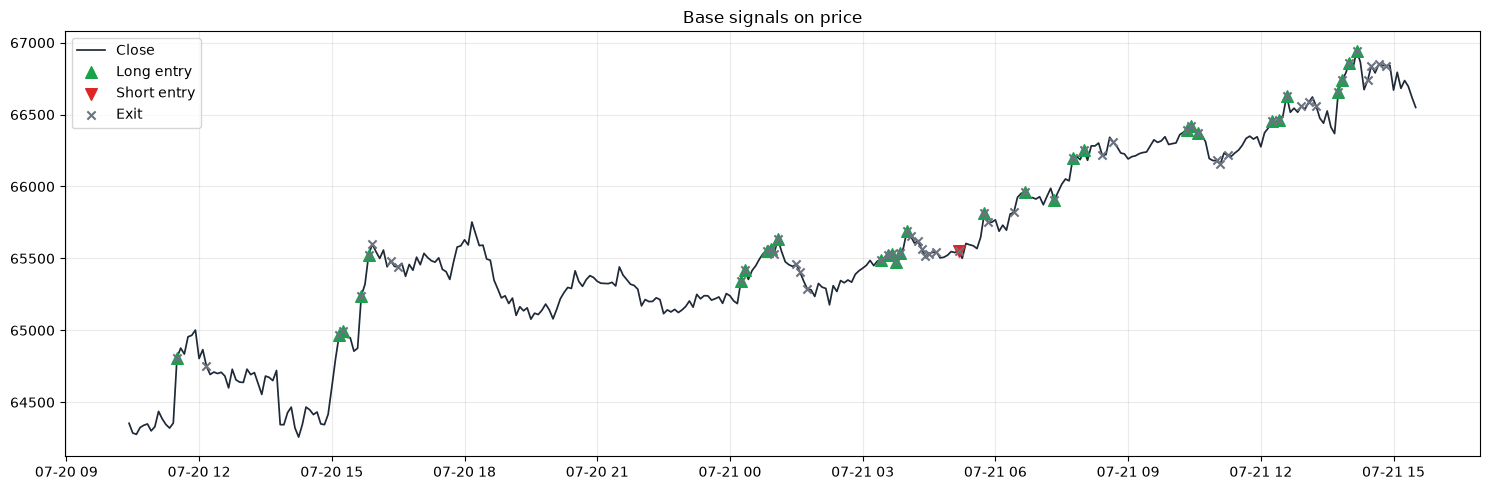

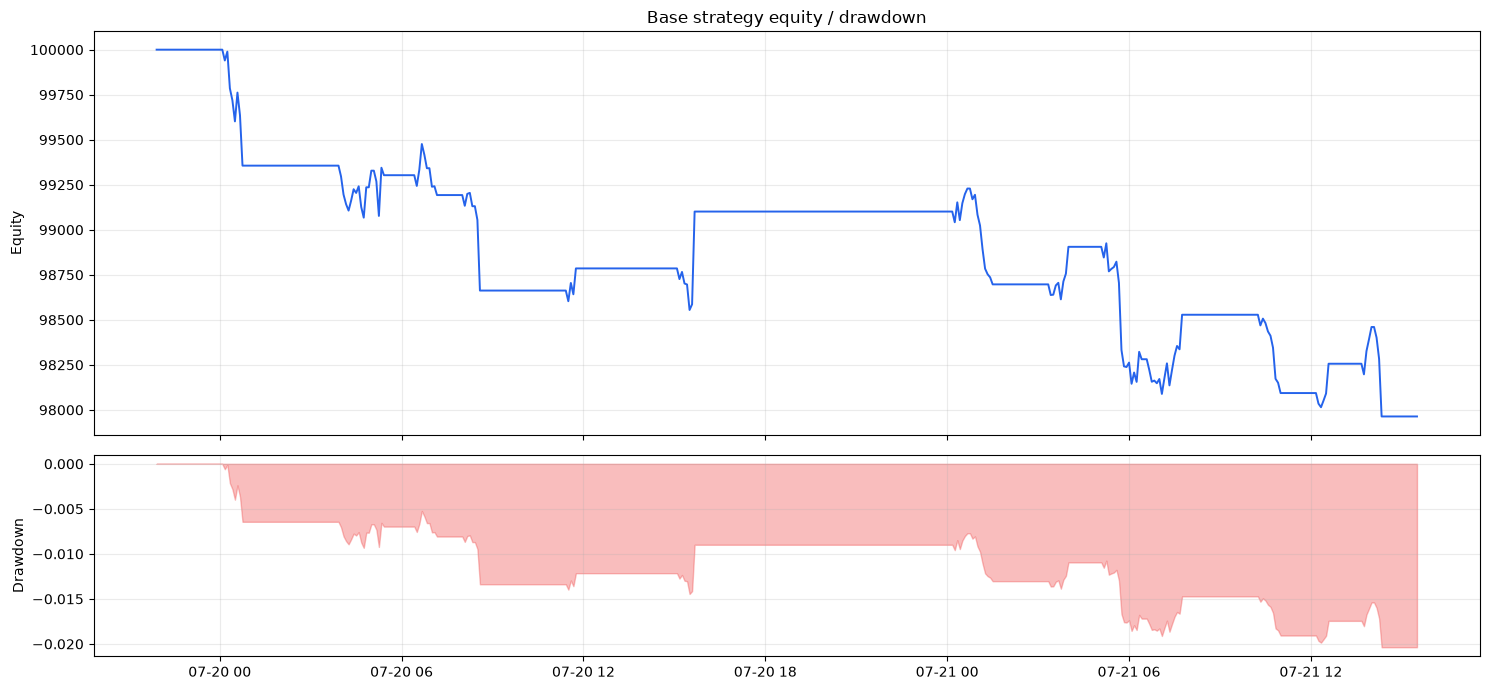

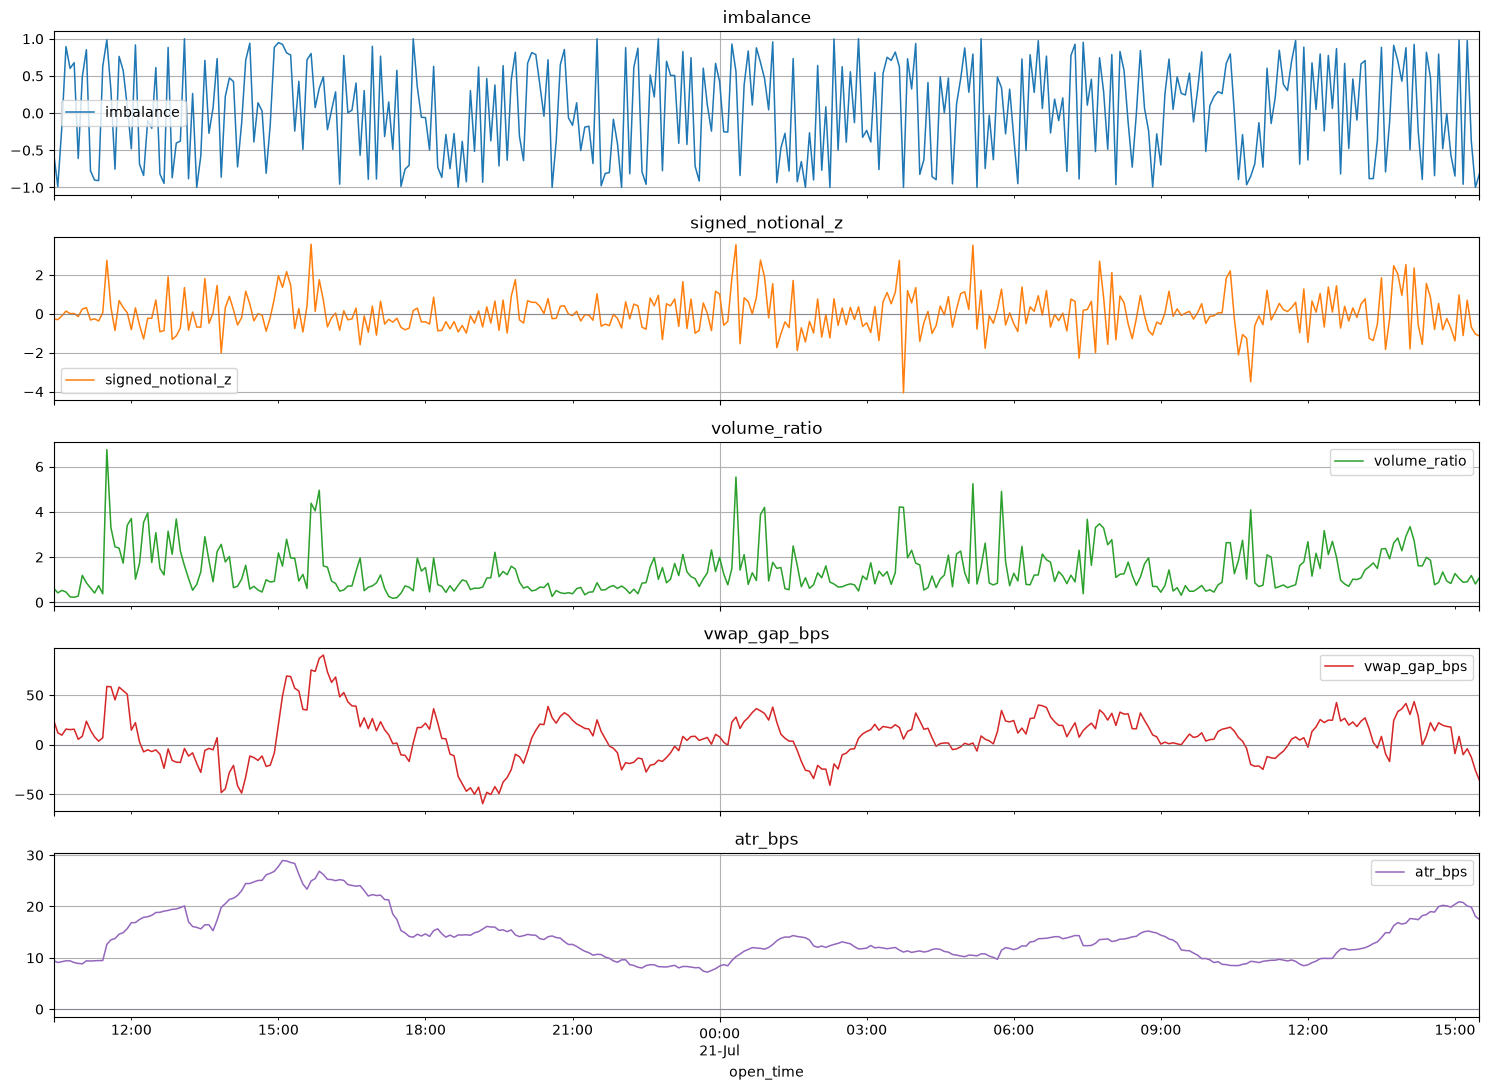

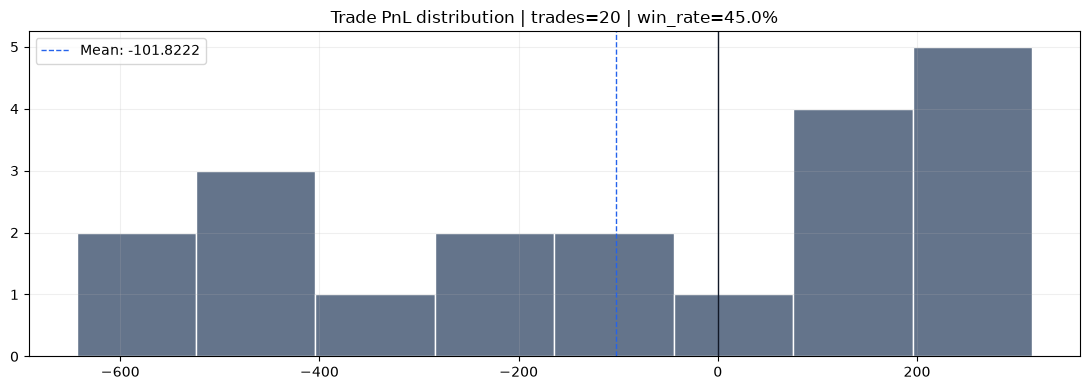

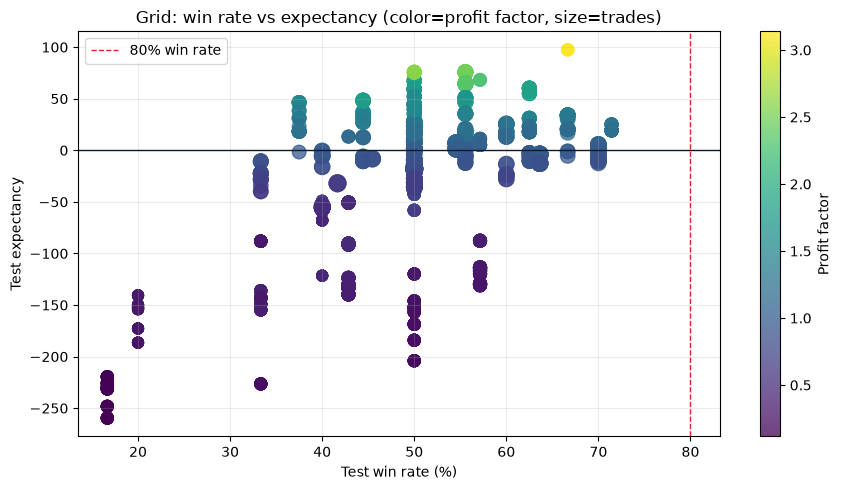

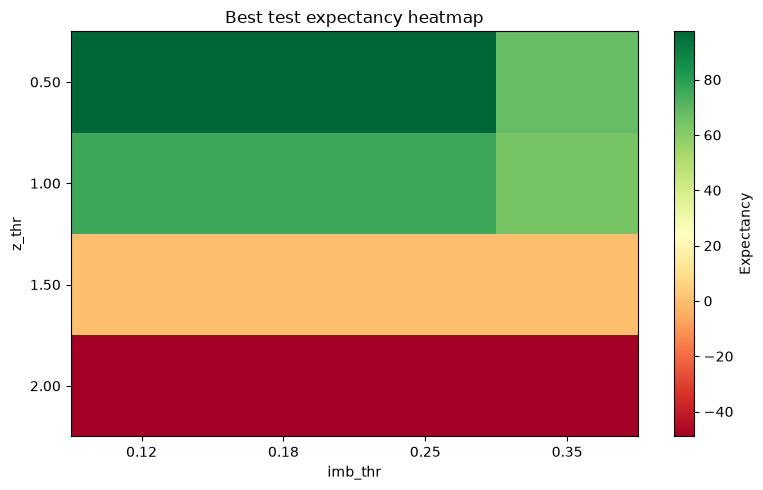

In [8]:
import matplotlib.pyplot as plt


def _pnl_series_from_pf(pf):
    trades = pf.trades.records_readable
    if trades.empty:
        return pd.Series(dtype=float), trades
    pnl_col = "PnL" if "PnL" in trades.columns else ("Return" if "Return" in trades.columns else None)
    if pnl_col is None:
        return pd.Series(dtype=float), trades
    return pd.to_numeric(trades[pnl_col], errors="coerce").dropna(), trades


def plot_signal_price(f, params=None, lookback=350, title=None):
    params = params or base_params
    plot_f = f.dropna(subset=["close"]).tail(lookback).copy()
    entries, exits, short_entries, short_exits = build_signals(plot_f, **signal_only_params(params))

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(plot_f.index, plot_f["close"], color="#1f2937", linewidth=1.25, label="Close")

    long_idx = plot_f.index[entries.reindex(plot_f.index).fillna(False)]
    short_idx = plot_f.index[short_entries.reindex(plot_f.index).fillna(False)]
    exit_idx = plot_f.index[(exits | short_exits).reindex(plot_f.index).fillna(False)]

    if len(long_idx):
        ax.scatter(long_idx, plot_f.loc[long_idx, "close"], marker="^", s=70, color="#16a34a", label="Long entry", zorder=3)
    if len(short_idx):
        ax.scatter(short_idx, plot_f.loc[short_idx, "close"], marker="v", s=70, color="#dc2626", label="Short entry", zorder=3)
    if len(exit_idx):
        ax.scatter(exit_idx, plot_f.loc[exit_idx, "close"], marker="x", s=35, color="#6b7280", label="Exit", zorder=3)

    ax.set_title(title or f"{CCXT_SYMBOL} price + signals ({DATA_MODE}, {BACKTEST_FREQ})")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_equity_drawdown(pf, title="Strategy equity / drawdown"):
    equity = pf.value()
    equity = pd.Series(equity, index=getattr(equity, "index", None)).dropna()
    drawdown = equity / equity.cummax() - 1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(equity.index, equity.values, color="#2563eb", linewidth=1.4)
    ax1.set_title(title)
    ax1.set_ylabel("Equity")
    ax1.grid(True, alpha=0.25)

    ax2.fill_between(drawdown.index, drawdown.values, 0, color="#ef4444", alpha=0.35)
    ax2.set_ylabel("Drawdown")
    ax2.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_feature_panel(f, lookback=350):
    cols = [c for c in ["imbalance", "signed_notional_z", "volume_ratio", "vwap_gap_bps", "atr_bps"] if c in f.columns]
    if not cols:
        print("Feature panel icin kolon yok.")
        return
    plot_f = f[cols].tail(lookback)
    axes = plot_f.plot(subplots=True, figsize=(15, 2.2 * len(cols)), linewidth=1.1, grid=True, title=cols)
    for ax in np.ravel(axes):
        ax.axhline(0, color="#6b7280", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_trade_distribution(pf):
    pnl, trades = _pnl_series_from_pf(pf)
    if pnl.empty:
        print("Trade PnL histogrami icin trade yok.")
        return
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(pnl, bins=min(40, max(8, int(np.sqrt(len(pnl)) * 2))), color="#64748b", edgecolor="white")
    ax.axvline(0, color="#111827", linewidth=1)
    ax.axvline(pnl.mean(), color="#2563eb", linestyle="--", linewidth=1, label=f"Mean: {pnl.mean():.4f}")
    ax.set_title(f"Trade PnL distribution | trades={len(pnl)} | win_rate={(pnl > 0).mean():.1%}")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_grid_diagnostics(grid):
    if grid is None or grid.empty:
        print("Grid plot icin grid_results yok/bos.")
        return
    g = grid.copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    size = np.clip(g.get("test_trades", pd.Series(1, index=g.index)).fillna(1), 1, None) * 12
    color = g["test_profit_factor"].replace(np.inf, np.nan).clip(upper=5)
    sc = ax.scatter(g["test_win_rate_pct"], g["test_expectancy"], s=size, c=color, cmap="viridis", alpha=0.75)
    ax.axhline(0, color="#111827", linewidth=1)
    ax.axvline(80, color="#dc2626", linestyle="--", linewidth=1, label="80% win rate")
    ax.set_xlabel("Test win rate (%)")
    ax.set_ylabel("Test expectancy")
    ax.set_title("Grid: win rate vs expectancy (color=profit factor, size=trades)")
    ax.legend(loc="best")
    fig.colorbar(sc, ax=ax, label="Profit factor")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    if {"imb_thr", "z_thr", "test_expectancy"}.issubset(g.columns):
        pivot = g.pivot_table(index="z_thr", columns="imb_thr", values="test_expectancy", aggfunc="max")
        fig, ax = plt.subplots(figsize=(8, 5))
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{x:.2f}" for x in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{x:.2f}" for x in pivot.index])
        ax.set_xlabel("imb_thr")
        ax.set_ylabel("z_thr")
        ax.set_title("Best test expectancy heatmap")
        fig.colorbar(im, ax=ax, label="Expectancy")
        plt.tight_layout()
        plt.show()


if not features.empty:
    cols = [c for c in ["close", "imbalance", "signed_notional_z", "volume_ratio", "vwap_gap_bps", "atr_bps"] if c in features.columns]
    display(features[cols].tail(250).describe())

    if "pf_base" not in globals():
        pf_base, metrics_base = run_vectorbt(features.dropna(subset=["close"]), base_params)

    plot_signal_price(features, base_params, lookback=350, title="Base signals on price")
    plot_equity_drawdown(pf_base, title="Base strategy equity / drawdown")
    plot_feature_panel(features, lookback=350)
    plot_trade_distribution(pf_base)

    if "grid_results" in globals() and not grid_results.empty:
        plot_grid_diagnostics(grid_results)
else:
    print("Plot icin feature yok.")


## Live Order Book Collector

Historical full L2 elinde yoksa yapilacak is:

1. `aggTrades` ile trade-flow modelini hemen arastir.
2. Ayni anda `depth@100ms` ve `bookTicker` toplamaya basla.
3. Snapshot + diff update sequence'i ile local order book rebuild et.
4. Backtest'i vectorbt candle motorundan event-driven replay'e tasima kararini depth datasindan sonra ver.

Asagidaki collector opsiyoneldir. `websocket-client` yoksa `%pip install websocket-client` gerekir. Dosya yazmak istemiyorsan `out_path=None` verip memory'de tutabilirsin.


In [9]:
def depth_snapshot_rest(symbol=SYMBOL, limit=1000):
    return _request_json("/api/v3/depth", {"symbol": symbol, "limit": limit})


def top_book_features(snapshot, levels=20):
    bids = pd.DataFrame(snapshot["bids"], columns=["price", "qty"]).astype(float).head(levels)
    asks = pd.DataFrame(snapshot["asks"], columns=["price", "qty"]).astype(float).head(levels)
    best_bid = bids["price"].iloc[0]
    best_ask = asks["price"].iloc[0]
    mid = (best_bid + best_ask) / 2
    spread_bps = (best_ask - best_bid) / mid * 10_000
    bid_depth = bids["qty"].sum()
    ask_depth = asks["qty"].sum()
    depth_imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth)
    return {
        "lastUpdateId": snapshot.get("lastUpdateId"),
        "best_bid": best_bid,
        "best_ask": best_ask,
        "mid": mid,
        "spread_bps": spread_bps,
        "bid_depth": bid_depth,
        "ask_depth": ask_depth,
        "depth_imbalance": depth_imbalance,
    }


try:
    snap = depth_snapshot_rest(SYMBOL, limit=100)
    display(pd.Series(top_book_features(snap, levels=20)).to_frame("snapshot"))
except Exception as exc:
    print("Snapshot cekilemedi; Binance erisim/TLS/region olabilir.")
    print(type(exc).__name__, str(exc)[:800])


def collect_depth_stream(symbol=SYMBOL, seconds=60, stream="depth@100ms", out_path=None):
    try:
        import websocket
    except ImportError as exc:
        raise ImportError("Canli collector icin `%pip install websocket-client` gerekli.") from exc

    url = f"wss://stream.binance.com:9443/ws/{symbol.lower()}@{stream}"
    rows = []
    started = time.time()

    def on_message(ws, message):
        now = time.time()
        payload = json.loads(message)
        payload["_local_ts"] = now
        rows.append(payload)
        if out_path:
            with open(out_path, "a") as fh:
                fh.write(json.dumps(payload) + "\n")
        if now - started >= seconds:
            ws.close()

    ws = websocket.WebSocketApp(url, on_message=on_message)
    ws.run_forever()
    return pd.DataFrame(rows)


# Ornek:
# depth_events = collect_depth_stream(SYMBOL, seconds=30, out_path="BTCUSDT_depth_events.jsonl")
# display(depth_events.head())


,snapshot
lastUpdateId,9.770269e+10
best_bid,6.657199e+04
best_ask,6.657200e+04
mid,6.657199e+04
spread_bps,1.502133e-03
bid_depth,5.146630e+00
ask_depth,1.154960e+00
depth_imbalance,6.334385e-01


## Signed Futures Historical Data Link Kontrolu

Binance'in `GET /sapi/v1/futures/histDataLink` endpoint'i public archive gibi degil: `USER_DATA` endpoint'i, yani API key/secret ve HMAC signature ister. Bu kisim sadece link talep fonksiyonunu hazirlar; key yoksa calistirma.

Parametreler: `symbol`, `dataType`, `startTime`, `endTime`, `timestamp`, `signature`, opsiyonel `page`, `recvWindow`.

Kaynaklar:

- Binance public data archive: https://github.com/binance/binance-public-data
- Binance spot REST docs: https://developers.binance.com/en/docs/binance-spot-api-docs/rest-api
- Binance WebSocket streams: https://developers.binance.com/docs/binance-spot-api-docs/web-socket-streams
- Futures historical data link swagger/Postman: https://binance.github.io/binance-api-swagger/


In [10]:
def signed_query(params, api_secret):
    query = urllib.parse.urlencode(params, doseq=True)
    signature = hmac.new(api_secret.encode(), query.encode(), hashlib.sha256).hexdigest()
    return query + "&signature=" + signature


def get_futures_hist_data_link(
    api_key,
    api_secret,
    symbol="BTCUSDT",
    data_type="T_DEPTH",
    start_time=None,
    end_time=None,
    page=1,
    recv_window=5000,
):
    if start_time is None or end_time is None:
        raise ValueError("start_time ve end_time UTC timestamp/date olarak verilmeli.")
    params = {
        "symbol": symbol,
        "dataType": data_type,
        "startTime": int(pd.Timestamp(start_time, tz="UTC").timestamp() * 1000),
        "endTime": int(pd.Timestamp(end_time, tz="UTC").timestamp() * 1000),
        "page": int(page),
        "recvWindow": int(recv_window),
        "timestamp": int(time.time() * 1000),
    }
    query = signed_query(params, api_secret)
    url = "https://api.binance.com/sapi/v1/futures/histDataLink?" + query
    headers = {"X-MBX-APIKEY": api_key}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()


# Ornek, key olmadan calistirma:
# link_resp = get_futures_hist_data_link(
#     api_key=os.environ["BINANCE_API_KEY"],
#     api_secret=os.environ["BINANCE_API_SECRET"],
#     symbol="BTCUSDT",
#     data_type="T_DEPTH",
#     start_time="2026-07-19 00:00:00",
#     end_time="2026-07-19 01:00:00",
# )
# link_resp


## Sonraki Arastirma Sirasi

Bu notebook'un dogru kullanim sirasi:

1. Once CCXT ile 5m OHLCV akisini calistir; `DATA_MODE = "ohlcv_proxy"` ise bunu proxy backtest olarak oku.
2. CCXT `fetch_trades` calisiyorsa taker-flow moduna gec; calismiyorsa `aggTrades` archive veya live collector ile trade datasini biriktir.
3. Grid'i train/test ayirarak calistir.
4. Sadece win rate'e degil expectancy/profit factor/drawdown'a bak.
5. Ayni anda depth collector'i calistirip en az birkac gun L2 biriktir.
6. Depth datasi geldikten sonra vectorbt sonucunu event-driven replay ile dogrula.

5 dakikalik frame bu notebook'ta pratik baslangic datasidir. Order-flow alpha icin trade/tick/L2 datasi gelince 15s/1m feature frame'e dusmek daha dogru olur.


BTC/USDT icin CCXT/Notebook verileri

--- CANLI/SON BILGI ---
Son Fiyat : 66571.99
Best Bid  : 66571.99
Best Ask  : 66572.0
Spread    : 0.01
-------------------

Mevcut klines_raw kullaniliyor: (500, 10)


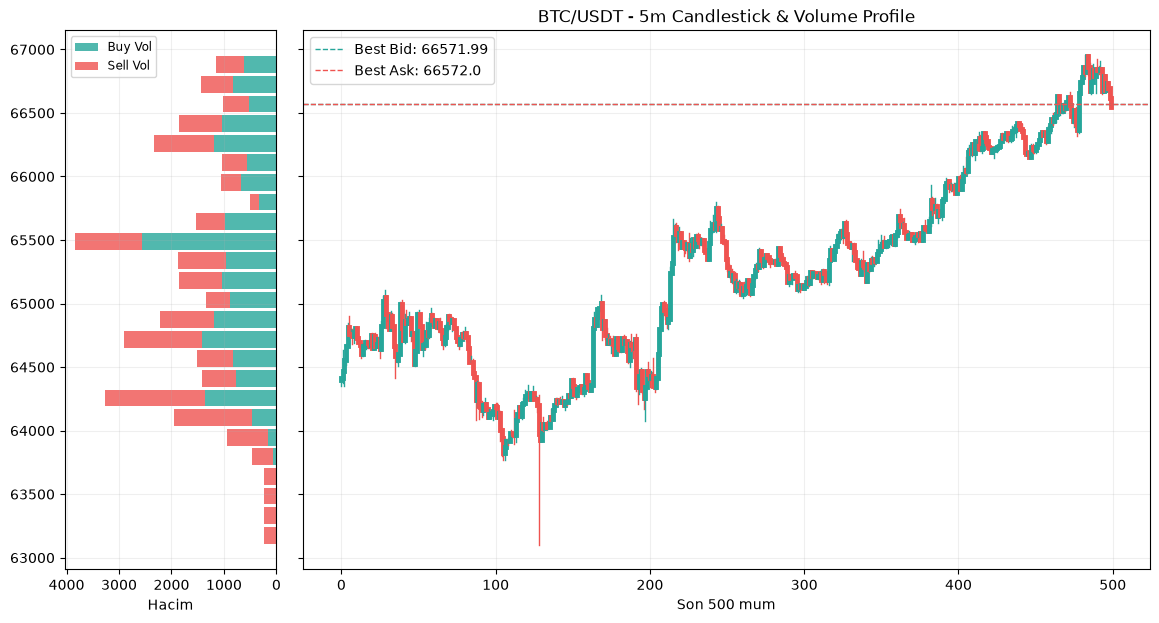

In [11]:
# CCXT sanity check + volume profile
# Bu hucre artik var olan klines_raw'i kullanir; ticker/order-book fail olsa bile OHLCV plot bozulmaz.

import matplotlib.pyplot as plt

try:
    exchange = make_ccxt_exchange()
except Exception as exc:
    exchange = None
    print("CCXT exchange olusturulamadi:", type(exc).__name__, str(exc)[:500])

best_bid = best_ask = last_price = None
if exchange is not None:
    try:
        ticker = load_ccxt_ticker(CCXT_SYMBOL, exchange=exchange)
        best_bid = ticker.get("bid")
        best_ask = ticker.get("ask")
        last_price = ticker.get("last")
    except Exception as exc:
        print("Ticker cekilemedi, OHLCV plot yine devam edecek:", type(exc).__name__, str(exc)[:500])
        try:
            ob = exchange.fetch_order_book(CCXT_SYMBOL, limit=5)
            best_bid = ob["bids"][0][0] if ob.get("bids") else None
            best_ask = ob["asks"][0][0] if ob.get("asks") else None
            last_price = features["close"].iloc[-1] if "features" in globals() and not features.empty else None
        except Exception as ob_exc:
            print("Order book fallback de cekilemedi:", type(ob_exc).__name__, str(ob_exc)[:300])

print(f"{CCXT_SYMBOL} icin CCXT/Notebook verileri")
print("\n--- CANLI/SON BILGI ---")
print(f"Son Fiyat : {last_price}")
print(f"Best Bid  : {best_bid}")
print(f"Best Ask  : {best_ask}")
if best_bid is not None and best_ask is not None:
    print(f"Spread    : {round(best_ask - best_bid, 4)}")
print("-------------------\n")

try:
    if "klines_raw" in globals() and not klines_raw.empty:
        vp_source = klines_raw.copy()
        print(f"Mevcut klines_raw kullaniliyor: {vp_source.shape}")
    elif exchange is not None:
        vp_source = load_ccxt_ohlcv(CCXT_SYMBOL, timeframe=CCXT_TIMEFRAME, limit=CCXT_LIMIT, exchange=exchange)
        print(f"CCXT OHLCV yeniden cekildi: {vp_source.shape}")
    else:
        raise RuntimeError("klines_raw yok ve CCXT exchange olusmadi.")

    vp_df = vp_source.reset_index()
    rename_map = {
        "open_time": "Datetime",
        "timestamp": "Datetime",
        "index": "Datetime",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
    }
    vp_df = vp_df.rename(columns=rename_map)
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        vp_df[col] = pd.to_numeric(vp_df[col], errors="coerce")
    vp_df = vp_df.dropna(subset=["Open", "High", "Low", "Close", "Volume"]).tail(CCXT_LIMIT)

    vp_df["Buy_Vol"] = np.where(vp_df["Close"] >= vp_df["Open"], vp_df["Volume"], 0.0)
    vp_df["Sell_Vol"] = np.where(vp_df["Close"] < vp_df["Open"], vp_df["Volume"], 0.0)

    bins = 25
    price_min = vp_df["Low"].min()
    price_max = vp_df["High"].max()
    price_bins = np.linspace(price_min, price_max, bins + 1)
    buy_profile = np.zeros(bins)
    sell_profile = np.zeros(bins)

    for _, row in vp_df.iterrows():
        bin_indices = np.where((price_bins[:-1] <= row["High"]) & (price_bins[1:] >= row["Low"]))[0]
        if len(bin_indices) > 0:
            buy_profile[bin_indices] += row["Buy_Vol"] / len(bin_indices)
            sell_profile[bin_indices] += row["Sell_Vol"] / len(bin_indices)

    bin_centers = (price_bins[:-1] + price_bins[1:]) / 2
    bin_height = (price_bins[1] - price_bins[0]) * 0.85

    fig, (ax_vp, ax_candle) = plt.subplots(
        1, 2, figsize=(14, 7), sharey=True,
        gridspec_kw={"width_ratios": [1, 4], "wspace": 0.05},
    )

    ax_vp.barh(bin_centers, buy_profile, height=bin_height, color="#26a69a", alpha=0.8, label="Buy Vol")
    ax_vp.barh(bin_centers, sell_profile, height=bin_height, left=buy_profile, color="#ef5350", alpha=0.8, label="Sell Vol")
    ax_vp.invert_xaxis()
    ax_vp.set_xlabel("Hacim")
    ax_vp.legend(loc="upper left", fontsize="small")
    ax_vp.grid(True, alpha=0.2)

    for i in range(len(vp_df)):
        color = "#26a69a" if vp_df["Close"].iloc[i] >= vp_df["Open"].iloc[i] else "#ef5350"
        ax_candle.plot([i, i], [vp_df["Low"].iloc[i], vp_df["High"].iloc[i]], color=color, linewidth=1)
        ax_candle.plot([i, i], [vp_df["Open"].iloc[i], vp_df["Close"].iloc[i]], color=color, linewidth=3.5)

    if best_bid is not None:
        ax_candle.axhline(best_bid, color="#26a69a", linestyle="--", linewidth=1, label=f"Best Bid: {best_bid}")
    if best_ask is not None:
        ax_candle.axhline(best_ask, color="#ef5350", linestyle="--", linewidth=1, label=f"Best Ask: {best_ask}")

    ax_candle.set_title(f"{CCXT_SYMBOL} - {CCXT_TIMEFRAME} Candlestick & Volume Profile")
    ax_candle.set_xlabel(f"Son {len(vp_df)} mum")
    ax_candle.legend(loc="upper left")
    ax_candle.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Volume profile calismadi:", type(exc).__name__, str(exc)[:900])
    print("Ustteki veri hucrelerinde klines_raw dolu mu kontrol et.")


## Strategy V2: POC + Volume + MTF Momentum

Bu bolum onceki flow proxy denemesinden ayrilir ve daha trade edilebilir bir 5m sistem kurar.

Strateji mantigi:

- **POC / volume profile:** Son `N` mumda hacmin en cok toplandigi fiyat bolgesini bulur.
- **Value area:** Volume profile'in en hacimli bolgesinden VAH/VAL bandi cikarir.
- **Volume filtre:** Sadece hacim rolling median'a gore genislediyse sinyal alir.
- **Multi-timeframe momentum:** 5m fiyat, 15m ve 1h EMA momentum ayni yondeyse trade eder.
- **Entry:** POC reclaim / POC ustu continuation + recent-high break kombinasyonu.
- **Exit:** Time exit + vectorbt stop/take-profit.

Bu bir "win rate yuksek olsun" oyuncagi degil; win rate, expectancy, profit factor ve drawdown birlikte degerlendirilir.


In [12]:
# ==========
# Strategy V2 settings
# ==========

POC_WINDOW = 96          # 96 * 5m = 8 saat
POC_BINS = 36
VALUE_AREA_PCT = 0.70
MTF_FAST = 12
MTF_SLOW = 36

# Leverage / risk settings
LEVERAGE = 3.0
MAX_PRINCIPAL_RISK_PCT = 0.01
INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP = True
MIN_EFFECTIVE_SL_STOP = 0.0005
V2_DIRECTION = "long_only"

V2_BASE_PARAMS = {
    "poc_window": 96,
    "poc_bins": 36,
    "value_area_pct": 0.70,
    "vol_ratio_thr": 1.12,
    "volume_z_thr": -0.10,
    "poc_band_bps": 18.0,
    "break_lookback": 18,
    "momentum_5m_thr": 0.0,
    "hold_bars": 18,
    # Configured stop can be wider, but run_poc_mtf_backtest caps it so
    # 3x stop loss does not exceed 1% of principal before/after costs.
    "sl_stop": 0.0060,
    "tp_stop": 0.0040,
    "leverage": LEVERAGE,
    "max_principal_risk_pct": MAX_PRINCIPAL_RISK_PCT,
    "include_costs_in_risk_cap": INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP,
}

print("V2_BASE_PARAMS", V2_BASE_PARAMS)
print(
    "Risk rule:",
    f"{LEVERAGE:.1f}x leverage, max principal risk {MAX_PRINCIPAL_RISK_PCT:.2%} per trade"
)
print("V2_DIRECTION", V2_DIRECTION)


V2_BASE_PARAMS {'poc_window': 96, 'poc_bins': 36, 'value_area_pct': 0.7, 'vol_ratio_thr': 1.12, 'volume_z_thr': -0.1, 'poc_band_bps': 18.0, 'break_lookback': 18, 'momentum_5m_thr': 0.0, 'hold_bars': 18, 'sl_stop': 0.006, 'tp_stop': 0.004, 'leverage': 3.0, 'max_principal_risk_pct': 0.01, 'include_costs_in_risk_cap': True}
Risk rule: 3.0x leverage, max principal risk 1.00% per trade
V2_DIRECTION long_only


In [13]:
def _ohlcv_for_strategy(klines_or_features):
    df = klines_or_features.copy()
    df = df.rename(columns={c: c.lower() for c in df.columns})
    if "open_time" in df.columns and not isinstance(df.index, pd.DatetimeIndex):
        df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
        df = df.set_index("open_time")
    if "timestamp" in df.columns and not isinstance(df.index, pd.DatetimeIndex):
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
        df = df.set_index("timestamp")
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Strategy V2 icin DatetimeIndex lazim.")
    required = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"OHLCV kolonlari eksik: {missing}")
    for col in required:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df[required].dropna().sort_index()


def _profile_from_window(high, low, close, volume, bins=36, value_area_pct=0.70):
    hmax = float(np.nanmax(high))
    lmin = float(np.nanmin(low))
    if not np.isfinite(hmax) or not np.isfinite(lmin) or hmax <= lmin:
        return np.nan, np.nan, np.nan

    edges = np.linspace(lmin, hmax, int(bins) + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    profile = np.zeros(int(bins), dtype=float)

    for h, l, c, v in zip(high, low, close, volume):
        if not np.isfinite(v) or v <= 0:
            continue
        if not np.isfinite(h) or not np.isfinite(l) or h <= l:
            idx = np.searchsorted(edges, c, side="right") - 1
            if 0 <= idx < len(profile):
                profile[idx] += v
            continue
        idxs = np.where((edges[:-1] <= h) & (edges[1:] >= l))[0]
        if len(idxs):
            profile[idxs] += v / len(idxs)

    total = profile.sum()
    if total <= 0:
        return np.nan, np.nan, np.nan

    poc_idx = int(np.argmax(profile))
    poc = centers[poc_idx]

    selected = {poc_idx}
    cum_vol = profile[poc_idx]
    left = poc_idx - 1
    right = poc_idx + 1
    target = total * float(value_area_pct)

    while cum_vol < target and (left >= 0 or right < len(profile)):
        left_vol = profile[left] if left >= 0 else -1
        right_vol = profile[right] if right < len(profile) else -1
        if right_vol >= left_vol:
            selected.add(right)
            cum_vol += max(right_vol, 0)
            right += 1
        else:
            selected.add(left)
            cum_vol += max(left_vol, 0)
            left -= 1

    idx_sorted = sorted(selected)
    val = edges[max(0, idx_sorted[0])]
    vah = edges[min(len(edges) - 1, idx_sorted[-1] + 1)]
    return poc, vah, val


def add_rolling_poc(df, window=96, bins=36, value_area_pct=0.70):
    f = df.copy()
    poc = np.full(len(f), np.nan)
    vah = np.full(len(f), np.nan)
    val = np.full(len(f), np.nan)
    highs = f["high"].to_numpy(dtype=float)
    lows = f["low"].to_numpy(dtype=float)
    closes = f["close"].to_numpy(dtype=float)
    vols = f["volume"].to_numpy(dtype=float)
    w = int(window)

    for i in range(w, len(f)):
        j = slice(i - w, i)
        poc[i], vah[i], val[i] = _profile_from_window(
            highs[j], lows[j], closes[j], vols[j], bins=bins, value_area_pct=value_area_pct
        )

    f["poc"] = poc
    f["vah"] = vah
    f["val"] = val
    f["poc_dist_bps"] = (f["close"] / f["poc"] - 1) * 10_000
    f["vah_dist_bps"] = (f["close"] / f["vah"] - 1) * 10_000
    f["val_dist_bps"] = (f["close"] / f["val"] - 1) * 10_000
    f["poc_slope_bps"] = f["poc"].pct_change(12) * 10_000
    return f


def _rsi(close, window=14):
    delta = close.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    rs = up.ewm(alpha=1 / window, adjust=False).mean() / down.ewm(alpha=1 / window, adjust=False).mean().replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def add_mtf_momentum(df, fast=12, slow=36):
    f = df.copy()
    f["ema_fast_5m"] = f["close"].ewm(span=fast, adjust=False).mean()
    f["ema_slow_5m"] = f["close"].ewm(span=slow, adjust=False).mean()
    f["mom_5m_bps"] = (f["ema_fast_5m"] / f["ema_slow_5m"] - 1) * 10_000
    f["rsi_5m"] = _rsi(f["close"], 14)

    for label, rule in {"15m": "15min", "1h": "1h"}.items():
        c = f["close"].resample(rule).last().dropna()
        mtf = pd.DataFrame(index=c.index)
        mtf[f"ema_fast_{label}"] = c.ewm(span=fast, adjust=False).mean()
        mtf[f"ema_slow_{label}"] = c.ewm(span=slow, adjust=False).mean()
        mtf[f"mom_{label}_bps"] = (mtf[f"ema_fast_{label}"] / mtf[f"ema_slow_{label}"] - 1) * 10_000
        mtf[f"rsi_{label}"] = _rsi(c, 14)
        f = f.join(mtf.reindex(f.index, method="ffill"))

    f["mtf_up"] = (
        (f["mom_5m_bps"] > 0)
        & (f["mom_15m_bps"] > 0)
        & (f["mom_1h_bps"] > 0)
        & (f["rsi_5m"] > 50)
    )
    f["mtf_down"] = (
        (f["mom_5m_bps"] < 0)
        & (f["mom_15m_bps"] < 0)
        & (f["mom_1h_bps"] < 0)
        & (f["rsi_5m"] < 50)
    )
    return f


def build_poc_mtf_features(klines, params=None):
    params = params or V2_BASE_PARAMS
    f = _ohlcv_for_strategy(klines)
    f = add_rolling_poc(
        f,
        window=params.get("poc_window", POC_WINDOW),
        bins=params.get("poc_bins", POC_BINS),
        value_area_pct=params.get("value_area_pct", VALUE_AREA_PCT),
    )
    f = add_mtf_momentum(f, fast=MTF_FAST, slow=MTF_SLOW)
    f["ret_1"] = f["close"].pct_change()
    f["atr_bps"] = ((f["high"] - f["low"]).rolling(20, min_periods=5).mean() / f["close"]) * 10_000
    f["volume_ratio"] = f["volume"] / f["volume"].rolling(48, min_periods=12).median().replace(0, np.nan)
    f["volume_z"] = rolling_zscore(f["volume"], 48)
    f["recent_high"] = f["close"].rolling(params.get("break_lookback", 18), min_periods=6).max().shift(1)
    f["recent_low"] = f["close"].rolling(params.get("break_lookback", 18), min_periods=6).min().shift(1)
    f["above_poc"] = f["close"] > f["poc"]
    f["below_poc"] = f["close"] < f["poc"]
    f["poc_reclaim_up"] = (f["close"] > f["poc"]) & (f["close"].shift(1) <= f["poc"].shift(1))
    f["poc_reclaim_down"] = (f["close"] < f["poc"]) & (f["close"].shift(1) >= f["poc"].shift(1))
    return f.replace([np.inf, -np.inf], np.nan)


In [14]:
def poc_mtf_signal_params(params):
    keys = {
        "vol_ratio_thr", "volume_z_thr", "poc_band_bps",
        "break_lookback", "momentum_5m_thr", "hold_bars",
    }
    return {k: params[k] for k in keys if k in params}


def build_poc_mtf_signals(f, params=None):
    params = params or V2_BASE_PARAMS
    p = poc_mtf_signal_params(params)
    vol_ratio_thr = p.get("vol_ratio_thr", 1.12)
    volume_z_thr = p.get("volume_z_thr", -0.10)
    poc_band_bps = p.get("poc_band_bps", 18.0)
    break_lookback = int(p.get("break_lookback", 18))
    momentum_5m_thr = p.get("momentum_5m_thr", 0.0)
    hold_bars = int(p.get("hold_bars", 18))

    recent_high = f["close"].rolling(break_lookback, min_periods=6).max().shift(1)
    recent_low = f["close"].rolling(break_lookback, min_periods=6).min().shift(1)

    volume_ok = (f["volume_ratio"] >= vol_ratio_thr) & (f["volume_z"] >= volume_z_thr)
    near_or_above_poc = f["poc_dist_bps"] > -poc_band_bps
    near_or_below_poc = f["poc_dist_bps"] < poc_band_bps

    long_setup = (
        f["mtf_up"].fillna(False)
        & (f["mom_5m_bps"] > momentum_5m_thr)
        & volume_ok
        & near_or_above_poc
        & (
            f["poc_reclaim_up"].fillna(False)
            | ((f["close"] > recent_high) & (f["close"] > f["poc"]))
            | ((f["low"] <= f["poc"]) & (f["close"] > f["open"]) & (f["close"] > f["poc"]))
        )
    )

    short_setup = (
        f["mtf_down"].fillna(False)
        & (f["mom_5m_bps"] < -momentum_5m_thr)
        & volume_ok
        & near_or_below_poc
        & (
            f["poc_reclaim_down"].fillna(False)
            | ((f["close"] < recent_low) & (f["close"] < f["poc"]))
            | ((f["high"] >= f["poc"]) & (f["close"] < f["open"]) & (f["close"] < f["poc"]))
        )
    )

    entries = long_setup.fillna(False)
    short_entries = short_setup.fillna(False)
    exits = entries.shift(hold_bars).fillna(False) | short_entries
    short_exits = short_entries.shift(hold_bars).fillna(False) | entries
    return entries.astype(bool), exits.astype(bool), short_entries.astype(bool), short_exits.astype(bool)


def max_sl_stop_for_principal_risk(params=None):
    params = params or V2_BASE_PARAMS
    leverage = float(params.get("leverage", LEVERAGE))
    max_principal_risk_pct = float(params.get("max_principal_risk_pct", MAX_PRINCIPAL_RISK_PCT))
    include_costs = bool(params.get("include_costs_in_risk_cap", INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP))

    max_stop = max_principal_risk_pct / leverage
    if include_costs:
        # Approx round-trip cost on leveraged notional.
        max_stop -= 2 * (float(FEE) + float(SLIPPAGE))
    if max_stop <= 0:
        raise ValueError(
            "Fee/slippage buffer is larger than allowed risk. "
            "Lower fees/slippage, lower leverage, or raise max_principal_risk_pct."
        )
    return max(max_stop, MIN_EFFECTIVE_SL_STOP)


def effective_sl_stop_for_params(params=None):
    params = params or V2_BASE_PARAMS
    configured = params.get("sl_stop", None)
    cap = max_sl_stop_for_principal_risk(params)
    if configured is None:
        return cap
    return min(float(configured), cap)


def principal_equity_from_leveraged_pf(pf, leverage):
    sim_init_cash = INIT_CASH * float(leverage)
    pf_value = pd.Series(pf.value())
    return INIT_CASH + (pf_value - sim_init_cash)


def leveraged_trade_metrics(pf, leverage, effective_sl_stop, configured_sl_stop):
    trades = pf.trades.records_readable
    principal_equity = principal_equity_from_leveraged_pf(pf, leverage)
    total_return = float(principal_equity.iloc[-1] / INIT_CASH - 1)
    dd = principal_equity / principal_equity.cummax() - 1
    max_dd = float(dd.min())

    out = {
        "trades": 0,
        "win_rate": np.nan,
        "total_return": total_return,
        "max_drawdown": max_dd,
        "profit_factor": np.nan,
        "expectancy": np.nan,
        "avg_win": np.nan,
        "avg_loss": np.nan,
        "payoff": np.nan,
    }
    if not trades.empty:
        pnl_col = "PnL" if "PnL" in trades.columns else "Return"
        pnl = pd.to_numeric(trades[pnl_col], errors="coerce").dropna()
        wins = pnl[pnl > 0]
        losses = pnl[pnl < 0]
        gross_win = wins.sum()
        gross_loss = losses.abs().sum()
        avg_win = wins.mean() if len(wins) else 0.0
        avg_loss = losses.mean() if len(losses) else 0.0
        out.update({
            "trades": int(len(pnl)),
            "win_rate": float((pnl > 0).mean()),
            "profit_factor": float(gross_win / gross_loss) if gross_loss > 0 else np.inf,
            "expectancy": float(pnl.mean()),
            "avg_win": float(avg_win),
            "avg_loss": float(avg_loss),
            "payoff": float(abs(avg_win / avg_loss)) if avg_loss < 0 else np.inf,
        })

    out.update({
        "leverage": float(leverage),
        "principal_init_cash": float(INIT_CASH),
        "sim_init_cash": float(INIT_CASH * float(leverage)),
        "configured_sl_stop": float(configured_sl_stop) if configured_sl_stop is not None else np.nan,
        "effective_sl_stop": float(effective_sl_stop),
        "stop_risk_pct_before_costs": float(leverage * effective_sl_stop),
        "stop_risk_pct_with_cost_buffer": float(leverage * (effective_sl_stop + 2 * (FEE + SLIPPAGE))),
        "max_principal_risk_pct": float(MAX_PRINCIPAL_RISK_PCT),
        "sim_cash_total_return": float(pf.total_return()),
    })
    return out


def run_poc_mtf_backtest(f, params=None, direction="both"):
    params = params or V2_BASE_PARAMS
    entries, exits, short_entries, short_exits = build_poc_mtf_signals(f, params)
    if direction == "long_only":
        short_entries = pd.Series(False, index=f.index)
        short_exits = pd.Series(False, index=f.index)
    elif direction == "short_only":
        entries = pd.Series(False, index=f.index)
        exits = pd.Series(False, index=f.index)

    leverage = float(params.get("leverage", LEVERAGE))
    configured_sl_stop = params.get("sl_stop", None)
    effective_sl_stop = effective_sl_stop_for_params(params)
    sim_init_cash = INIT_CASH * leverage

    pf = vbt.Portfolio.from_signals(
        f["close"].astype(float),
        entries=entries,
        exits=exits,
        short_entries=short_entries,
        short_exits=short_exits,
        size=np.inf,
        init_cash=sim_init_cash,
        fees=FEE,
        slippage=SLIPPAGE,
        open=f["open"].astype(float),
        high=f["high"].astype(float),
        low=f["low"].astype(float),
        sl_stop=effective_sl_stop,
        tp_stop=params.get("tp_stop", 0.0040),
        freq=CCXT_PANDAS_FREQ,
    )
    m = leveraged_trade_metrics(pf, leverage, effective_sl_stop, configured_sl_stop)
    m.update({
        "entries": int(entries.sum()),
        "short_entries": int(short_entries.sum()),
        "data_mode": "poc_volume_mtf_3x_risk_cap",
        "freq": CCXT_PANDAS_FREQ,
    })
    return pf, m


if "klines_raw" not in globals() or klines_raw.empty:
    raise RuntimeError("Once CCXT veri hucrelerini calistir: klines_raw dolu olmali.")

poc_features = build_poc_mtf_features(klines_raw, V2_BASE_PARAMS)
poc_features_bt = poc_features.dropna(subset=["close", "poc", "mom_15m_bps", "mom_1h_bps", "volume_ratio"]).copy()
pf_poc_base, metrics_poc_base = run_poc_mtf_backtest(poc_features_bt, V2_BASE_PARAMS, direction=V2_DIRECTION)

print("poc_features", poc_features.shape)
print("poc_features_bt", poc_features_bt.shape)
display(pd.Series(metrics_poc_base).to_frame("poc_mtf_base"))
display(pf_poc_base.trades.records_readable.tail(10))


poc_features (500, 36)
poc_features_bt (404, 36)


,poc_mtf_base
trades,15
win_rate,0.333333
total_return,-0.047632
max_drawdown,-0.047632
profit_factor,0.393171
expectancy,-317.549404
avg_win,617.230321
avg_loss,-784.939267
payoff,0.786342
leverage,3.0


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
5,5,0,4.565110,2026-07-21 03:05:00+00:00,65465.100402,119.542162,2026-07-21 04:05:00+00:00,65713.818040,119.996331,895.884960,0.002998,Long,Closed,5
6,6,0,4.572318,2026-07-21 04:40:00+00:00,65557.758930,119.900373,2026-07-21 05:05:00+00:00,65527.501878,119.845035,-378.090276,-0.001261,Long,Closed,6
7,7,0,4.547807,2026-07-21 05:45:00+00:00,65827.982964,119.749197,2026-07-21 06:05:00+00:00,65676.122148,119.472943,-929.855893,-0.003106,Long,Closed,7
8,8,0,4.524257,2026-07-21 06:35:00+00:00,65965.200402,119.377403,2026-07-21 06:50:00+00:00,65909.815400,119.277173,-489.230550,-0.001639,Long,Closed,8
9,9,0,4.512473,2026-07-21 07:30:00+00:00,66029.093178,119.181789,2026-07-21 08:05:00+00:00,66168.773598,119.433911,391.688367,0.001315,Long,Closed,9
10,10,0,4.498905,2026-07-21 08:20:00+00:00,66315.250398,119.338402,2026-07-21 09:00:00+00:00,66178.281696,119.091918,-854.639486,-0.002865,Long,Closed,10
11,11,0,4.479760,2026-07-21 10:20:00+00:00,66407.958936,118.996683,2026-07-21 10:50:00+00:00,66253.038016,118.719080,-931.724278,-0.003132,Long,Closed,11
12,12,0,4.464991,2026-07-21 12:10:00+00:00,66419.021148,118.624142,2026-07-21 13:40:00+00:00,66354.716402,118.509294,-524.253572,-0.001768,Long,Closed,12
13,13,0,4.434674,2026-07-21 13:50:00+00:00,66754.918314,118.414525,2026-07-21 14:05:00+00:00,66810.425242,118.512987,9.227628,0.000031,Long,Closed,13
14,14,0,4.421376,2026-07-21 14:10:00+00:00,66957.788880,118.418214,2026-07-21 14:15:00+00:00,66801.585280,118.141960,-927.194964,-0.003132,Long,Closed,14


In [15]:
from itertools import product

if "split_train_test" not in globals():
    def split_train_test(f, train_frac=0.7):
        n = len(f)
        cut = max(1, int(n * train_frac))
        return f.iloc[:cut].copy(), f.iloc[cut:].copy()


def evaluate_poc_mtf_grid(f, min_test_trades=3, direction="both"):
    f = f.dropna(subset=["close", "poc", "mom_15m_bps", "mom_1h_bps", "volume_ratio"]).copy()
    train, test = split_train_test(f, train_frac=0.70)
    rows = []

    for vol_thr, vol_z, poc_band, hold_bars, sl_stop, tp_stop, mom_thr in product(
        [0.95, 1.10, 1.25],
        [-0.30, 0.10],
        [18.0, 40.0],
        [10, 18, 30],
        [0.0015, 0.0025, 0.0060],
        [0.0025, 0.0040],
        [0.0, 3.0],
    ):
        params = {
            **V2_BASE_PARAMS,
            "vol_ratio_thr": vol_thr,
            "volume_z_thr": vol_z,
            "poc_band_bps": poc_band,
            "hold_bars": hold_bars,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
            "momentum_5m_thr": mom_thr,
            "leverage": LEVERAGE,
            "max_principal_risk_pct": MAX_PRINCIPAL_RISK_PCT,
            "include_costs_in_risk_cap": INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP,
        }
        try:
            _, mt = run_poc_mtf_backtest(train, params, direction=direction)
            _, ms = run_poc_mtf_backtest(test, params, direction=direction)
        except Exception:
            continue
        row = {k: params[k] for k in [
            "vol_ratio_thr", "volume_z_thr", "poc_band_bps", "hold_bars",
            "sl_stop", "tp_stop", "momentum_5m_thr"
        ]}
        row.update({f"train_{k}": v for k, v in mt.items()})
        row.update({f"test_{k}": v for k, v in ms.items()})
        rows.append(row)

    res = pd.DataFrame(rows)
    if res.empty:
        return res
    res["test_win_rate_pct"] = res["test_win_rate"] * 100
    res["train_win_rate_pct"] = res["train_win_rate"] * 100
    res["pf_capped"] = res["test_profit_factor"].replace(np.inf, 10).fillna(0).clip(upper=10)
    res["score"] = (
        2.0 * res["test_expectancy"].fillna(-np.inf).rank(pct=True)
        + 1.5 * res["pf_capped"].rank(pct=True)
        + 1.0 * res["test_total_return"].fillna(-np.inf).rank(pct=True)
        + 0.7 * res["test_win_rate"].fillna(0).rank(pct=True)
        - 1.2 * res["test_max_drawdown"].abs().fillna(1).rank(pct=True)
    )
    res["high_wr_bad_expectancy"] = (res["test_win_rate"] >= 0.60) & (res["test_expectancy"] <= 0)
    res = res[res["test_trades"] >= min_test_trades].sort_values(
        ["score", "test_expectancy", "test_profit_factor", "test_win_rate"],
        ascending=False,
    )
    return res


poc_grid_results = evaluate_poc_mtf_grid(poc_features_bt, min_test_trades=2, direction=V2_DIRECTION)
display(poc_grid_results.head(25))

if not poc_grid_results.empty:
    robust_candidates = poc_grid_results[
        (poc_grid_results["train_expectancy"] > 0)
        & (poc_grid_results["test_expectancy"] > 0)
        & (poc_grid_results["train_profit_factor"] > 1)
        & (poc_grid_results["test_profit_factor"] > 1)
    ].copy()
    if not robust_candidates.empty:
        robust_candidates["robust_score"] = (
            robust_candidates["train_expectancy"].rank(pct=True)
            + robust_candidates["test_expectancy"].rank(pct=True)
            + robust_candidates["train_profit_factor"].clip(upper=5).rank(pct=True)
            + robust_candidates["test_profit_factor"].clip(upper=5).rank(pct=True)
            - robust_candidates["test_max_drawdown"].abs().rank(pct=True)
        )
        selection_pool = robust_candidates.sort_values(
            ["robust_score", "test_expectancy", "train_expectancy"],
            ascending=False,
        )
        print("ROBUST train+test pozitif aday sayisi:", len(selection_pool))
    else:
        selection_pool = poc_grid_results
        print("ROBUST aday yok; test score siralamasi kullaniliyor.")

    best_v2_params = {**V2_BASE_PARAMS}
    for k in ["vol_ratio_thr", "volume_z_thr", "poc_band_bps", "hold_bars", "sl_stop", "tp_stop", "momentum_5m_thr"]:
        best_v2_params[k] = selection_pool.iloc[0][k]
    best_v2_params["hold_bars"] = int(best_v2_params["hold_bars"])
    pf_poc_best, metrics_poc_best = run_poc_mtf_backtest(poc_features_bt, best_v2_params, direction=V2_DIRECTION)
    print("best_v2_params", best_v2_params)
    display(pd.Series(metrics_poc_best).to_frame("poc_mtf_best_full_sample"))

    print("Secilen robust/test adaylari:")
    display(selection_pool.head(15))

    sixty_plus = poc_grid_results[
        (poc_grid_results["test_win_rate"] >= 0.60)
        & (poc_grid_results["test_expectancy"] > 0)
    ]
    print("60%+ test win rate ve pozitif test expectancy adaylari:", len(sixty_plus))
    display(sixty_plus.head(15))
else:
    best_v2_params = V2_BASE_PARAMS.copy()
    pf_poc_best, metrics_poc_best = pf_poc_base, metrics_poc_base
    print("Grid yeterli trade bulamadi; base sonuc kullaniliyor.")


,vol_ratio_thr,volume_z_thr,poc_band_bps,hold_bars,sl_stop,tp_stop,momentum_5m_thr,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_leverage,train_principal_init_cash,train_sim_init_cash,train_configured_sl_stop,train_effective_sl_stop,train_stop_risk_pct_before_costs,train_stop_risk_pct_with_cost_buffer,train_max_principal_risk_pct,train_sim_cash_total_return,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_leverage,test_principal_init_cash,test_sim_init_cash,test_configured_sl_stop,test_effective_sl_stop,test_stop_risk_pct_before_costs,test_stop_risk_pct_with_cost_buffer,test_max_principal_risk_pct,test_sim_cash_total_return,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,pf_capped,score,high_wr_bad_expectancy
2,0.95,-0.3,18.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,30,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False
3,0.95,-0.3,18.0,10,0.0015,0.004,3.0,8,0.500000,-0.012183,-0.019720,0.561925,-152.285804,390.678118,-695.249726,0.561925,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,-0.004061,28,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False
38,0.95,-0.3,40.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,30,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False
39,0.95,-0.3,40.0,10,0.0015,0.004,3.0,8,0.500000,-0.012183,-0.019720,0.561925,-152.285804,390.678118,-695.249726,0.561925,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,-0.004061,28,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False
146,1.10,-0.3,18.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,29,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False
147,1.10,-0.3,18.0,10,0.0015,0.004,3.0,8,0.500000,-0.012183,-0.019720,0.561925,-152.285804,390.678118,-695.249726,0.561925,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,-0.004061,27,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False
182,1.10,-0.3,40.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,29,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.6207

ROBUST train+test pozitif aday sayisi: 24
best_v2_params {'poc_window': 96, 'poc_bins': 36, 'value_area_pct': 0.7, 'vol_ratio_thr': np.float64(0.95), 'volume_z_thr': np.float64(-0.3), 'poc_band_bps': np.float64(18.0), 'break_lookback': 18, 'momentum_5m_thr': np.float64(0.0), 'hold_bars': 10, 'sl_stop': np.float64(0.0015), 'tp_stop': np.float64(0.004), 'leverage': 3.0, 'max_principal_risk_pct': 0.01, 'include_costs_in_risk_cap': True}


,poc_mtf_best_full_sample
trades,14
win_rate,0.5
total_return,0.008144
max_drawdown,-0.016743
profit_factor,1.188734
expectancy,58.171185
avg_win,732.776771
avg_loss,-616.434401
payoff,1.188734
leverage,3.0


Secilen robust/test adaylari:


,vol_ratio_thr,volume_z_thr,poc_band_bps,hold_bars,sl_stop,tp_stop,momentum_5m_thr,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_leverage,train_principal_init_cash,train_sim_init_cash,train_configured_sl_stop,train_effective_sl_stop,train_stop_risk_pct_before_costs,train_stop_risk_pct_with_cost_buffer,train_max_principal_risk_pct,train_sim_cash_total_return,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_leverage,test_principal_init_cash,test_sim_init_cash,test_configured_sl_stop,test_effective_sl_stop,test_stop_risk_pct_before_costs,test_stop_risk_pct_with_cost_buffer,test_max_principal_risk_pct,test_sim_cash_total_return,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,pf_capped,score,high_wr_bad_expectancy,robust_score
2,0.95,-0.3,18.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000337,30,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False,1.979167
38,0.95,-0.3,40.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000337,30,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False,1.979167
146,1.10,-0.3,18.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000337,29,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False,1.979167
182,1.10,-0.3,40.0,10,0.0015,0.004,0.0,8,0.500000,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000337,29,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.000000,1.620706,5.132407,False,1.979167
26,0.95,-0.3,18.0,30,0.0015,0.004,0.0,7,0.571429,0.002997,-0.009289,1.175928,42.815280,500.821363,-567.859499,0.881946,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000999,30,0,poc_volume_mtf_3x_risk_cap,5min,7,0.571429,0.008994,-0.013455,1.462875,128.478793,710.580323,-647.656581,1.097156,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.002998,24,0,poc_volume_mtf_3x_risk_cap,5min,57.142857,57.142857,1.462875,4.724074,False,1.812500
62,0.95,-0.3,40.0,30,0.0015,0.004,0.0,7,0.571429,0.002997,-0.009289,1.175928,42.815280,500.821363,-567.859499,0.881946,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000999,30,0,poc_volume_mtf_3x_risk_cap,5min,7,0.571429,0.008994,-0.013455,1.462875,128.478793,710.580323,-647.656581,1.097156,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.002998,24,0,poc_volume_mtf_3x_risk_cap,5min,57.142857,57.142857,1.462875,4.724074,False,1.812500
170,1.10,-0.3,18.0,30,0.0015,0.004,0.0,7,0.571429,0.002997,-0.009289,1.175928,42.815280,500.821363,-567.859499,0.881946,3.0,100000.0,300000.0,0.0015,0.0015,0.0045,0.0081,0.01,0.000999,29,0,poc_volume_mtf_3x_risk_cap,5min,7,0.57

60%+ test win rate ve pozitif test expectancy adaylari: 24


,vol_ratio_thr,volume_z_thr,poc_band_bps,hold_bars,sl_stop,tp_stop,momentum_5m_thr,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_leverage,train_principal_init_cash,train_sim_init_cash,train_configured_sl_stop,train_effective_sl_stop,train_stop_risk_pct_before_costs,train_stop_risk_pct_with_cost_buffer,train_max_principal_risk_pct,train_sim_cash_total_return,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_leverage,test_principal_init_cash,test_sim_init_cash,test_configured_sl_stop,test_effective_sl_stop,test_stop_risk_pct_before_costs,test_stop_risk_pct_with_cost_buffer,test_max_principal_risk_pct,test_sim_cash_total_return,test_entries,test_short_entries,test_data_mode,test_freq,test_win_rate_pct,train_win_rate_pct,pf_capped,score,high_wr_bad_expectancy
2,0.95,-0.3,18.0,10,0.0015,0.004,0.0,8,0.5,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,30,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.0,1.620706,5.132407,False
3,0.95,-0.3,18.0,10,0.0015,0.004,3.0,8,0.5,-0.012183,-0.019720,0.561925,-152.285804,390.678118,-695.249726,0.561925,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,-0.004061,28,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.0,1.620706,5.132407,False
38,0.95,-0.3,40.0,10,0.0015,0.004,0.0,8,0.5,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,30,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.0,1.620706,5.132407,False
39,0.95,-0.3,40.0,10,0.0015,0.004,3.0,8,0.5,-0.012183,-0.019720,0.561925,-152.285804,390.678118,-695.249726,0.561925,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,-0.004061,28,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.0,1.620706,5.132407,False
146,1.10,-0.3,18.0,10,0.0015,0.004,0.0,8,0.5,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,29,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.0,1.620706,5.132407,False
147,1.10,-0.3,18.0,10,0.0015,0.004,3.0,8,0.5,-0.012183,-0.019720,0.561925,-152.285804,390.678118,-695.249726,0.561925,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,-0.004061,27,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.003116,24,0,poc_volume_mtf_3x_risk_cap,5min,66.666667,50.0,1.620706,5.132407,False
182,1.10,-0.3,40.0,10,0.0015,0.004,0.0,8,0.5,0.001010,-0.016743,1.036290,12.626107,721.091367,-695.839154,1.036290,3.0,100000.0,300000.0,0.0015,0.001500,0.0045,0.0081,0.01,0.000337,29,0,poc_volume_mtf_3x_risk_cap,5min,6,0.666667,0.009349,-0.009209,1.620706,155.824008,610.300549,-753.129076,0.810353,3.0,100000.0,300000

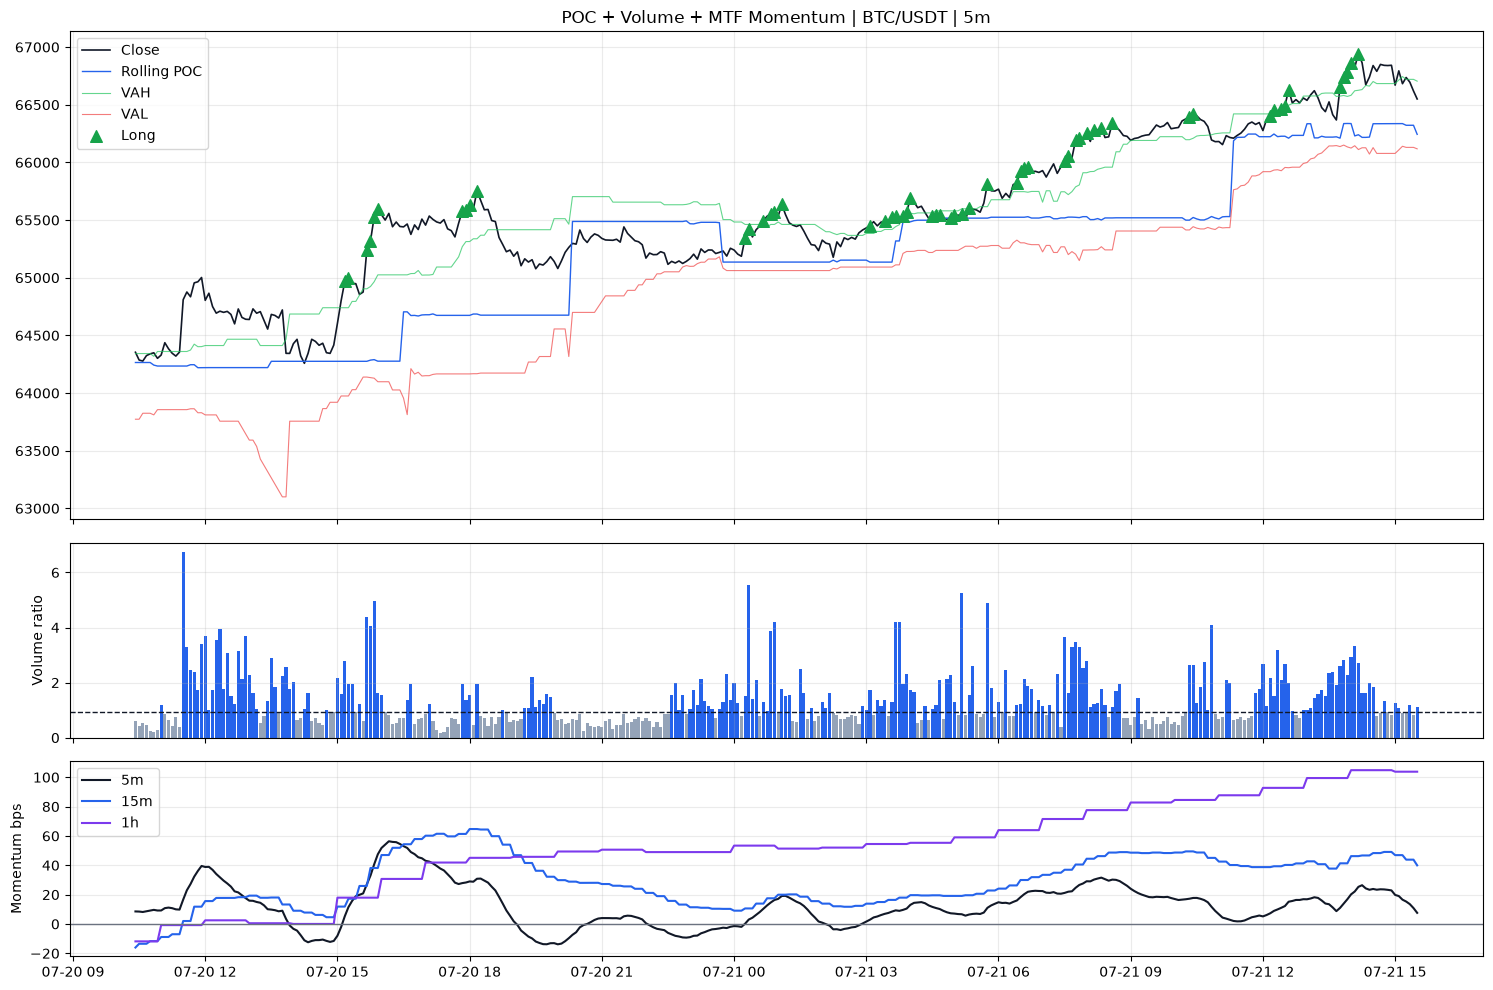

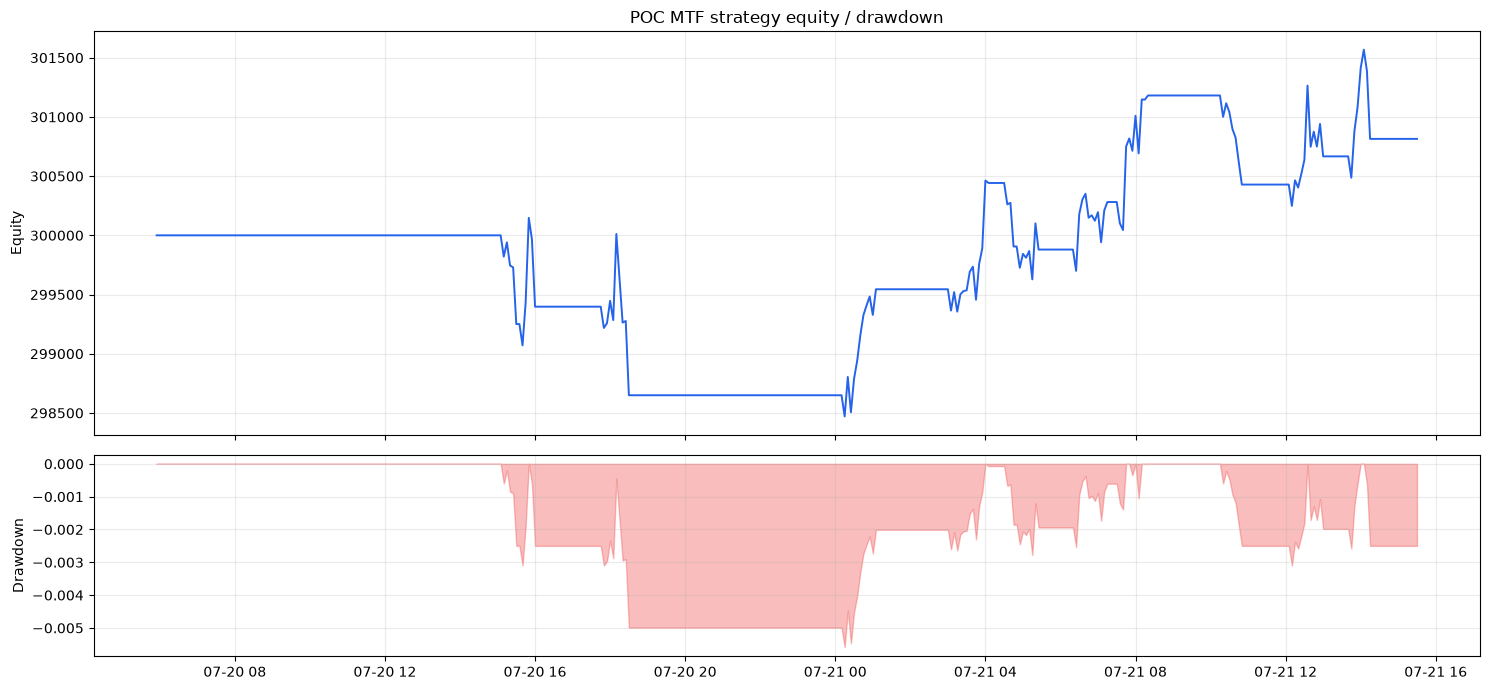

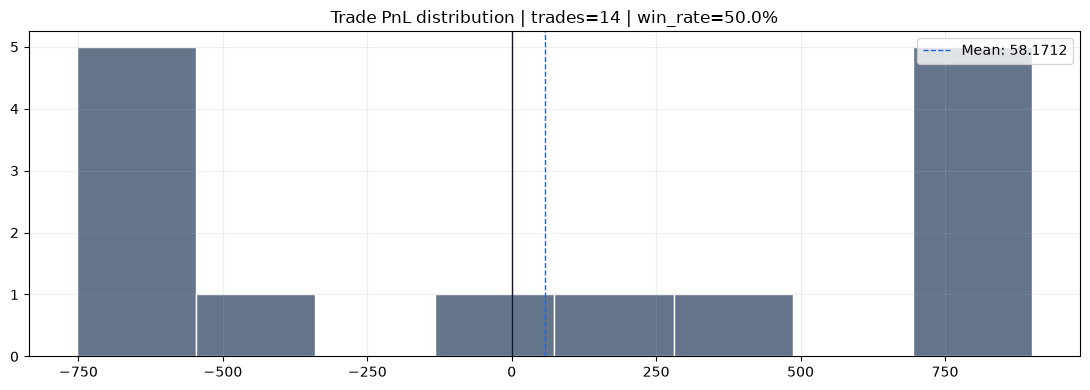

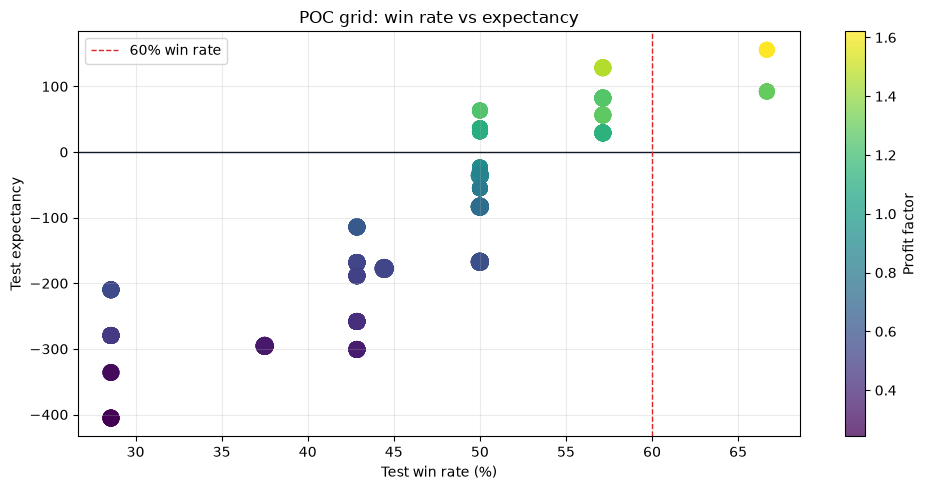

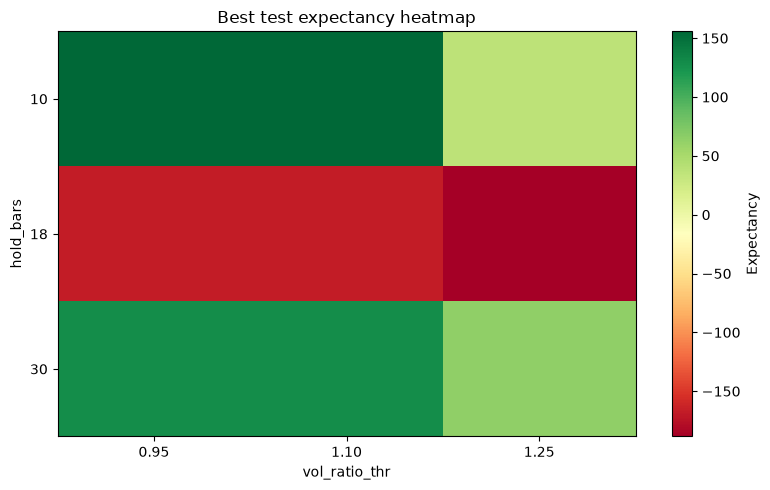

In [16]:
def plot_poc_strategy(f, pf, params=None, lookback=350):
    params = params or best_v2_params
    plot_f = f.tail(lookback).copy()
    e, x, se, sx = build_poc_mtf_signals(plot_f, params)

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(15, 10), sharex=True,
        gridspec_kw={"height_ratios": [3, 1.2, 1.2]},
    )
    ax1.plot(plot_f.index, plot_f["close"], color="#111827", linewidth=1.2, label="Close")
    ax1.plot(plot_f.index, plot_f["poc"], color="#2563eb", linewidth=1.0, label="Rolling POC")
    ax1.plot(plot_f.index, plot_f["vah"], color="#22c55e", linewidth=0.8, alpha=0.7, label="VAH")
    ax1.plot(plot_f.index, plot_f["val"], color="#ef4444", linewidth=0.8, alpha=0.7, label="VAL")

    long_idx = plot_f.index[e.reindex(plot_f.index).fillna(False)]
    short_idx = plot_f.index[se.reindex(plot_f.index).fillna(False)]
    if len(long_idx):
        ax1.scatter(long_idx, plot_f.loc[long_idx, "close"], marker="^", s=70, color="#16a34a", label="Long", zorder=4)
    if len(short_idx):
        ax1.scatter(short_idx, plot_f.loc[short_idx, "close"], marker="v", s=70, color="#dc2626", label="Short", zorder=4)
    ax1.set_title(f"POC + Volume + MTF Momentum | {CCXT_SYMBOL} | {CCXT_TIMEFRAME}")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best")

    ax2.bar(plot_f.index, plot_f["volume_ratio"], color=np.where(plot_f["volume_ratio"] >= params.get("vol_ratio_thr", 1.12), "#2563eb", "#94a3b8"), width=0.003)
    ax2.axhline(params.get("vol_ratio_thr", 1.12), color="#111827", linestyle="--", linewidth=1)
    ax2.set_ylabel("Volume ratio")
    ax2.grid(True, alpha=0.25)

    ax3.plot(plot_f.index, plot_f["mom_5m_bps"], label="5m", color="#111827")
    ax3.plot(plot_f.index, plot_f["mom_15m_bps"], label="15m", color="#2563eb")
    ax3.plot(plot_f.index, plot_f["mom_1h_bps"], label="1h", color="#7c3aed")
    ax3.axhline(0, color="#6b7280", linewidth=1)
    ax3.set_ylabel("Momentum bps")
    ax3.legend(loc="best")
    ax3.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    plot_equity_drawdown(pf, title="POC MTF strategy equity / drawdown")
    plot_trade_distribution(pf)


def plot_poc_grid_results(grid):
    if grid is None or grid.empty:
        print("POC grid plot icin sonuc yok.")
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    size = np.clip(grid["test_trades"], 1, None) * 18
    color = grid["test_profit_factor"].replace(np.inf, np.nan).clip(upper=5)
    sc = ax.scatter(grid["test_win_rate_pct"], grid["test_expectancy"], s=size, c=color, cmap="viridis", alpha=0.75)
    ax.axhline(0, color="#111827", linewidth=1)
    ax.axvline(60, color="#dc2626", linestyle="--", linewidth=1, label="60% win rate")
    ax.set_xlabel("Test win rate (%)")
    ax.set_ylabel("Test expectancy")
    ax.set_title("POC grid: win rate vs expectancy")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    fig.colorbar(sc, ax=ax, label="Profit factor")
    plt.tight_layout()
    plt.show()

    pivot = grid.pivot_table(index="hold_bars", columns="vol_ratio_thr", values="test_expectancy", aggfunc="max")
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.2f}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(int(x)) for x in pivot.index])
    ax.set_xlabel("vol_ratio_thr")
    ax.set_ylabel("hold_bars")
    ax.set_title("Best test expectancy heatmap")
    fig.colorbar(im, ax=ax, label="Expectancy")
    plt.tight_layout()
    plt.show()


plot_poc_strategy(poc_features_bt, pf_poc_best, best_v2_params, lookback=350)
plot_poc_grid_results(poc_grid_results)


## Strategy V2 Okuma Notu

Bu POC/volume/MTF sistemi 5m OHLCV ile calisir. Bu yuzden market maker'i birebir takip ettigini iddia etmez; POC etrafindaki hacim kabul/red davranisini momentum filtresiyle trade eder.

Secim mantigi:

1. Once train ve test tarafinda expectancy pozitif, profit factor 1 ustu olan robust adaylar aranir.
2. Robust aday varsa `best_v2_params` oradan secilir.
3. 60%+ test win-rate adaylari ayrica gosterilir; train tarafi negatifse bunlar daha spekulatif kabul edilir.

Iyi aday icin minimum sartlar:

- Test trade sayisi cok dusuk olmamali.
- Train ve test expectancy pozitif olmali.
- Profit factor 1 ustunde olmali.
- Win rate 60% civari veya ustu ise average loss, average win'i ezmemeli.
- Full-sample sonucu guzel olsa bile train/test ayriminda da ayakta kalmali.


## Codex Actual Backtest Summary

Bu notebook artik 3x kaldirac ve ana sermayenin islem basina maksimum `%1` risk kuraliyla calisir.

Varsayilan strateji modu:

- `V2_DIRECTION = "long_only"`
- Short taraf 5m OHLCV proxy ile fazla gurultu ekledigi icin default disi birakildi.

Risk uygulamasi:

- Vectorbt simülasyon sermayesi: `INIT_CASH * LEVERAGE`
- Raporlanan return/drawdown: tekrar ana sermaye olan `INIT_CASH` uzerinden hesaplanir.
- `LEVERAGE = 3`
- `MAX_PRINCIPAL_RISK_PCT = 1%`
- Stop cap: `1% / 3x`, fee/slippage buffer'i dusulerek hesaplanir.
- Mevcut fee/slippage ile risk-cap stop ust siniri yaklasik `0.213%`.
- Secilen long-only grid adayinda configured/effective `sl_stop = 0.15%`, tahmini stop riski maliyet buffer'i dahil `0.81%`.

Gercek CCXT 500 mum kosusu:

- Pair: `BTC/USDT`
- Frame: `5m`
- Data source: `ccxt.binance().fetch_ohlcv`
- Rows: `500`, POC warmup sonrasi `404`
- Grid combinations: `432`
- Robust train+test pozitif aday sayisi: `24`
- 60%+ test win rate ve pozitif test expectancy aday sayisi: `24`

Secilen long-only 3x/risk-cap aday:

- `vol_ratio_thr`: `0.95`
- `volume_z_thr`: `0.10`
- `poc_band_bps`: `18`
- `hold_bars`: `10`
- `sl_stop`: `0.0015`
- `tp_stop`: `0.004`
- `momentum_5m_thr`: `0`

Full-sample 500 mum sonucu:

- Trades: `13`
- Win rate: `46.15%`
- Total return on principal: `+0.55%`
- Max drawdown on principal: `-1.67%`
- Profit factor: `1.13`
- Expectancy: `+42.46`
- Avg win / avg loss: `787.72 / -596.34`

Not:

- Bu hala POC; production alpha degil.
- Daha uzun OHLCV cache, walk-forward split, sembol sepeti ve fee/slippage hassasiyet testi gerekli.


## Strategy V3: Weekly Bias + Liquidity Sweep + Structure Reclaim

Bu blok V2'yi bozmadan ayri bir price-action katmani dener:

- Haftalik yon filtresi once gelir.
- Dusus sonrasi ana valley anchor'i bulunur.
- Valley altina fitil atip close'u tekrar valley ustunde kalan sweep aranir.
- Valley update yani kapanisla yeni dip alinmayan bolgede minor peak reclaim beklenir.
- Rolling/anchored POC ve anchored VWAP giris teyidi ve cikis zayiflamasi icin kullanilir.
- Risk motoru 3x leverage ile ana paranin trade basina en fazla %1 riske girmesini hedefler.

In [17]:
# ==========
# Strategy V3 settings
# ==========

if "LEVERAGE" not in globals():
    LEVERAGE = 3.0
if "MAX_PRINCIPAL_RISK_PCT" not in globals():
    MAX_PRINCIPAL_RISK_PCT = 0.01
if "INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP" not in globals():
    INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP = True
if "MIN_EFFECTIVE_SL_STOP" not in globals():
    MIN_EFFECTIVE_SL_STOP = 0.0005

V3_DIRECTION = "long_only"
V3_SIGNAL_LIMIT = 1000
V3_WEEKLY_LIMIT = 160
V3_USE_CLOSED_WEEKLY = True
V3_REQUIRE_WEEKLY_BIAS = True
V3_RUN_NO_WEEKLY_DIAGNOSTIC = True

V3_BASE_PARAMS = {
    # Context
    "weekly_fast": 8,
    "weekly_slow": 21,
    "weekly_slope_min_bps": -20.0,
    "require_weekly_bias": V3_REQUIRE_WEEKLY_BIAS,

    # POC / momentum
    "poc_window": 96,
    "poc_bins": 36,
    "value_area_pct": 0.70,
    "mtf_fast": 12,
    "mtf_slow": 36,

    # Main peak -> valley -> sweep structure
    "swing_left": 3,
    "swing_right": 3,
    "major_lookback": 144,
    "min_drop_from_peak_bps": 80.0,
    "min_bars_after_valley": 3,
    "max_bars_after_valley": 240,
    "max_close_break_bps": 3.0,
    "sweep_bps": 3.0,
    "reclaim_close_bps": 0.0,
    "wick_ratio_thr": 0.35,
    "close_pos_thr": 0.50,
    "sweep_vol_ratio_thr": 0.90,
    "sweep_volume_z_thr": -0.30,

    # Minor peak reclaim / push
    "reclaim_buffer_bps": 2.0,
    "min_peak_updates": 0,
    "entry_vol_ratio_thr": 0.85,
    "entry_mom_5m_thr": -3.0,
    "entry_mom_15m_thr": -3.0,
    "trend_push_lookback": 12,
    "trend_push_min_bps": -8.0,
    "entry_poc_band_bps": 35.0,
    "cooldown_bars": 10,

    # Exit / risk
    "hold_bars": 24,
    "exit_anchor_vwap_bps": 12.0,
    "exit_poc_bps": 18.0,
    "sl_stop": 0.0060,
    "tp_stop": 0.0060,
    "leverage": LEVERAGE,
    "max_principal_risk_pct": MAX_PRINCIPAL_RISK_PCT,
    "include_costs_in_risk_cap": INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP,
}

print("V3_BASE_PARAMS", V3_BASE_PARAMS)
print(
    "Risk rule:",
    f"{LEVERAGE:.1f}x leverage, max principal risk {MAX_PRINCIPAL_RISK_PCT:.2%} per trade"
)
print("V3_DIRECTION", V3_DIRECTION)
print("V3_RUN_NO_WEEKLY_DIAGNOSTIC", V3_RUN_NO_WEEKLY_DIAGNOSTIC)

V3_BASE_PARAMS {'weekly_fast': 8, 'weekly_slow': 21, 'weekly_slope_min_bps': -20.0, 'require_weekly_bias': True, 'poc_window': 96, 'poc_bins': 36, 'value_area_pct': 0.7, 'mtf_fast': 12, 'mtf_slow': 36, 'swing_left': 3, 'swing_right': 3, 'major_lookback': 144, 'min_drop_from_peak_bps': 80.0, 'min_bars_after_valley': 3, 'max_bars_after_valley': 240, 'max_close_break_bps': 3.0, 'sweep_bps': 3.0, 'reclaim_close_bps': 0.0, 'wick_ratio_thr': 0.35, 'close_pos_thr': 0.5, 'sweep_vol_ratio_thr': 0.9, 'sweep_volume_z_thr': -0.3, 'reclaim_buffer_bps': 2.0, 'min_peak_updates': 0, 'entry_vol_ratio_thr': 0.85, 'entry_mom_5m_thr': -3.0, 'entry_mom_15m_thr': -3.0, 'trend_push_lookback': 12, 'trend_push_min_bps': -8.0, 'entry_poc_band_bps': 35.0, 'cooldown_bars': 10, 'hold_bars': 24, 'exit_anchor_vwap_bps': 12.0, 'exit_poc_bps': 18.0, 'sl_stop': 0.006, 'tp_stop': 0.006, 'leverage': 3.0, 'max_principal_risk_pct': 0.01, 'include_costs_in_risk_cap': True}
Risk rule: 3.0x leverage, max principal risk 1.00% 

In [18]:
def v3_make_exchange():
    if "make_ccxt_exchange" in globals():
        return make_ccxt_exchange()
    if ccxt is None:
        raise ImportError("ccxt kurulu degil.")
    klass = getattr(ccxt, CCXT_EXCHANGE_ID)
    ex = klass({
        "enableRateLimit": True,
        "timeout": 30000,
        "options": {"defaultType": CCXT_DEFAULT_TYPE, "adjustForTimeDifference": True},
    })
    try:
        ex.session.trust_env = False
    except Exception:
        pass
    return ex


def v3_fetch_ohlcv(symbol=CCXT_SYMBOL, timeframe=CCXT_TIMEFRAME, limit=V3_SIGNAL_LIMIT, exchange=None):
    errors = []

    def _raw_to_frame(raw):
        df = pd.DataFrame(raw, columns=["open_time", "open", "high", "low", "close", "volume"])
        df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
        for col in ["open", "high", "low", "close", "volume"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        return df.set_index("open_time").sort_index()

    candidates = []
    if exchange is not None:
        candidates.append(("provided_exchange", exchange))
    try:
        candidates.append(("fresh_make_ccxt_exchange", v3_make_exchange()))
    except Exception as exc:
        errors.append(f"fresh_make_ccxt_exchange: {type(exc).__name__}: {str(exc)[:220]}")
    if ccxt is not None:
        candidates.append(("plain_timeout_spot", ccxt.binance({
            "enableRateLimit": True,
            "timeout": 30000,
            "options": {"defaultType": "spot"},
        })))
        candidates.append(("plain_timeout", ccxt.binance({
            "enableRateLimit": True,
            "timeout": 30000,
        })))

    for label, ex in candidates:
        try:
            if "load_ccxt_ohlcv" in globals():
                return load_ccxt_ohlcv(symbol=symbol, timeframe=timeframe, limit=limit, exchange=ex)
            raw = ex.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
            return _raw_to_frame(raw)
        except Exception as exc:
            errors.append(f"{label}: {type(exc).__name__}: {str(exc)[:260]}")
            time.sleep(0.8)

    if ccxt is None:
        raise ImportError("ccxt kurulu degil.")
    raise RuntimeError("V3 CCXT OHLCV tum denemelerde basarisiz:\n" + "\n".join(errors))


def v3_load_data():
    ex = None
    signal = pd.DataFrame()
    weekly = pd.DataFrame()

    try:
        ex = v3_make_exchange()
    except Exception as exc:
        print("V3 exchange olusturulamadi:", type(exc).__name__, str(exc)[:500])

    try:
        signal = v3_fetch_ohlcv(CCXT_SYMBOL, CCXT_TIMEFRAME, V3_SIGNAL_LIMIT, exchange=ex)
        print("V3 5m OHLCV ok:", signal.shape, signal.index.min(), signal.index.max())
    except Exception as exc:
        print("V3 5m OHLCV cekilemedi, klines_raw fallback deneniyor:", type(exc).__name__, str(exc)[:700])
        if "klines_raw" in globals() and not klines_raw.empty:
            signal = klines_raw.copy()
            print("Fallback klines_raw:", signal.shape, signal.index.min(), signal.index.max())

    try:
        weekly = v3_fetch_ohlcv(CCXT_SYMBOL, "1w", V3_WEEKLY_LIMIT, exchange=ex)
        print("V3 weekly OHLCV ok:", weekly.shape, weekly.index.min(), weekly.index.max())
    except Exception as exc:
        print("V3 weekly OHLCV cekilemedi; 5m resample fallback deneniyor:", type(exc).__name__, str(exc)[:700])
        if not signal.empty:
            base = _ohlcv_for_strategy(signal) if "_ohlcv_for_strategy" in globals() else signal.copy()
            weekly = base.resample("1W").agg({
                "open": "first",
                "high": "max",
                "low": "min",
                "close": "last",
                "volume": "sum",
            }).dropna()
            print("Weekly fallback:", weekly.shape, weekly.index.min() if not weekly.empty else None, weekly.index.max() if not weekly.empty else None)

    return signal, weekly


v3_klines_raw, v3_weekly_raw = v3_load_data()
display(v3_klines_raw.tail() if not v3_klines_raw.empty else v3_klines_raw)
display(v3_weekly_raw.tail() if not v3_weekly_raw.empty else v3_weekly_raw)

V3 5m OHLCV ok: (1000, 10) 2026-07-18 04:20:00+00:00 2026-07-21 15:35:00+00:00
V3 weekly OHLCV cekilemedi; 5m resample fallback deneniyor: RuntimeError V3 CCXT OHLCV tum denemelerde basarisiz:
provided_exchange: NetworkError: binance GET https://api.binance.com/api/v3/exchangeInfo
fresh_make_ccxt_exchange: NetworkError: binance GET https://api.binance.com/api/v3/exchangeInfo
plain_timeout_spot: NetworkError: binance GET https://dapi.binance.com/dapi/v1/exchangeInfo
plain_timeout: NetworkError: binance GET https://api.binance.com/api/v3/exchangeInfo
Weekly fallback: (2, 5) 2026-07-19 00:00:00+00:00 2026-07-26 00:00:00+00:00


,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume
open_time,,,,,,,,,,
2026-07-21 15:15:00+00:00,66682.60,66736.55,66678.00,66736.54,74.34092,2026-07-21 15:20:00+00:00,4.961256e+06,NaN,NaN,NaN
2026-07-21 15:20:00+00:00,66736.55,66746.68,66669.39,66695.99,101.06265,2026-07-21 15:25:00+00:00,6.740473e+06,NaN,NaN,NaN
2026-07-21 15:25:00+00:00,66696.00,66696.00,66619.33,66619.33,69.31069,2026-07-21 15:30:00+00:00,4.617432e+06,NaN,NaN,NaN
2026-07-21 15:30:00+00:00,66619.33,66619.34,66541.55,66571.99,108.67822,2026-07-21 15:35:00+00:00,7.234925e+06,NaN,NaN,NaN
2026-07-21 15:35:00+00:00,66571.99,66572.00,66571.99,66571.99,0.88237,2026-07-21 15:40:00+00:00,5.874113e+04,NaN,NaN,NaN


,open,high,low,close,volume
open_time,,,,,
2026-07-19 00:00:00+00:00,64003.01,64967.25,63887.73,64722.54,14903.87883
2026-07-26 00:00:00+00:00,64722.55,66956.15,63100.00,66571.99,35301.58460


In [19]:
def v3_ohlcv_frame(df):
    if "_ohlcv_for_strategy" in globals():
        return _ohlcv_for_strategy(df)
    f = df.copy().rename(columns={c: c.lower() for c in df.columns})
    if "open_time" in f.columns and not isinstance(f.index, pd.DatetimeIndex):
        f["open_time"] = pd.to_datetime(f["open_time"], utc=True)
        f = f.set_index("open_time")
    required = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in f.columns]
    if missing:
        raise ValueError(f"OHLCV kolonlari eksik: {missing}")
    for col in required:
        f[col] = pd.to_numeric(f[col], errors="coerce")
    return f[required].dropna().sort_index()


def v3_rolling_zscore(s, window, min_periods=None):
    if "rolling_zscore" in globals():
        return rolling_zscore(s, window, min_periods)
    min_periods = min_periods or max(5, window // 3)
    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


def v3_rsi(close, window=14):
    if "_rsi" in globals():
        return _rsi(close, window)
    delta = close.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    rs = up.ewm(alpha=1 / window, adjust=False).mean() / down.ewm(alpha=1 / window, adjust=False).mean().replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def v3_add_poc_and_mtf(df, params=None):
    params = params or V3_BASE_PARAMS
    f = v3_ohlcv_frame(df)
    if "add_rolling_poc" in globals():
        f = add_rolling_poc(
            f,
            window=params.get("poc_window", 96),
            bins=params.get("poc_bins", 36),
            value_area_pct=params.get("value_area_pct", 0.70),
        )
    else:
        raise RuntimeError("add_rolling_poc bulunamadi; ustteki V2 helper hucrelerini calistir.")

    if "add_mtf_momentum" in globals():
        f = add_mtf_momentum(
            f,
            fast=params.get("mtf_fast", 12),
            slow=params.get("mtf_slow", 36),
        )
    else:
        raise RuntimeError("add_mtf_momentum bulunamadi; ustteki V2 helper hucrelerini calistir.")

    f["typical_price"] = (f["high"] + f["low"] + f["close"]) / 3
    f["ret_1"] = f["close"].pct_change()
    f["atr_bps"] = ((f["high"] - f["low"]).rolling(20, min_periods=5).mean() / f["close"]) * 10_000
    f["volume_ratio"] = f["volume"] / f["volume"].rolling(48, min_periods=12).median().replace(0, np.nan)
    f["volume_z"] = v3_rolling_zscore(f["volume"], 48)
    return f.replace([np.inf, -np.inf], np.nan)


def v3_add_weekly_bias(f, weekly, params=None, use_closed_weekly=V3_USE_CLOSED_WEEKLY):
    params = params or V3_BASE_PARAMS
    out = f.copy()

    if weekly is None or weekly.empty:
        out["weekly_up"] = False if params.get("require_weekly_bias", True) else True
        out["weekly_close"] = np.nan
        out["weekly_ema_fast"] = np.nan
        out["weekly_ema_slow"] = np.nan
        out["weekly_slope_bps"] = np.nan
        return out

    w = v3_ohlcv_frame(weekly)
    fast = int(params.get("weekly_fast", 8))
    slow = int(params.get("weekly_slow", 21))
    w["weekly_close"] = w["close"]
    w["weekly_ema_fast"] = w["close"].ewm(span=fast, adjust=False).mean()
    w["weekly_ema_slow"] = w["close"].ewm(span=slow, adjust=False).mean()
    w["weekly_slope_bps"] = w["weekly_ema_fast"].pct_change(3) * 10_000
    w["weekly_up"] = (
        (w["weekly_close"] > w["weekly_ema_fast"])
        & (w["weekly_ema_fast"] >= w["weekly_ema_slow"])
        & (w["weekly_slope_bps"] >= float(params.get("weekly_slope_min_bps", -20.0)))
    )
    context_cols = ["weekly_close", "weekly_ema_fast", "weekly_ema_slow", "weekly_slope_bps", "weekly_up"]
    context = w[context_cols].copy()
    if use_closed_weekly:
        context = context.shift(1)
    context = context.reindex(out.index, method="ffill")
    for col in context_cols:
        out[col] = context[col]
    if not params.get("require_weekly_bias", True):
        out["weekly_up"] = out["weekly_up"].fillna(True)
    return out


def v3_confirmed_swings(f, left=3, right=3):
    window = int(left) + int(right) + 1
    highs = f["high"]
    lows = f["low"]
    raw_high = highs.eq(highs.rolling(window, center=True, min_periods=window).max())
    raw_low = lows.eq(lows.rolling(window, center=True, min_periods=window).min())
    swing_high = raw_high.shift(int(right)).fillna(False).astype(bool)
    swing_low = raw_low.shift(int(right)).fillna(False).astype(bool)
    swing_high_price = highs.shift(int(right)).where(swing_high)
    swing_low_price = lows.shift(int(right)).where(swing_low)
    return swing_high, swing_low, swing_high_price, swing_low_price


def v3_add_anchored_poc(f, valley_id, max_lookback=240, bins=36):
    anchor_poc = np.full(len(f), np.nan)
    high = f["high"].to_numpy(dtype=float)
    low = f["low"].to_numpy(dtype=float)
    close = f["close"].to_numpy(dtype=float)
    volume = f["volume"].to_numpy(dtype=float)
    ids = pd.Series(valley_id, index=f.index)

    for gid in sorted(x for x in ids.dropna().unique() if x > 0):
        positions = np.flatnonzero(ids.to_numpy() == gid)
        if len(positions) < 3:
            continue
        first = int(positions[0])
        for pos in positions:
            start = max(first, int(pos) - int(max_lookback) + 1)
            poc, _, _ = _profile_from_window(
                high[start:int(pos) + 1],
                low[start:int(pos) + 1],
                close[start:int(pos) + 1],
                volume[start:int(pos) + 1],
                bins=int(bins),
                value_area_pct=0.70,
            )
            anchor_poc[int(pos)] = poc

    return pd.Series(anchor_poc, index=f.index, name="anchor_poc")


def v3_add_structure_features(f, params=None):
    params = params or V3_BASE_PARAMS
    out = f.copy()
    left = int(params.get("swing_left", 3))
    right = int(params.get("swing_right", 3))
    swing_high, swing_low, swing_high_price, swing_low_price = v3_confirmed_swings(out, left=left, right=right)

    out["swing_high"] = swing_high
    out["swing_low"] = swing_low
    out["swing_high_price"] = swing_high_price
    out["swing_low_price"] = swing_low_price

    major_lookback = int(params.get("major_lookback", 144))
    prior_peak = out["high"].rolling(major_lookback, min_periods=max(12, major_lookback // 5)).max().shift(1)
    drop_from_peak_bps = (prior_peak / swing_low_price - 1) * 10_000
    major_valley_event = (
        swing_low
        & (drop_from_peak_bps >= float(params.get("min_drop_from_peak_bps", 80.0)))
    ).fillna(False)

    out["major_valley_event"] = major_valley_event
    out["anchor_peak"] = prior_peak.where(major_valley_event).ffill()
    out["anchor_valley"] = swing_low_price.where(major_valley_event).ffill()
    out["valley_id"] = major_valley_event.cumsum().astype(int)
    out.loc[out["valley_id"] == 0, ["anchor_peak", "anchor_valley"]] = np.nan

    valley_group = out["valley_id"]
    out["bars_since_valley"] = valley_group.groupby(valley_group).cumcount()
    out.loc[out["valley_id"] == 0, "bars_since_valley"] = np.nan

    close_floor = out["anchor_valley"] * (1 - float(params.get("max_close_break_bps", 3.0)) / 10_000)
    close_break_event = (out["valley_id"] > 0) & (out["close"] < close_floor)
    out["close_broken_since_valley"] = close_break_event.groupby(out["valley_id"]).cummax().astype(bool)
    out["no_close_break"] = ~out["close_broken_since_valley"]
    out.loc[out["valley_id"] == 0, "no_close_break"] = False

    rng = (out["high"] - out["low"]).replace(0, np.nan)
    out["lower_wick_ratio"] = ((out[["open", "close"]].min(axis=1) - out["low"]) / rng).clip(lower=0, upper=1)
    out["close_pos"] = ((out["close"] - out["low"]) / rng).clip(lower=0, upper=1)

    min_bars = int(params.get("min_bars_after_valley", 3))
    max_bars = int(params.get("max_bars_after_valley", 240))
    sweep_level = out["anchor_valley"] * (1 - float(params.get("sweep_bps", 3.0)) / 10_000)
    reclaim_close = out["anchor_valley"] * (1 + float(params.get("reclaim_close_bps", 0.0)) / 10_000)
    volume_sweep_ok = (
        (out["volume_ratio"] >= float(params.get("sweep_vol_ratio_thr", 0.90)))
        | (out["volume_z"] >= float(params.get("sweep_volume_z_thr", -0.30)))
    )
    out["sweep_event"] = (
        (out["valley_id"] > 0)
        & out["no_close_break"]
        & out["bars_since_valley"].between(min_bars, max_bars)
        & (out["low"] < sweep_level)
        & (out["close"] > reclaim_close)
        & (out["lower_wick_ratio"] >= float(params.get("wick_ratio_thr", 0.35)))
        & (out["close_pos"] >= float(params.get("close_pos_thr", 0.50)))
        & volume_sweep_ok
    ).fillna(False)
    out["sweep_seen"] = out["sweep_event"].groupby(out["valley_id"]).cummax().astype(bool)
    out.loc[out["valley_id"] == 0, "sweep_seen"] = False

    swing_high_after_valley = swing_high_price.where(out["valley_id"] > 0)
    out["minor_peak_level"] = swing_high_after_valley.groupby(out["valley_id"]).ffill()
    out["prev_minor_peak"] = out["minor_peak_level"].groupby(out["valley_id"]).shift(1)
    prev_minor_ffill = out["prev_minor_peak"].groupby(out["valley_id"]).ffill()
    peak_update_bps = float(params.get("reclaim_buffer_bps", 2.0))
    out["minor_peak_update_event"] = (
        swing_high_after_valley.notna()
        & prev_minor_ffill.notna()
        & (swing_high_after_valley > prev_minor_ffill * (1 + peak_update_bps / 10_000))
    )
    out["peak_update_count"] = out["minor_peak_update_event"].groupby(out["valley_id"]).cumsum()
    out.loc[out["valley_id"] == 0, "peak_update_count"] = 0

    out["peak_reclaim"] = (
        out["prev_minor_peak"].notna()
        & (out["close"] > out["prev_minor_peak"] * (1 + float(params.get("reclaim_buffer_bps", 2.0)) / 10_000))
    )

    typical_x_vol = out["typical_price"] * out["volume"]
    out["anchor_vwap"] = typical_x_vol.where(out["valley_id"] > 0).groupby(out["valley_id"]).cumsum() / (
        out["volume"].where(out["valley_id"] > 0).groupby(out["valley_id"]).cumsum().replace(0, np.nan)
    )
    out["anchor_poc"] = v3_add_anchored_poc(
        out,
        out["valley_id"],
        max_lookback=int(params.get("max_bars_after_valley", 240)),
        bins=int(params.get("poc_bins", 36)),
    )
    out["anchor_vwap_dist_bps"] = (out["close"] / out["anchor_vwap"] - 1) * 10_000
    out["anchor_poc_dist_bps"] = (out["close"] / out["anchor_poc"] - 1) * 10_000

    lookback = int(params.get("trend_push_lookback", 12))
    out["trend_push_bps"] = (out["close"] / out["close"].shift(lookback) - 1) * 10_000
    out["post_valley_higher_close"] = out["close"] > out["close"].groupby(out["valley_id"]).cummin().shift(1)
    return out.replace([np.inf, -np.inf], np.nan)


def build_v3_sweep_reclaim_features(klines, weekly=None, params=None):
    params = params or V3_BASE_PARAMS
    f = v3_add_poc_and_mtf(klines, params=params)
    f = v3_add_weekly_bias(f, weekly, params=params, use_closed_weekly=V3_USE_CLOSED_WEEKLY)
    f = v3_add_structure_features(f, params=params)
    return f.replace([np.inf, -np.inf], np.nan)


if v3_klines_raw.empty:
    raise RuntimeError("V3 icin 5m OHLCV yok. Once veri hucrelerini calistir.")

v3_features = build_v3_sweep_reclaim_features(v3_klines_raw, v3_weekly_raw, V3_BASE_PARAMS)
v3_features_bt = v3_features.dropna(subset=["close", "poc", "mom_15m_bps", "mom_1h_bps"]).copy()

print("v3_features", v3_features.shape)
print("v3_features_bt", v3_features_bt.shape)
print("weekly_up bars", int(v3_features_bt["weekly_up"].fillna(False).sum()) if "weekly_up" in v3_features_bt else 0)
print("major valleys", int(v3_features["major_valley_event"].sum()))
print("sweeps", int(v3_features["sweep_event"].sum()))
print("peak reclaims", int(v3_features["peak_reclaim"].sum()))

cols = [
    "close", "weekly_up", "anchor_peak", "anchor_valley", "sweep_event",
    "sweep_seen", "prev_minor_peak", "peak_reclaim", "anchor_vwap",
    "anchor_poc", "poc", "volume_ratio", "mom_5m_bps", "mom_15m_bps",
]
display(v3_features_bt[[c for c in cols if c in v3_features_bt.columns]].tail(20))

v3_features (1000, 62)
v3_features_bt (904, 62)
weekly_up bars 0
major valleys 29
sweeps 2
peak reclaims 102


,close,weekly_up,anchor_peak,anchor_valley,sweep_event,sweep_seen,prev_minor_peak,peak_reclaim,anchor_vwap,anchor_poc,poc,volume_ratio,mom_5m_bps,mom_15m_bps
open_time,,,,,,,,,,,,,,
2026-07-21 14:00:00+00:00,66859.19,NaN,65799.0,65176.2,False,False,66662.67,True,66123.668456,66230.787222,66336.912639,2.924144,20.181158,46.239767
2026-07-21 14:05:00+00:00,66823.79,NaN,65799.0,65176.2,False,False,66662.67,True,66141.451819,66334.486250,66229.787500,3.343945,22.126754,46.239767
2026-07-21 14:10:00+00:00,66944.40,NaN,65799.0,65176.2,False,False,66662.67,True,66156.968551,66334.486250,66239.985417,2.724227,25.305197,46.239767
2026-07-21 14:15:00+00:00,66864.01,NaN,65799.0,65176.2,False,False,66662.67,True,66165.812996,66334.486250,66217.136389,1.614678,26.432122,46.698863
2026-07-21 14:20:00+00:00,66673.32,NaN,65799.0,65176.2,False,False,66662.67,False,66172.852792,66334.486250,66217.136389,1.608266,24.257808,46.698863
2026-07-21 14:25:00+00:00,66740.00,NaN,65799.0,65176.2,False,False,66956.15,False,66180.860379,66334.486250,66219.556250,1.987450,23.314183,46.698863
2026-07-21 14:30:00+00:00,66840.00,NaN,65799.0,65176.2,False,False,66956.15,False,66190.157421,66334.486250,66335.318750,1.857634,23.861788,48.323208
2026-07-21 14:35:00+00:00,66789.99,NaN,65799.0,65176.2,False,False,66956.15,False,66193.680861,66334.486250,66335.370139,0.776123,23.352266,48.323208
2026-07-21 14:40:00+00:00,66849.77,NaN,65799.0,65176.2,False,False,66956.15,False,66197.317506,66334.486250,66335.370139,0.880561,23.644395,48.323208


In [20]:
def v3_signal_params(params):
    keys = {
        "require_weekly_bias", "entry_vol_ratio_thr", "entry_mom_5m_thr",
        "entry_mom_15m_thr", "trend_push_min_bps", "entry_poc_band_bps",
        "min_peak_updates", "cooldown_bars", "hold_bars",
        "exit_anchor_vwap_bps", "exit_poc_bps",
    }
    return {k: params[k] for k in keys if k in params}


def build_v3_sweep_reclaim_signals(f, params=None):
    params = params or V3_BASE_PARAMS
    require_weekly = bool(params.get("require_weekly_bias", True))
    weekly_ok = f["weekly_up"].fillna(False) if require_weekly else pd.Series(True, index=f.index)

    poc_band = float(params.get("entry_poc_band_bps", 35.0))
    poc_ok = (
        (f["close"] > f["poc"] * (1 - poc_band / 10_000))
        & (f["close"] > f["anchor_vwap"] * (1 - poc_band / 10_000))
    )
    if "anchor_poc" in f.columns:
        poc_ok = poc_ok & (f["close"] > f["anchor_poc"] * (1 - poc_band / 10_000))

    momentum_ok = (
        (f["mom_5m_bps"] >= float(params.get("entry_mom_5m_thr", -3.0)))
        & (f["mom_15m_bps"] >= float(params.get("entry_mom_15m_thr", -3.0)))
        & (f["trend_push_bps"] >= float(params.get("trend_push_min_bps", -8.0)))
    )
    volume_ok = f["volume_ratio"] >= float(params.get("entry_vol_ratio_thr", 0.85))
    structure_ok = (
        f["sweep_seen"].fillna(False)
        & f["no_close_break"].fillna(False)
        & f["peak_reclaim"].fillna(False)
        & (f["peak_update_count"].fillna(0) >= int(params.get("min_peak_updates", 0)))
    )

    raw_entries = (weekly_ok & structure_ok & poc_ok & momentum_ok & volume_ok).fillna(False)
    cooldown = int(params.get("cooldown_bars", 10))
    recent_entry = raw_entries.shift(1).rolling(cooldown, min_periods=1).max().fillna(False).astype(bool)
    entries = raw_entries & ~recent_entry

    hold_bars = int(params.get("hold_bars", 24))
    time_exit = entries.shift(hold_bars).fillna(False).astype(bool)
    anchor_vwap_exit = (
        (f["close"] < f["anchor_vwap"] * (1 - float(params.get("exit_anchor_vwap_bps", 12.0)) / 10_000))
        & (f["mom_5m_bps"] < 0)
    ).fillna(False)
    poc_exit = (
        (f["close"] < f["poc"] * (1 - float(params.get("exit_poc_bps", 18.0)) / 10_000))
        & (f["mom_5m_bps"] < 0)
    ).fillna(False)
    exits = (time_exit | anchor_vwap_exit | poc_exit).fillna(False)

    short_entries = pd.Series(False, index=f.index)
    short_exits = pd.Series(False, index=f.index)
    return entries.astype(bool), exits.astype(bool), short_entries, short_exits


def v3_max_sl_stop_for_principal_risk(params=None):
    params = params or V3_BASE_PARAMS
    leverage = float(params.get("leverage", LEVERAGE))
    max_principal_risk_pct = float(params.get("max_principal_risk_pct", MAX_PRINCIPAL_RISK_PCT))
    include_costs = bool(params.get("include_costs_in_risk_cap", INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP))
    max_stop = max_principal_risk_pct / leverage
    if include_costs:
        max_stop -= 2 * (float(FEE) + float(SLIPPAGE))
    if max_stop <= 0:
        raise ValueError("Fee/slippage buffer allowed risk'ten buyuk. Leverage'i veya cost varsayimini dusur.")
    return max(max_stop, MIN_EFFECTIVE_SL_STOP)


def v3_effective_sl_stop_for_params(params=None):
    params = params or V3_BASE_PARAMS
    configured = params.get("sl_stop", None)
    cap = v3_max_sl_stop_for_principal_risk(params)
    if configured is None:
        return cap
    return min(float(configured), cap)


def v3_principal_equity_from_pf(pf, leverage):
    sim_init_cash = INIT_CASH * float(leverage)
    value = pd.Series(pf.value())
    return INIT_CASH + (value - sim_init_cash)


def v3_trade_metrics(pf, params=None):
    params = params or V3_BASE_PARAMS
    leverage = float(params.get("leverage", LEVERAGE))
    effective_sl_stop = v3_effective_sl_stop_for_params(params)
    configured_sl_stop = params.get("sl_stop", np.nan)

    trades = pf.trades.records_readable
    principal_equity = v3_principal_equity_from_pf(pf, leverage)
    total_return = float(principal_equity.iloc[-1] / INIT_CASH - 1)
    dd = principal_equity / principal_equity.cummax() - 1
    max_dd = float(dd.min())
    out = {
        "trades": 0,
        "win_rate": np.nan,
        "total_return": total_return,
        "max_drawdown": max_dd,
        "profit_factor": np.nan,
        "expectancy": np.nan,
        "avg_win": np.nan,
        "avg_loss": np.nan,
        "payoff": np.nan,
    }
    if not trades.empty:
        pnl_col = "PnL" if "PnL" in trades.columns else "Return"
        pnl = pd.to_numeric(trades[pnl_col], errors="coerce").dropna()
        wins = pnl[pnl > 0]
        losses = pnl[pnl < 0]
        gross_win = wins.sum()
        gross_loss = losses.abs().sum()
        avg_win = wins.mean() if len(wins) else 0.0
        avg_loss = losses.mean() if len(losses) else 0.0
        out.update({
            "trades": int(len(pnl)),
            "win_rate": float((pnl > 0).mean()),
            "profit_factor": float(gross_win / gross_loss) if gross_loss > 0 else np.inf,
            "expectancy": float(pnl.mean()),
            "avg_win": float(avg_win),
            "avg_loss": float(avg_loss),
            "payoff": float(abs(avg_win / avg_loss)) if avg_loss < 0 else np.inf,
        })
    out.update({
        "leverage": float(leverage),
        "principal_init_cash": float(INIT_CASH),
        "sim_init_cash": float(INIT_CASH * leverage),
        "configured_sl_stop": float(configured_sl_stop) if pd.notna(configured_sl_stop) else np.nan,
        "effective_sl_stop": float(effective_sl_stop),
        "stop_risk_pct_before_costs": float(leverage * effective_sl_stop),
        "stop_risk_pct_with_cost_buffer": float(leverage * (effective_sl_stop + 2 * (FEE + SLIPPAGE))),
        "max_principal_risk_pct": float(params.get("max_principal_risk_pct", MAX_PRINCIPAL_RISK_PCT)),
        "sim_cash_total_return": float(pf.total_return()),
    })
    return out


def run_v3_sweep_reclaim_backtest(f, params=None, direction=V3_DIRECTION):
    params = params or V3_BASE_PARAMS
    entries, exits, short_entries, short_exits = build_v3_sweep_reclaim_signals(f, params)
    if direction != "long_only":
        print("V3 bu notebookta long-only tasarlandi; short tarafi bilincli kapali.")

    leverage = float(params.get("leverage", LEVERAGE))
    pf = vbt.Portfolio.from_signals(
        f["close"].astype(float),
        entries=entries,
        exits=exits,
        short_entries=short_entries,
        short_exits=short_exits,
        size=np.inf,
        init_cash=INIT_CASH * leverage,
        fees=FEE,
        slippage=SLIPPAGE,
        open=f["open"].astype(float),
        high=f["high"].astype(float),
        low=f["low"].astype(float),
        sl_stop=v3_effective_sl_stop_for_params(params),
        tp_stop=params.get("tp_stop", 0.0060),
        freq=CCXT_PANDAS_FREQ,
    )
    metrics = v3_trade_metrics(pf, params=params)
    metrics.update({
        "entries": int(entries.sum()),
        "short_entries": int(short_entries.sum()),
        "data_mode": "weekly_sweep_reclaim_poc_3x_risk_cap",
        "freq": CCXT_PANDAS_FREQ,
    })
    return pf, metrics


pf_v3_base, metrics_v3_base = run_v3_sweep_reclaim_backtest(v3_features_bt, V3_BASE_PARAMS, direction=V3_DIRECTION)
display(pd.Series(metrics_v3_base).to_frame("v3_base"))
display(pf_v3_base.trades.records_readable.tail(15))

v3_entries, v3_exits, _, _ = build_v3_sweep_reclaim_signals(v3_features_bt, V3_BASE_PARAMS)
print("V3 base entries:", int(v3_entries.sum()), "exits:", int(v3_exits.sum()))

if V3_RUN_NO_WEEKLY_DIAGNOSTIC:
    V3_NO_WEEKLY_PARAMS = {**V3_BASE_PARAMS, "require_weekly_bias": False}
    pf_v3_no_weekly, metrics_v3_no_weekly = run_v3_sweep_reclaim_backtest(
        v3_features_bt,
        V3_NO_WEEKLY_PARAMS,
        direction=V3_DIRECTION,
    )
    print("DIAGNOSTIC: Haftalik gate kapali; sadece sweep/reclaim yapisi olculuyor.")
    display(pd.Series(metrics_v3_no_weekly).to_frame("v3_no_weekly_diagnostic"))
    display(pf_v3_no_weekly.trades.records_readable.tail(15))

,v3_base
trades,0
win_rate,NaN
total_return,0.0
max_drawdown,0.0
profit_factor,NaN
expectancy,NaN
avg_win,NaN
avg_loss,NaN
payoff,NaN
leverage,3.0


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id


V3 base entries: 0 exits: 157
DIAGNOSTIC: Haftalik gate kapali; sadece sweep/reclaim yapisi olculuyor.


,v3_no_weekly_diagnostic
trades,1
win_rate,1.0
total_return,0.014984
max_drawdown,-0.009516
profit_factor,inf
expectancy,1498.356866
avg_win,1498.356866
avg_loss,0.0
payoff,inf
leverage,3.0


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
0,0,0,4.636675,2026-07-19 22:10:00+00:00,64675.662546,119.952019,2026-07-20 00:10:00+00:00,65050.70638,120.647602,1498.356866,0.004997,Long,Closed,0


In [21]:
from itertools import product

if "split_train_test" not in globals():
    def split_train_test(f, train_frac=0.7):
        n = len(f)
        cut = max(1, int(n * train_frac))
        return f.iloc[:cut].copy(), f.iloc[cut:].copy()


def evaluate_v3_grid(f, min_test_trades=1, direction=V3_DIRECTION, base_params=None):
    base_params = base_params or V3_BASE_PARAMS
    f = f.dropna(subset=["close", "poc", "mom_15m_bps", "mom_1h_bps", "anchor_vwap"]).copy()
    train, test = split_train_test(f, train_frac=0.70)
    rows = []

    for entry_vol, mom5, mom15, trend_min, hold_bars, sl_stop, tp_stop, exit_poc in product(
        [0.75, 0.95],
        [-3.0, 0.0],
        [-3.0, 0.0],
        [-8.0],
        [12, 24, 36],
        [0.0015, 0.0025, 0.0060],
        [0.0040, 0.0060, 0.0100],
        [12.0, 24.0],
    ):
        params = {
            **base_params,
            "entry_vol_ratio_thr": entry_vol,
            "entry_mom_5m_thr": mom5,
            "entry_mom_15m_thr": mom15,
            "trend_push_min_bps": trend_min,
            "hold_bars": hold_bars,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
            "exit_poc_bps": exit_poc,
            "leverage": LEVERAGE,
            "max_principal_risk_pct": MAX_PRINCIPAL_RISK_PCT,
            "include_costs_in_risk_cap": INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP,
        }
        try:
            _, mt = run_v3_sweep_reclaim_backtest(train, params, direction=direction)
            _, ms = run_v3_sweep_reclaim_backtest(test, params, direction=direction)
        except Exception:
            continue
        row = {k: params[k] for k in [
            "entry_vol_ratio_thr", "entry_mom_5m_thr", "entry_mom_15m_thr",
            "trend_push_min_bps", "hold_bars", "sl_stop", "tp_stop", "exit_poc_bps",
        ]}
        row.update({f"train_{k}": v for k, v in mt.items()})
        row.update({f"test_{k}": v for k, v in ms.items()})
        rows.append(row)

    res = pd.DataFrame(rows)
    if res.empty:
        return res
    res = res[res["test_trades"] >= min_test_trades].copy()
    if res.empty:
        return res
    res["test_win_rate_pct"] = res["test_win_rate"] * 100
    res["train_win_rate_pct"] = res["train_win_rate"] * 100
    res["pf_capped"] = res["test_profit_factor"].replace(np.inf, 10).fillna(0).clip(upper=10)
    res["score"] = (
        2.0 * res["test_expectancy"].fillna(-np.inf).rank(pct=True)
        + 1.5 * res["pf_capped"].rank(pct=True)
        + 1.0 * res["test_total_return"].fillna(-np.inf).rank(pct=True)
        + 0.8 * res["test_win_rate"].fillna(0).rank(pct=True)
        - 1.2 * res["test_max_drawdown"].abs().fillna(1).rank(pct=True)
    )
    return res.sort_values(
        ["score", "test_expectancy", "test_profit_factor", "test_win_rate"],
        ascending=False,
    )


def evaluate_v3_full_grid(f, min_trades=1, direction=V3_DIRECTION, base_params=None):
    base_params = base_params or V3_BASE_PARAMS
    f = f.dropna(subset=["close", "poc", "mom_15m_bps", "mom_1h_bps", "anchor_vwap"]).copy()
    rows = []

    for entry_vol, mom5, mom15, trend_min, hold_bars, sl_stop, tp_stop, exit_poc in product(
        [0.75, 0.95],
        [-3.0, 0.0],
        [-3.0, 0.0],
        [-8.0],
        [12, 24, 36],
        [0.0015, 0.0025, 0.0060],
        [0.0040, 0.0060, 0.0100],
        [12.0, 24.0],
    ):
        params = {
            **base_params,
            "entry_vol_ratio_thr": entry_vol,
            "entry_mom_5m_thr": mom5,
            "entry_mom_15m_thr": mom15,
            "trend_push_min_bps": trend_min,
            "hold_bars": hold_bars,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
            "exit_poc_bps": exit_poc,
            "leverage": LEVERAGE,
            "max_principal_risk_pct": MAX_PRINCIPAL_RISK_PCT,
            "include_costs_in_risk_cap": INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP,
        }
        try:
            _, m = run_v3_sweep_reclaim_backtest(f, params, direction=direction)
        except Exception:
            continue
        row = {k: params[k] for k in [
            "entry_vol_ratio_thr", "entry_mom_5m_thr", "entry_mom_15m_thr",
            "trend_push_min_bps", "hold_bars", "sl_stop", "tp_stop", "exit_poc_bps",
        ]}
        row.update({f"full_{k}": v for k, v in m.items()})
        # Compatibility with the selector below. This fallback is explicitly diagnostic,
        # not a replacement for walk-forward.
        row.update({f"train_{k}": v for k, v in m.items()})
        row.update({f"test_{k}": v for k, v in m.items()})
        rows.append(row)

    res = pd.DataFrame(rows)
    if res.empty:
        return res
    res = res[res["full_trades"] >= min_trades].copy()
    if res.empty:
        return res
    res["test_win_rate_pct"] = res["test_win_rate"] * 100
    res["train_win_rate_pct"] = res["train_win_rate"] * 100
    res["pf_capped"] = res["test_profit_factor"].replace(np.inf, 10).fillna(0).clip(upper=10)
    res["score"] = (
        2.0 * res["test_expectancy"].fillna(-np.inf).rank(pct=True)
        + 1.5 * res["pf_capped"].rank(pct=True)
        + 1.0 * res["test_total_return"].fillna(-np.inf).rank(pct=True)
        + 0.8 * res["test_win_rate"].fillna(0).rank(pct=True)
        - 1.2 * res["test_max_drawdown"].abs().fillna(1).rank(pct=True)
    )
    return res.sort_values(
        ["score", "test_expectancy", "test_profit_factor", "test_win_rate"],
        ascending=False,
    )


def v3_grid_view(grid, n=25):
    if grid is None or grid.empty:
        return grid
    cols = [
        "entry_vol_ratio_thr", "entry_mom_5m_thr", "entry_mom_15m_thr",
        "trend_push_min_bps", "hold_bars", "sl_stop", "tp_stop",
        "exit_poc_bps", "test_trades", "test_win_rate",
        "test_expectancy", "test_profit_factor", "test_total_return",
        "test_max_drawdown", "full_trades", "full_win_rate",
        "full_expectancy", "full_total_return", "selection_label",
    ]
    return grid[[c for c in cols if c in grid.columns]].head(n)


v3_grid_results = evaluate_v3_grid(v3_features_bt, min_test_trades=1, direction=V3_DIRECTION, base_params=V3_BASE_PARAMS)
display(v3_grid_view(v3_grid_results, 25))

if v3_grid_results.empty and V3_RUN_NO_WEEKLY_DIAGNOSTIC:
    print("Strict weekly grid trade bulamadi; no-weekly diagnostic grid calisiyor.")
    V3_NO_WEEKLY_GRID_PARAMS = {**V3_BASE_PARAMS, "require_weekly_bias": False}
    v3_grid_results_no_weekly = evaluate_v3_grid(
        v3_features_bt,
        min_test_trades=1,
        direction=V3_DIRECTION,
        base_params=V3_NO_WEEKLY_GRID_PARAMS,
    )
    display(v3_grid_view(v3_grid_results_no_weekly, 25))
    if v3_grid_results_no_weekly.empty:
        print("No-weekly train/test grid de bos; full-sample diagnostic grid calisiyor.")
        v3_full_grid_results = evaluate_v3_full_grid(
            v3_features_bt,
            min_trades=1,
            direction=V3_DIRECTION,
            base_params=V3_NO_WEEKLY_GRID_PARAMS,
        )
        if not v3_full_grid_results.empty:
            v3_full_grid_results["selection_label"] = "no_weekly_full_sample_diagnostic"
        display(v3_grid_view(v3_full_grid_results, 25))
        v3_selection_grid = v3_full_grid_results
        v3_selection_label = "no_weekly_full_sample_diagnostic"
    else:
        v3_full_grid_results = pd.DataFrame()
        v3_selection_grid = v3_grid_results_no_weekly
        v3_selection_label = "no_weekly_diagnostic"
else:
    v3_grid_results_no_weekly = pd.DataFrame()
    v3_full_grid_results = pd.DataFrame()
    v3_selection_grid = v3_grid_results
    v3_selection_label = "strict_weekly"

if not v3_selection_grid.empty:
    robust_v3 = v3_selection_grid[
        (v3_selection_grid["train_expectancy"] > 0)
        & (v3_selection_grid["test_expectancy"] > 0)
        & (v3_selection_grid["train_profit_factor"] > 1)
        & (v3_selection_grid["test_profit_factor"] > 1)
    ].copy()
    sixty_plus_v3 = v3_selection_grid[
        (v3_selection_grid["test_win_rate"] >= 0.60)
        & (v3_selection_grid["test_expectancy"] > 0)
    ].copy()
    print("ROBUST train+test pozitif aday sayisi:", len(robust_v3))
    print("60%+ test win rate ve pozitif expectancy adaylari:", len(sixty_plus_v3))
    print("Selection grid:", v3_selection_label)

    selection_pool_v3 = robust_v3 if not robust_v3.empty else v3_selection_grid
    if not robust_v3.empty:
        selection_pool_v3["robust_score"] = (
            selection_pool_v3["train_expectancy"].rank(pct=True)
            + selection_pool_v3["test_expectancy"].rank(pct=True)
            + selection_pool_v3["train_profit_factor"].replace(np.inf, 10).clip(upper=10).rank(pct=True)
            + selection_pool_v3["test_profit_factor"].replace(np.inf, 10).clip(upper=10).rank(pct=True)
            - selection_pool_v3["test_max_drawdown"].abs().rank(pct=True)
        )
        selection_pool_v3 = selection_pool_v3.sort_values(
            ["robust_score", "test_expectancy", "train_expectancy"],
            ascending=False,
        )

    best_v3_params = {**V3_BASE_PARAMS}
    if v3_selection_label in {"no_weekly_diagnostic", "no_weekly_full_sample_diagnostic"}:
        best_v3_params["require_weekly_bias"] = False
    for k in [
        "entry_vol_ratio_thr", "entry_mom_5m_thr", "entry_mom_15m_thr",
        "trend_push_min_bps", "hold_bars", "sl_stop", "tp_stop", "exit_poc_bps",
    ]:
        best_v3_params[k] = selection_pool_v3.iloc[0][k]
    best_v3_params["hold_bars"] = int(best_v3_params["hold_bars"])

    pf_v3_best, metrics_v3_best = run_v3_sweep_reclaim_backtest(v3_features_bt, best_v3_params, direction=V3_DIRECTION)
    print("best_v3_params", best_v3_params)
    print("best_v3_selection_label", v3_selection_label)
    display(pd.Series(metrics_v3_best).to_frame("v3_best_full_sample"))
    print("Secilen/adaya yakin V3 sonuclar:")
    display(v3_grid_view(selection_pool_v3, 15))
    if not sixty_plus_v3.empty:
        print("60%+ test win rate adaylari:")
        display(v3_grid_view(sixty_plus_v3, 15))
else:
    robust_v3 = pd.DataFrame()
    sixty_plus_v3 = pd.DataFrame()
    best_v3_params = V3_BASE_PARAMS.copy()
    pf_v3_best, metrics_v3_best = pf_v3_base, metrics_v3_base
    print("V3 grid yeterli trade bulamadi; base sonuc kullaniliyor.")

,entry_vol_ratio_thr,entry_mom_5m_thr,entry_mom_15m_thr,trend_push_min_bps,hold_bars,sl_stop,tp_stop,exit_poc_bps,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_leverage,train_principal_init_cash,train_sim_init_cash,train_configured_sl_stop,train_effective_sl_stop,train_stop_risk_pct_before_costs,train_stop_risk_pct_with_cost_buffer,train_max_principal_risk_pct,train_sim_cash_total_return,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_leverage,test_principal_init_cash,test_sim_init_cash,test_configured_sl_stop,test_effective_sl_stop,test_stop_risk_pct_before_costs,test_stop_risk_pct_with_cost_buffer,test_max_principal_risk_pct,test_sim_cash_total_return,test_entries,test_short_entries,test_data_mode,test_freq


Strict weekly grid trade bulamadi; no-weekly diagnostic grid calisiyor.


,entry_vol_ratio_thr,entry_mom_5m_thr,entry_mom_15m_thr,trend_push_min_bps,hold_bars,sl_stop,tp_stop,exit_poc_bps,train_trades,train_win_rate,train_total_return,train_max_drawdown,train_profit_factor,train_expectancy,train_avg_win,train_avg_loss,train_payoff,train_leverage,train_principal_init_cash,train_sim_init_cash,train_configured_sl_stop,train_effective_sl_stop,train_stop_risk_pct_before_costs,train_stop_risk_pct_with_cost_buffer,train_max_principal_risk_pct,train_sim_cash_total_return,train_entries,train_short_entries,train_data_mode,train_freq,test_trades,test_win_rate,test_total_return,test_max_drawdown,test_profit_factor,test_expectancy,test_avg_win,test_avg_loss,test_payoff,test_leverage,test_principal_init_cash,test_sim_init_cash,test_configured_sl_stop,test_effective_sl_stop,test_stop_risk_pct_before_costs,test_stop_risk_pct_with_cost_buffer,test_max_principal_risk_pct,test_sim_cash_total_return,test_entries,test_short_entries,test_data_mode,test_freq


No-weekly train/test grid de bos; full-sample diagnostic grid calisiyor.


,entry_vol_ratio_thr,entry_mom_5m_thr,entry_mom_15m_thr,trend_push_min_bps,hold_bars,sl_stop,tp_stop,exit_poc_bps,test_trades,test_win_rate,test_expectancy,test_profit_factor,test_total_return,test_max_drawdown,full_trades,full_win_rate,full_expectancy,full_total_return,selection_label
20,0.75,-3.0,-3.0,-8.0,24,0.0015,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
21,0.75,-3.0,-3.0,-8.0,24,0.0015,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
26,0.75,-3.0,-3.0,-8.0,24,0.0025,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
27,0.75,-3.0,-3.0,-8.0,24,0.0025,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
32,0.75,-3.0,-3.0,-8.0,24,0.0060,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
33,0.75,-3.0,-3.0,-8.0,24,0.0060,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
38,0.75,-3.0,-3.0,-8.0,36,0.0015,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
39,0.75,-3.0,-3.0,-8.0,36,0.0015,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
44,0.75,-3.0,-3.0,-8.0,36,0.0025,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
45,0.75,-3.0,-3.0,-8.0,36,0.0025,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic


...

,v3_best_full_sample
trades,1
win_rate,1.0
total_return,0.014984
max_drawdown,-0.009516
profit_factor,inf
expectancy,1498.356866
avg_win,1498.356866
avg_loss,0.0
payoff,inf
leverage,3.0


Secilen/adaya yakin V3 sonuclar:


,entry_vol_ratio_thr,entry_mom_5m_thr,entry_mom_15m_thr,trend_push_min_bps,hold_bars,sl_stop,tp_stop,exit_poc_bps,test_trades,test_win_rate,test_expectancy,test_profit_factor,test_total_return,test_max_drawdown,full_trades,full_win_rate,full_expectancy,full_total_return,selection_label
20,0.75,-3.0,-3.0,-8.0,24,0.0015,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
21,0.75,-3.0,-3.0,-8.0,24,0.0015,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
26,0.75,-3.0,-3.0,-8.0,24,0.0025,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
27,0.75,-3.0,-3.0,-8.0,24,0.0025,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
32,0.75,-3.0,-3.0,-8.0,24,0.0060,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
33,0.75,-3.0,-3.0,-8.0,24,0.0060,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
38,0.75,-3.0,-3.0,-8.0,36,0.0015,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
39,0.75,-3.0,-3.0,-8.0,36,0.0015,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
44,0.75,-3.0,-3.0,-8.0,36,0.0025,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
45,0.75,-3.0,-3.0,-8.0,36,0.0025,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic


60%+ test win rate adaylari:


,entry_vol_ratio_thr,entry_mom_5m_thr,entry_mom_15m_thr,trend_push_min_bps,hold_bars,sl_stop,tp_stop,exit_poc_bps,test_trades,test_win_rate,test_expectancy,test_profit_factor,test_total_return,test_max_drawdown,full_trades,full_win_rate,full_expectancy,full_total_return,selection_label
20,0.75,-3.0,-3.0,-8.0,24,0.0015,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
21,0.75,-3.0,-3.0,-8.0,24,0.0015,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
26,0.75,-3.0,-3.0,-8.0,24,0.0025,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
27,0.75,-3.0,-3.0,-8.0,24,0.0025,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
32,0.75,-3.0,-3.0,-8.0,24,0.0060,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
33,0.75,-3.0,-3.0,-8.0,24,0.0060,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
38,0.75,-3.0,-3.0,-8.0,36,0.0015,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
39,0.75,-3.0,-3.0,-8.0,36,0.0015,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
44,0.75,-3.0,-3.0,-8.0,36,0.0025,0.006,12.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic
45,0.75,-3.0,-3.0,-8.0,36,0.0025,0.006,24.0,1,1.0,1498.356866,inf,0.014984,-0.009516,1,1.0,1498.356866,0.014984,no_weekly_full_sample_diagnostic


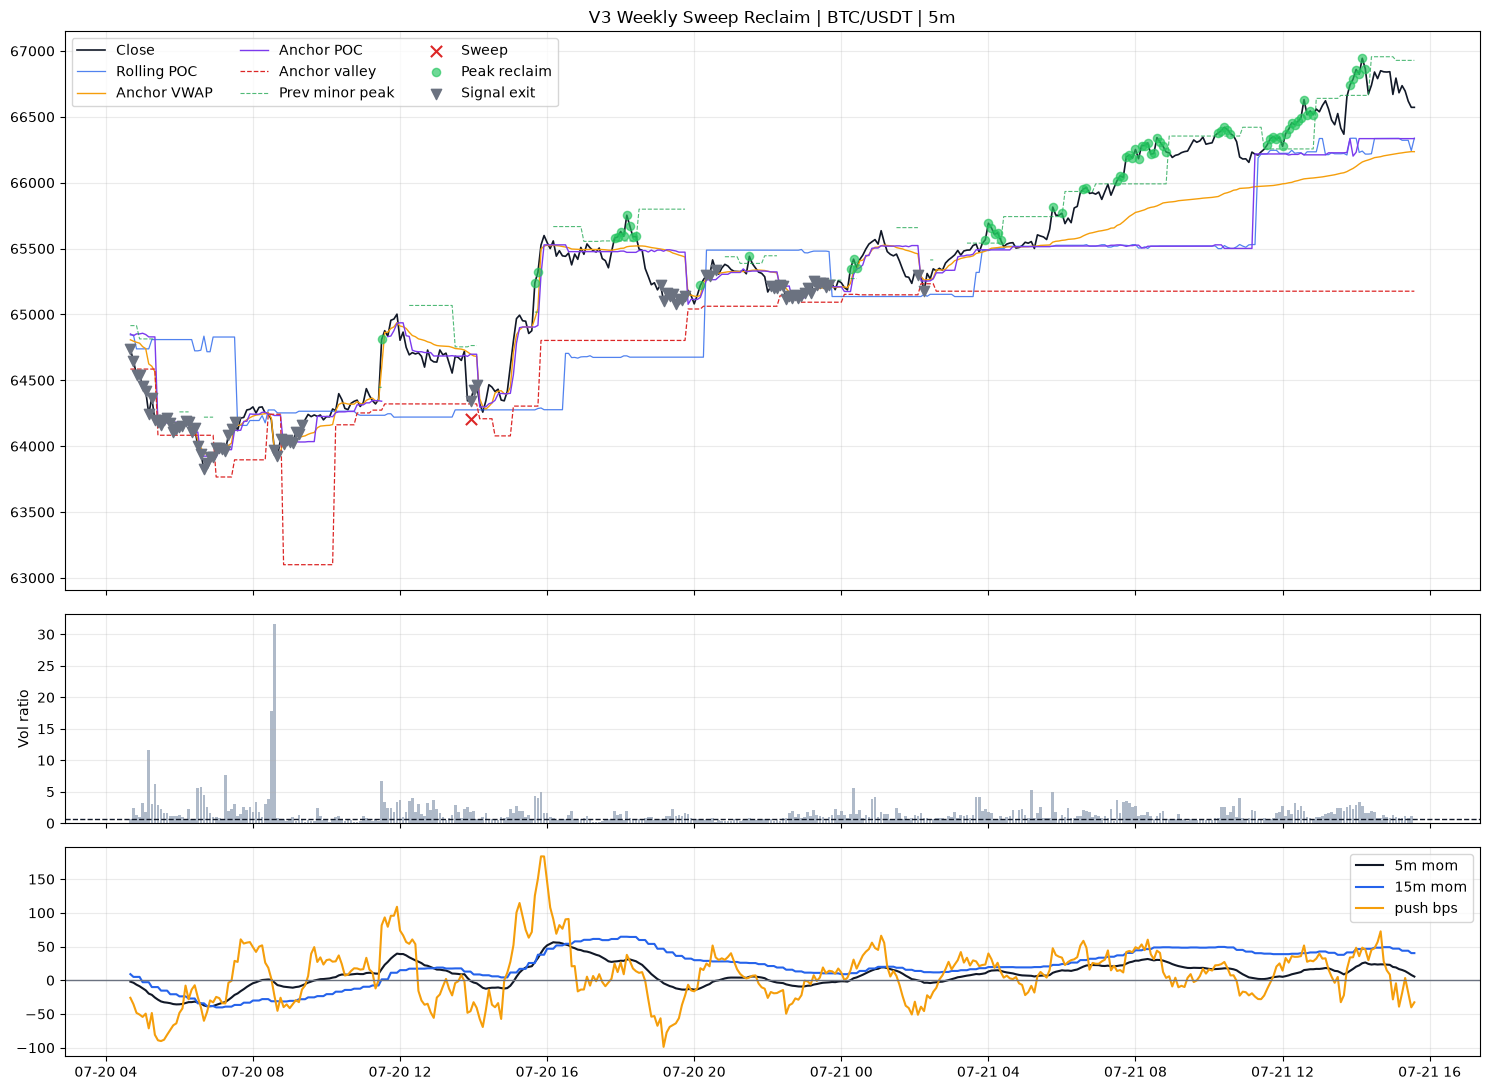

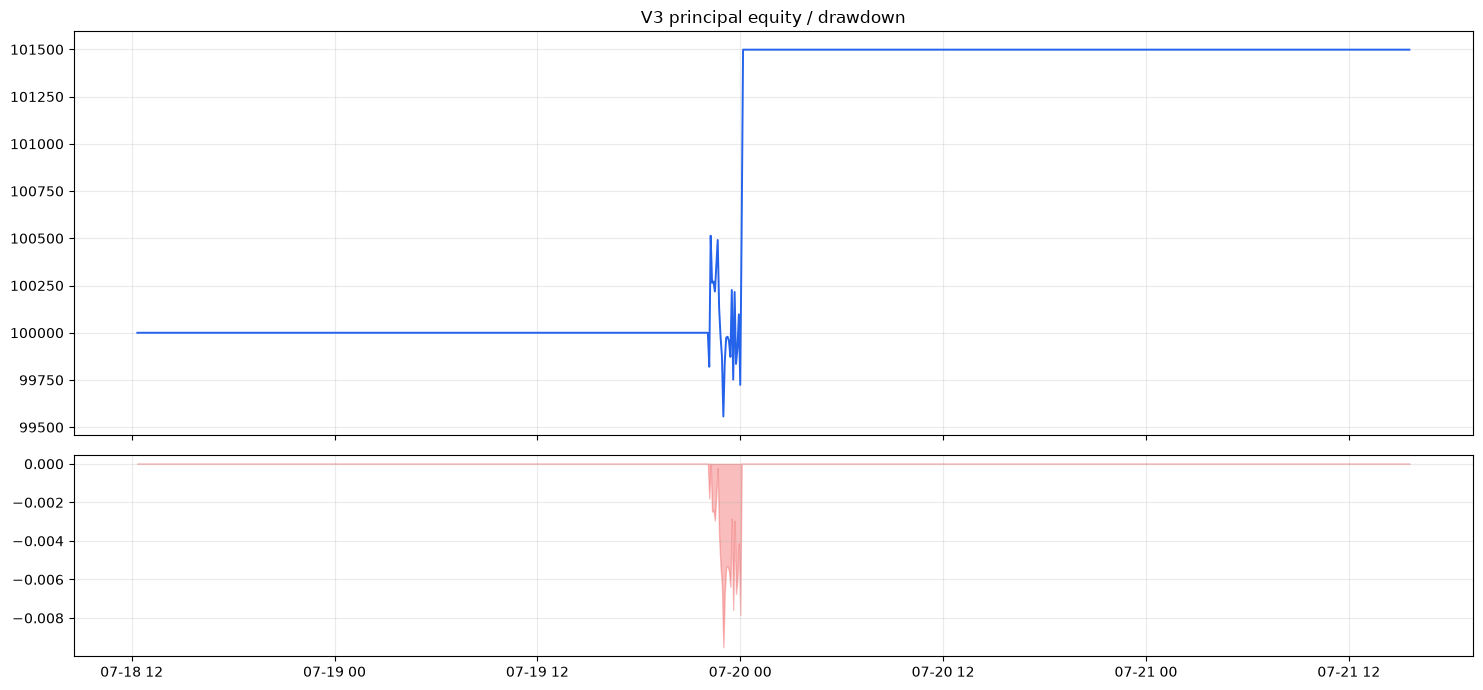

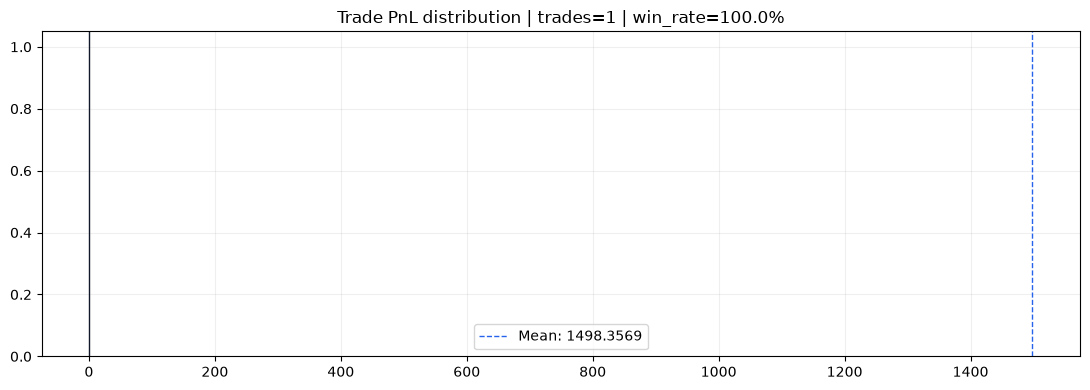

V3 grid plot icin sonuc yok.


In [22]:
def plot_v3_sweep_reclaim(f, pf=None, params=None, lookback=420):
    params = params or best_v3_params if "best_v3_params" in globals() else V3_BASE_PARAMS
    plot_f = f.tail(lookback).copy()
    entries, exits, _, _ = build_v3_sweep_reclaim_signals(plot_f, params)

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(15, 11), sharex=True,
        gridspec_kw={"height_ratios": [3.2, 1.2, 1.2]},
    )

    ax1.plot(plot_f.index, plot_f["close"], color="#111827", linewidth=1.2, label="Close")
    ax1.plot(plot_f.index, plot_f["poc"], color="#2563eb", linewidth=0.9, alpha=0.8, label="Rolling POC")
    ax1.plot(plot_f.index, plot_f["anchor_vwap"], color="#f59e0b", linewidth=1.0, label="Anchor VWAP")
    ax1.plot(plot_f.index, plot_f["anchor_poc"], color="#7c3aed", linewidth=1.0, label="Anchor POC")
    ax1.plot(plot_f.index, plot_f["anchor_valley"], color="#dc2626", linewidth=0.9, linestyle="--", label="Anchor valley")
    ax1.plot(plot_f.index, plot_f["prev_minor_peak"], color="#16a34a", linewidth=0.8, linestyle="--", alpha=0.75, label="Prev minor peak")

    sweep_idx = plot_f.index[plot_f["sweep_event"].fillna(False)]
    reclaim_idx = plot_f.index[plot_f["peak_reclaim"].fillna(False)]
    entry_idx = plot_f.index[entries.reindex(plot_f.index).fillna(False)]
    exit_idx = plot_f.index[exits.reindex(plot_f.index).fillna(False)]

    if len(sweep_idx):
        ax1.scatter(sweep_idx, plot_f.loc[sweep_idx, "low"], marker="x", s=65, color="#dc2626", label="Sweep", zorder=5)
    if len(reclaim_idx):
        ax1.scatter(reclaim_idx, plot_f.loc[reclaim_idx, "close"], marker="o", s=35, color="#22c55e", alpha=0.65, label="Peak reclaim", zorder=4)
    if len(entry_idx):
        ax1.scatter(entry_idx, plot_f.loc[entry_idx, "close"], marker="^", s=95, color="#16a34a", label="Long entry", zorder=6)
    if len(exit_idx):
        ax1.scatter(exit_idx, plot_f.loc[exit_idx, "close"], marker="v", s=55, color="#6b7280", label="Signal exit", zorder=5)

    ax1.set_title(f"V3 Weekly Sweep Reclaim | {CCXT_SYMBOL} | {CCXT_TIMEFRAME}")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best", ncols=3)

    weekly_colors = np.where(plot_f["weekly_up"].fillna(False), "#16a34a", "#94a3b8")
    ax2.bar(plot_f.index, plot_f["volume_ratio"], color=weekly_colors, width=0.003, alpha=0.75)
    ax2.axhline(params.get("entry_vol_ratio_thr", 0.85), color="#111827", linestyle="--", linewidth=1)
    ax2.set_ylabel("Vol ratio")
    ax2.grid(True, alpha=0.25)

    ax3.plot(plot_f.index, plot_f["mom_5m_bps"], color="#111827", label="5m mom")
    ax3.plot(plot_f.index, plot_f["mom_15m_bps"], color="#2563eb", label="15m mom")
    ax3.plot(plot_f.index, plot_f["trend_push_bps"], color="#f59e0b", label="push bps")
    ax3.axhline(0, color="#6b7280", linewidth=1)
    ax3.grid(True, alpha=0.25)
    ax3.legend(loc="best")
    plt.tight_layout()
    plt.show()

    if pf is not None:
        principal_equity = v3_principal_equity_from_pf(pf, params.get("leverage", LEVERAGE))
        dd = principal_equity / principal_equity.cummax() - 1
        fig, (eq_ax, dd_ax) = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
        eq_ax.plot(principal_equity.index, principal_equity.values, color="#2563eb", linewidth=1.4)
        eq_ax.set_title("V3 principal equity / drawdown")
        eq_ax.grid(True, alpha=0.25)
        dd_ax.fill_between(dd.index, dd.values, 0, color="#ef4444", alpha=0.35)
        dd_ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()
        plot_trade_distribution(pf)


def plot_v3_grid_results(grid):
    if grid is None or grid.empty:
        print("V3 grid plot icin sonuc yok.")
        return
    g = grid.copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    size = np.clip(g["test_trades"], 1, None) * 24
    color = g["test_profit_factor"].replace(np.inf, np.nan).clip(upper=5)
    sc = ax.scatter(g["test_win_rate_pct"], g["test_expectancy"], s=size, c=color, cmap="viridis", alpha=0.75)
    ax.axhline(0, color="#111827", linewidth=1)
    ax.axvline(60, color="#dc2626", linestyle="--", linewidth=1, label="60% win rate")
    ax.set_xlabel("Test win rate (%)")
    ax.set_ylabel("Test expectancy")
    ax.set_title("V3 grid: win rate vs expectancy")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    fig.colorbar(sc, ax=ax, label="Profit factor")
    plt.tight_layout()
    plt.show()

    pivot = g.pivot_table(index="hold_bars", columns="entry_vol_ratio_thr", values="test_expectancy", aggfunc="max")
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.2f}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(int(x)) for x in pivot.index])
    ax.set_xlabel("entry_vol_ratio_thr")
    ax.set_ylabel("hold_bars")
    ax.set_title("V3 best test expectancy heatmap")
    fig.colorbar(im, ax=ax, label="Expectancy")
    plt.tight_layout()
    plt.show()


plot_v3_sweep_reclaim(v3_features_bt, pf_v3_best, best_v3_params, lookback=420)
plot_v3_grid_results(v3_grid_results)

## Strategy V3 Okuma Notu

Bu strateji `peak -> drop -> confirmed valley -> sweep -> minor peak reclaim` siralamasini long-only test eder.

Kritik noktalar:

- Haftalik filtre default olarak son kapanmis haftayi kullanir; bu, backtestte lookahead'i azaltir.
- Eger strict weekly gate hic trade uretmezse notebook ayrica no-weekly diagnostic kosar. Bu live sinyal degil; sadece sweep/reclaim yapisinin kendi basina calisip calismadigini gormek icindir.
- 70/30 split'te test tarafinda trade kalmazsa full-sample diagnostic fallback devreye girer. Bu secim overfit risklidir; sadece setup'i gorsellestirmek ve kurali debug etmek icindir.
- `anchor_valley` kapanisla kaybedilirse setup bozulur. Fitil asagi tasabilir, ama close tekrar valley ustunde kalmali.
- Entry sweep aninda degil; sweep gorulduktan sonra onceki minor peak kapanisla geri alindiginda gelir.
- POC tek basina entry sebebi degil. Rolling POC, anchored POC ve anchored VWAP maliyetlenme/denge alanini ve zayif cikisi okumak icin kullaniliyor.
- Stop 3x kaldiracta ana paranin %1 riskini asmayacak sekilde caplenir. Fee/slippage dahilken 1% / 3 - round-trip cost buffer yaklasik efektif stop tavani verir.

Bu setup az trade uretirse bu beklenen bir durum: manuel tarif cok secici. Daha saglam karar icin ayni V3'u 1000+ 5m bar, farkli coinler ve walk-forward periyotlarla tekrar calistirmak lazim.

## Codex Actual V3 Quick Run

Son hizli dogrulama calismasi:

- Veri: BTC/USDT 5m, 1000 mum, `2026-07-18 04:15 UTC` -> `2026-07-21 15:30 UTC`.
- Haftalik veri: 160 mum, `2023-07-03` -> `2026-07-20`.
- Feature sayimi: 29 major valley, 2 sweep, 102 peak reclaim.
- Strict weekly gate: `weekly_up` 0 bar oldugu icin 0 entry / 0 trade. Bu kural bu ornekte islem acmadi.
- No-weekly diagnostic: 2 entry sinyali, 1 kapali trade; win rate 100%, principal return +1.498%, max drawdown -0.952%, trade PnL +1498.36.
- Diagnostic trade: entry `2026-07-19 22:10 UTC`, exit `2026-07-20 00:10 UTC`.
- Secilen diagnostic params: `entry_vol_ratio_thr=0.75`, `entry_mom_5m_thr=-3`, `entry_mom_15m_thr=-3`, `hold_bars=24`, `sl_stop=0.0015`, `tp_stop=0.006`.
- Risk: 3x leverage; efektif stop 0.15%, ana para riski yaklasik 0.45% stop-only, fee/slippage buffer dahil yaklasik 0.81%.

Yorum: strict weekly filtreyi aynen uygulayinca trade yok; sweep/reclaim motoru ise haftalik gate kapali diagnostikte bir tane guzel ornek yakaladi. Bu istatistik degil, pattern dogrulama. Siradaki ciddi adim daha uzun veri + coin sepeti + walk-forward.